# 🎯 Binary Classification Challenge — ML Pipeline

> **Dataset:** 260,000 train samples × 2,568 features (anonymized, all numeric)  
> **Goal:** Vượt toàn bộ benchmark trên Test + Challenge sets  
> `random_state=42` everywhere — fully reproducible

---

## ⚙️ Step 0 — Imports & Configuration

In [22]:
"""
Binary Classification Challenge — Full Pipeline
================================================
Steps:
  1. Load & Profile
  2. EDA
  3. Preprocessing
  4. Feature Engineering
  5. Model Training (CV)
  6. Hyperparameter Tuning (Optuna)
  7. Ensemble & Final Evaluation

random_state=42 everywhere — reproducible results.
"""

'\nBinary Classification Challenge — Full Pipeline\n================================================\nSteps:\n  1. Load & Profile\n  2. EDA\n  3. Preprocessing\n  4. Feature Engineering\n  5. Model Training (CV)\n  6. Hyperparameter Tuning (Optuna)\n  7. Ensemble & Final Evaluation\n\nrandom_state=42 everywhere — reproducible results.\n'

## 📂 Step 1 — Load Dữ Liệu & Profile

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import gc
import time

# ML
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("/kaggle/input/datasets/hieugm/btcl-ml")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports hoàn tất")
print(f"LightGBM: {lgb.__version__} | XGBoost: {xgb.__version__}")

✅ Imports hoàn tất
LightGBM: 4.6.0 | XGBoost: 3.2.0


## 🔍 Step 2 — Exploratory Data Analysis (EDA)

In [24]:
print("\n" + "="*60)
print("STEP 1 — LOAD DỮ LIỆU")
print("="*60)

t0 = time.time()

def load_csv(fname, dtype=np.float32, squeeze=False):
    """Load CSV, optionally downcast to float32 (tiết kiệm RAM ~50%)."""
    path = DATA_DIR / fname
    df = pd.read_csv(path)
    if squeeze:
        return df.squeeze().astype(int)
    return df.astype(dtype)

X_train     = load_csv("train_X.csv")
y_train     = load_csv("train_y.csv",     squeeze=True)
X_test      = load_csv("test_X.csv")
y_test      = load_csv("test_y.csv",      squeeze=True)
X_chal = load_csv("challenge_X.csv")
y_chal = load_csv("challenge_y.csv", squeeze=True)

print(f"⏱ Đã load xong trong {time.time()-t0:.1f}s")


STEP 1 — LOAD DỮ LIỆU
⏱ Đã load xong trong 121.8s



BƯỚC 1 — LÀM SẠCH DỮ LIỆU

[1.1] Missing values:
  Train : 0  |  Test: 0  |  Challenge: 0
[1.2] Infinite values (train): 0
[1.3] Duplicate rows (train): 0
[1.4] Constant features (std=0):          174
      Near-constant features (std<0.001): 33

[Summary] Cleaning report (first 10 features):
   Missing_train  Missing_test  Missing_chal           Std  Is_Constant  Is_NearConst
0              0             0             0  5.091794e+06        False         False
1              0             0             0  1.256303e+00        False         False
2              0             0             0  3.922272e-03        False         False
3              0             0             0  2.092355e-01        False         False
4              0             0             0  1.913597e-01        False         False
5              0             0             0  1.594326e+01        False         False
6              0             0             0  6.020015e+00        False         False
7              0 

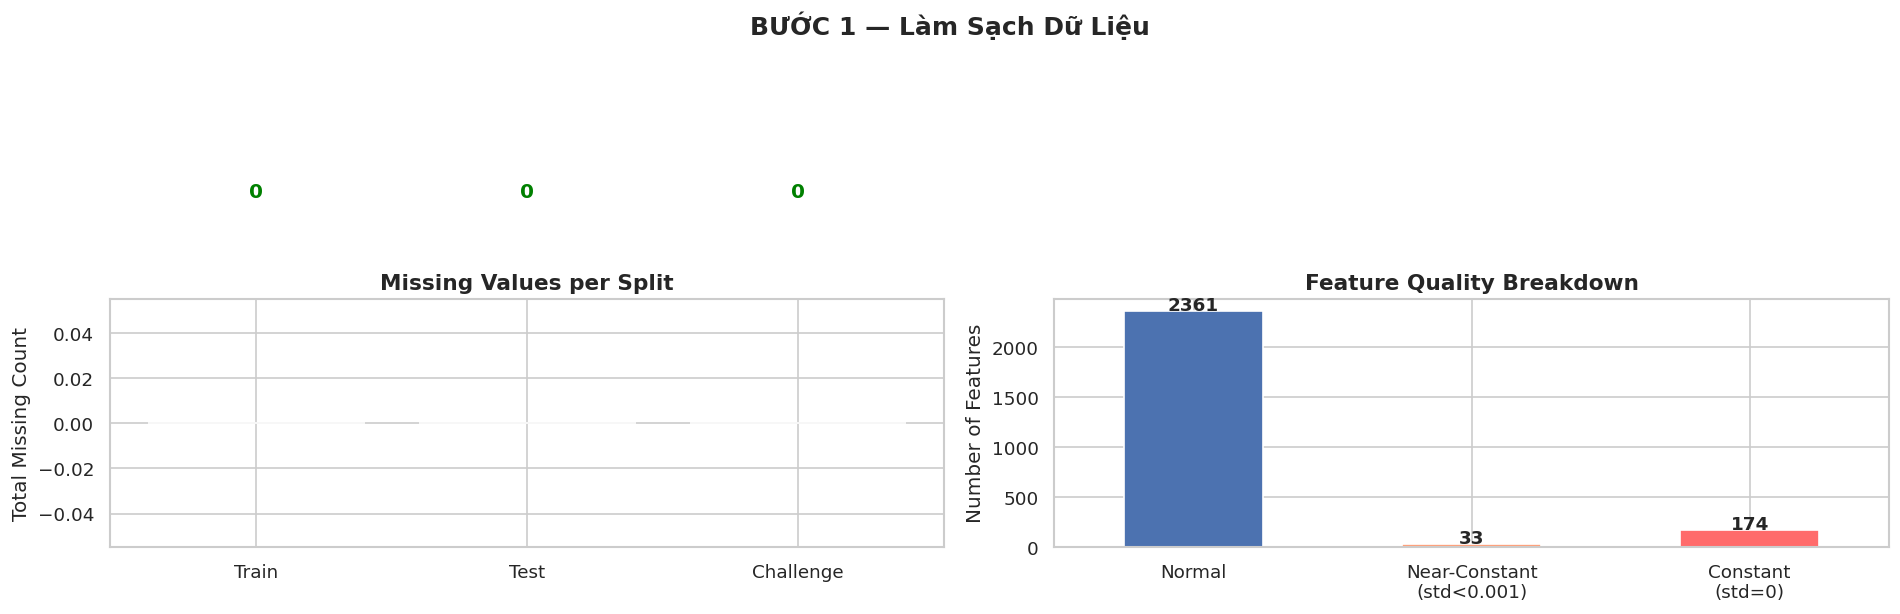


→ After cleaning: 2394 features remain (dropped 174)


In [25]:
print("\n" + "="*60)
print("BƯỚC 1 — LÀM SẠCH DỮ LIỆU")
print("="*60)
N_FEAT  = X_train.shape[1]
COLS    = X_train.columns.tolist()
# 1.1 Missing values
miss_train = X_train.isnull().sum()
miss_test  = X_test.isnull().sum()
miss_chal  = X_chal.isnull().sum()
print(f"\n[1.1] Missing values:")
print(f"  Train : {miss_train.sum()}  |  Test: {miss_test.sum()}  |  Challenge: {miss_chal.sum()}")

# 1.2 Infinite values
inf_count = np.isinf(X_train.values).sum()
print(f"[1.2] Infinite values (train): {inf_count}")
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf],  np.nan, inplace=True)
X_chal.replace([np.inf, -np.inf],  np.nan, inplace=True)

# 1.3 Duplicate rows
dup_count = X_train.duplicated().sum()
print(f"[1.3] Duplicate rows (train): {dup_count}")
if dup_count > 0:
    mask = ~X_train.duplicated()
    X_train = X_train[mask].reset_index(drop=True)
    y_train = y_train[mask].reset_index(drop=True)
    print(f"  → Removed {dup_count} duplicates. New shape: {X_train.shape}")

# 1.4 Constant / near-constant features
std_vals   = X_train.std()
const_mask = std_vals == 0
nc_mask    = (std_vals > 0) & (std_vals < 0.001)
print(f"[1.4] Constant features (std=0):          {const_mask.sum()}")
print(f"      Near-constant features (std<0.001): {nc_mask.sum()}")

clean_report = pd.DataFrame({
    "Missing_train": miss_train,
    "Missing_test":  miss_test,
    "Missing_chal":  miss_chal,
    "Std": std_vals,
    "Is_Constant": const_mask,
    "Is_NearConst": nc_mask,
})
print("\n[Summary] Cleaning report (first 10 features):")
print(clean_report.head(10).to_string())

# 1.5 Visualize: Missing value heatmap (if any) + Constant feature bar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(["Train", "Test", "Challenge"],
            [miss_train.sum(), miss_test.sum(), miss_chal.sum()],
            color=["#4C72B0","#DD8452","#55A868"], edgecolor="white")
axes[0].set_title("Missing Values per Split", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Total Missing Count")
for i, v in enumerate([miss_train.sum(), miss_test.sum(), miss_chal.sum()]):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=12, fontweight="bold", color="green")

feature_types_bar = pd.Series({
    "Normal": N_FEAT - const_mask.sum() - nc_mask.sum(),
    "Near-Constant\n(std<0.001)": nc_mask.sum(),
    "Constant\n(std=0)": const_mask.sum(),
})
feature_types_bar.plot(kind="bar", ax=axes[1], color=["#4C72B0","#FFA07A","#FF6B6B"],
                       edgecolor="white", rot=0)
axes[1].set_title("Feature Quality Breakdown", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Features")
for i, v in enumerate(feature_types_bar):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=11, fontweight="bold")
plt.suptitle("BƯỚC 1 — Làm Sạch Dữ Liệu", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_step1_cleaning.png", bbox_inches="tight")
plt.show()

# Drop constant features
cols_to_keep = std_vals[std_vals > 1e-5].index.tolist()
X_train = X_train[cols_to_keep]
X_test  = X_test[cols_to_keep]
X_chal  = X_chal[cols_to_keep]
print(f"\n→ After cleaning: {len(cols_to_keep)} features remain (dropped {N_FEAT - len(cols_to_keep)})")
N_FEAT = len(cols_to_keep)


BƯỚC 2 — CHUẨN HÓA DỮ LIỆU


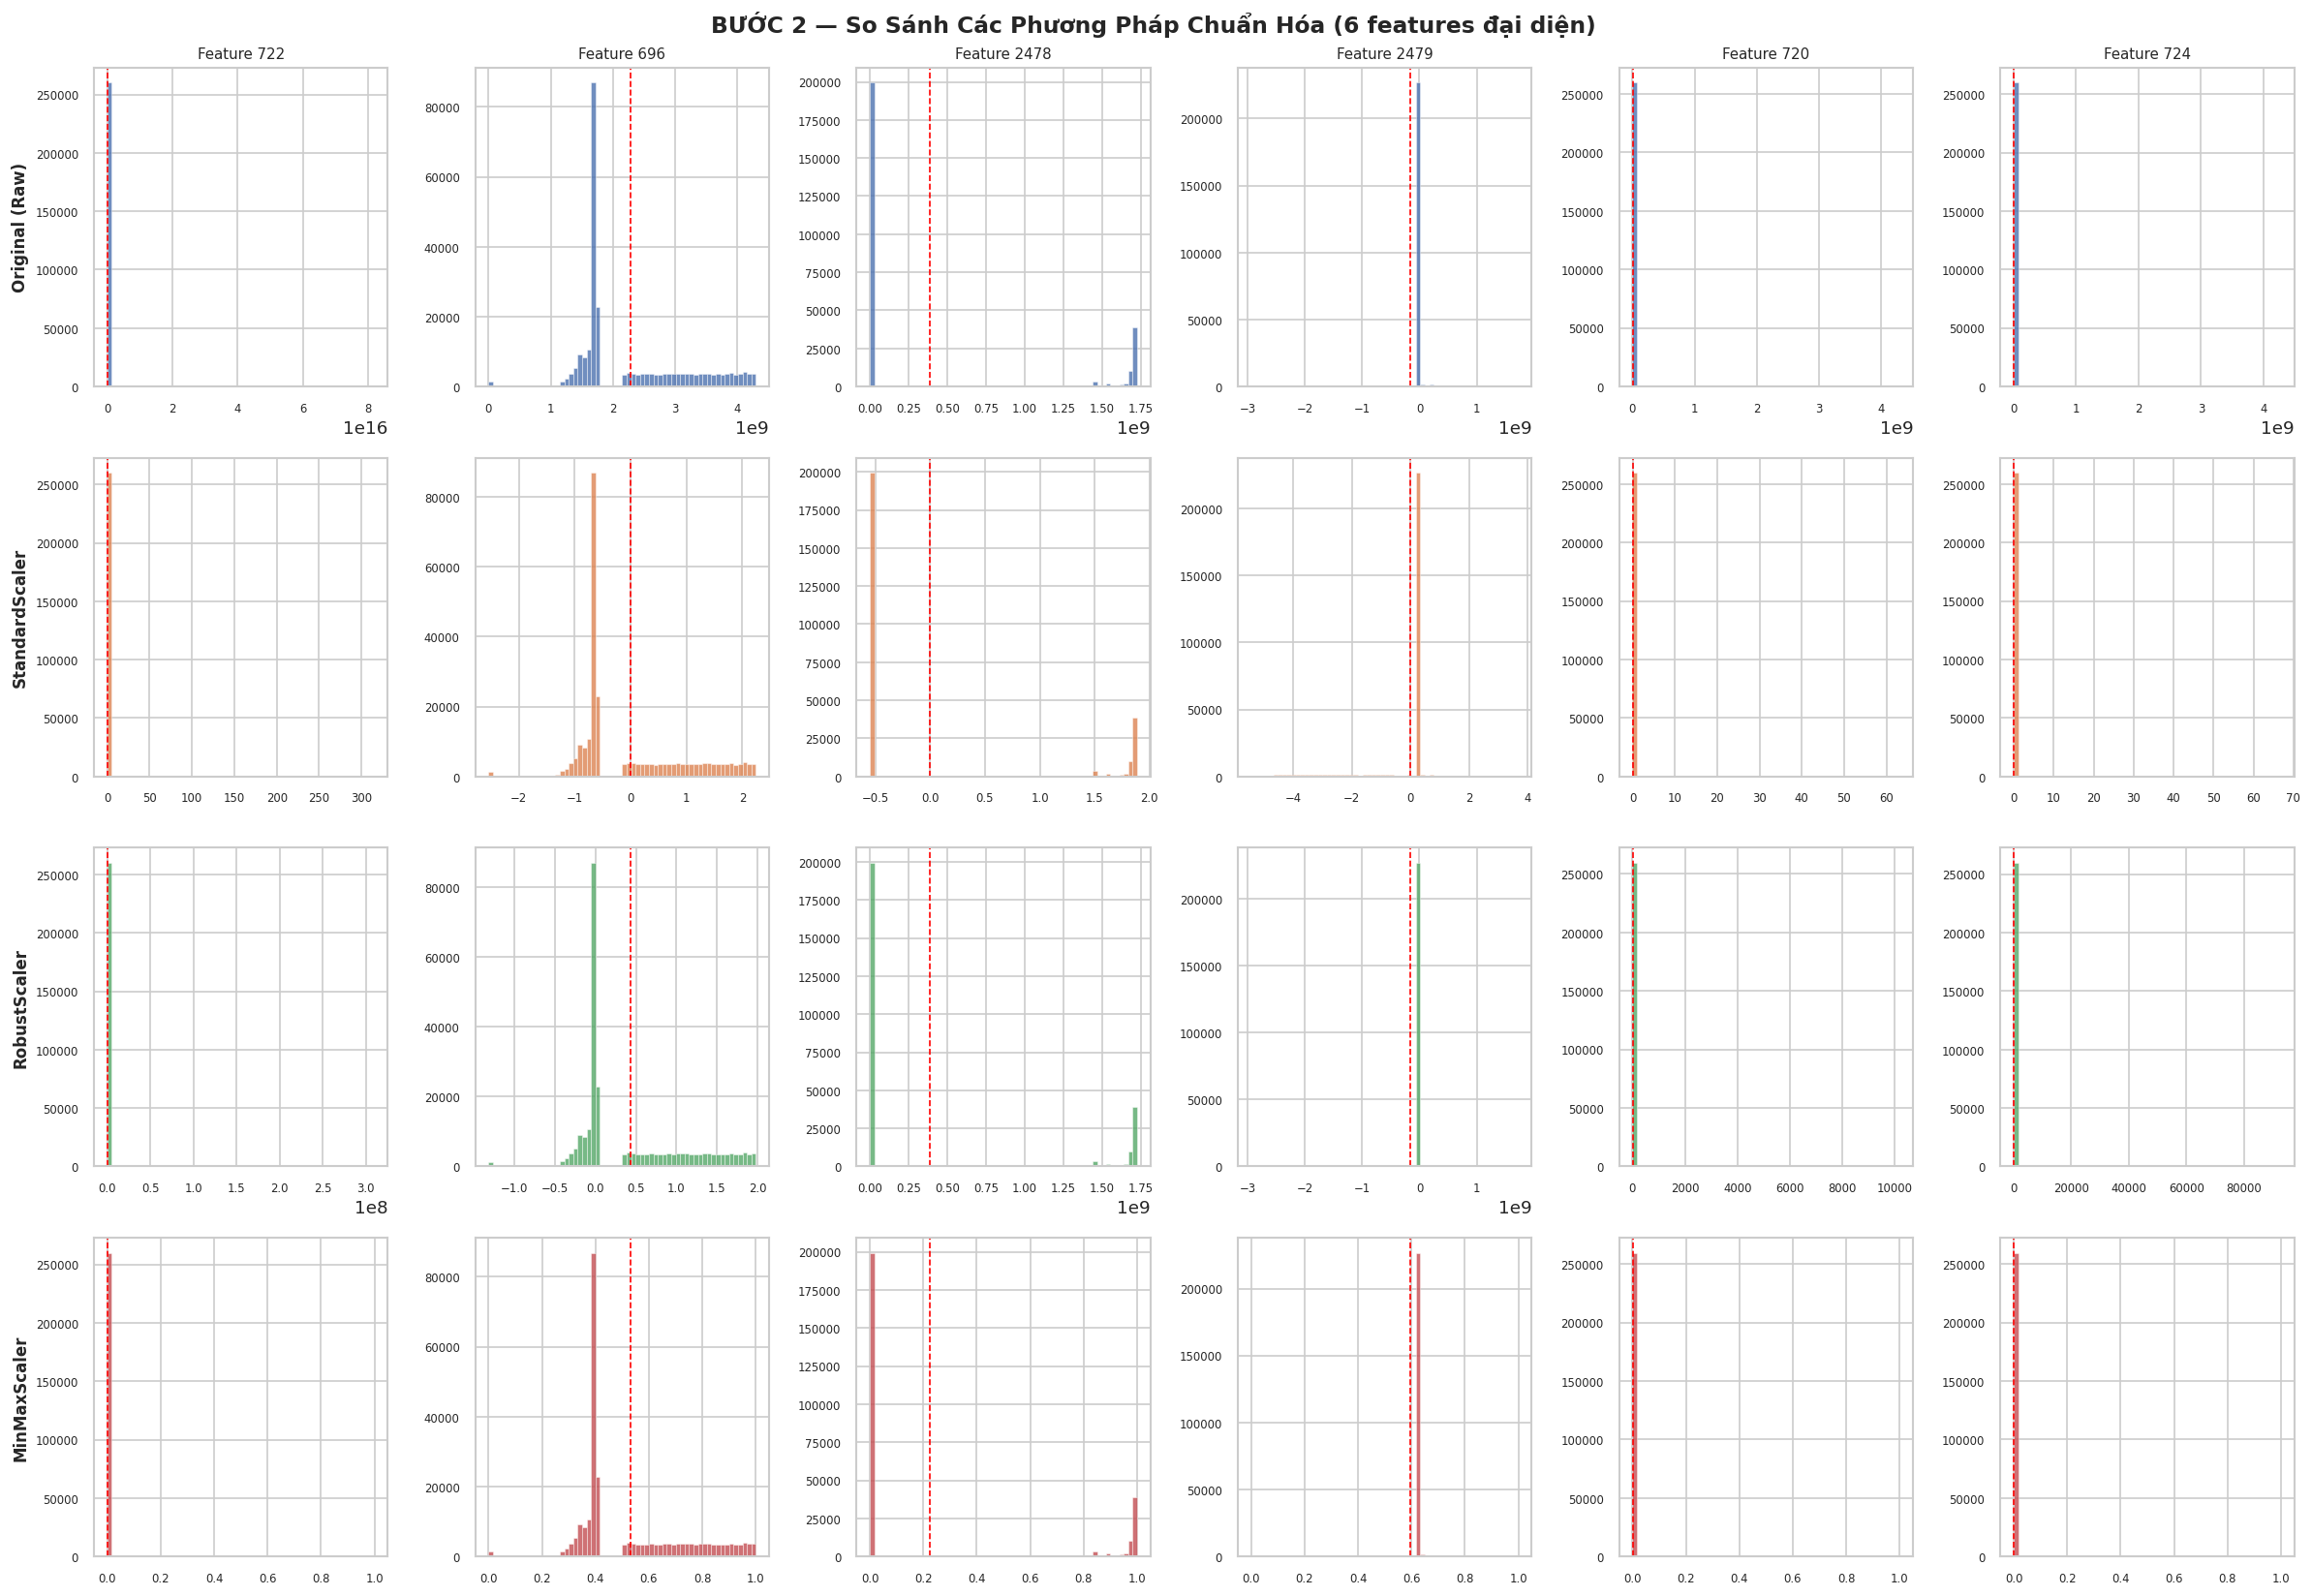


[Before RobustScaler] (6 representative features):
               722           696          2478          2479           720           724
mean  1.046198e+12  2.283034e+09  3.898829e+08 -1.575913e+08  2.896191e+06  1.815413e+06
std   2.597479e+14  8.973899e+08  7.087396e+08  5.120858e+08  6.790300e+07  6.396772e+07
min   0.000000e+00  0.000000e+00  0.000000e+00 -2.936005e+09  0.000000e+00  0.000000e+00
max   8.190922e+16  4.294966e+09  1.726927e+09  1.726147e+09  4.294808e+09  4.281960e+09

[After RobustScaler]:
               722    696          2478          2479        720        724
mean  3.959240e+03  0.434  3.898829e+08 -1.575913e+08      6.717     39.348
std   9.829958e+05  0.690  7.087396e+08  5.120858e+08    161.101   1386.464
min  -1.600000e-02 -1.320  0.000000e+00 -2.936005e+09     -0.154      0.000
max   3.099790e+08  1.980  1.726927e+09  1.726147e+09  10189.067  92808.680


In [26]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
print("\n" + "="*60)
print("BƯỚC 2 — CHUẨN HÓA DỮ LIỆU")
print("="*60)

# Chọn 6 features đại diện để minh họa
sample_feats = X_train.std().nlargest(6).index.tolist()

scalers = {
    "Original (Raw)":  None,
    "StandardScaler":  StandardScaler(),
    "RobustScaler":    RobustScaler(),
    "MinMaxScaler":    MinMaxScaler(),
}

fig, axes = plt.subplots(len(scalers), len(sample_feats),
                          figsize=(20, 14), sharey=False)
for row_i, (scaler_name, scaler) in enumerate(scalers.items()):
    if scaler is None:
        X_show = X_train[sample_feats].values
    else:
        X_show = scaler.fit_transform(X_train[sample_feats])

    for col_i, feat in enumerate(sample_feats):
        ax = axes[row_i][col_i]
        data = X_show[:, col_i]
        ax.hist(data, bins=60, color=["#4C72B0","#DD8452","#55A868","#C44E52"][row_i],
                alpha=0.8, edgecolor="white", linewidth=0.3)
        if col_i == 0:
            ax.set_ylabel(scaler_name, fontsize=10, fontweight="bold")
        if row_i == 0:
            ax.set_title(f"Feature {feat}", fontsize=9)
        ax.axvline(np.mean(data), color="red", linestyle="--", linewidth=1, label="mean")
        ax.tick_params(labelsize=7)

plt.suptitle("BƯỚC 2 — So Sánh Các Phương Pháp Chuẩn Hóa (6 features đại diện)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_step2_normalization.png", bbox_inches="tight")
plt.show()

# Stats before vs after (RobustScaler)
rb = RobustScaler()
X_train_scaled = rb.fit_transform(X_train)
X_test_scaled  = rb.transform(X_test)
X_chal_scaled  = rb.transform(X_chal)

before = X_train[sample_feats].describe().loc[["mean","std","min","max"]]
after_df = pd.DataFrame(X_train_scaled[:, [list(X_train.columns).index(f)
                         for f in sample_feats]],
                        columns=sample_feats)
after = after_df.describe().loc[["mean","std","min","max"]]
print("\n[Before RobustScaler] (6 representative features):")
print(before.round(3).to_string())
print("\n[After RobustScaler]:")
print(after.round(3).to_string())

In [27]:
print("\n" + "="*60)
print("BƯỚC 3 — TRỰC QUAN HÓA")
print("="*60)


BƯỚC 3 — TRỰC QUAN HÓA


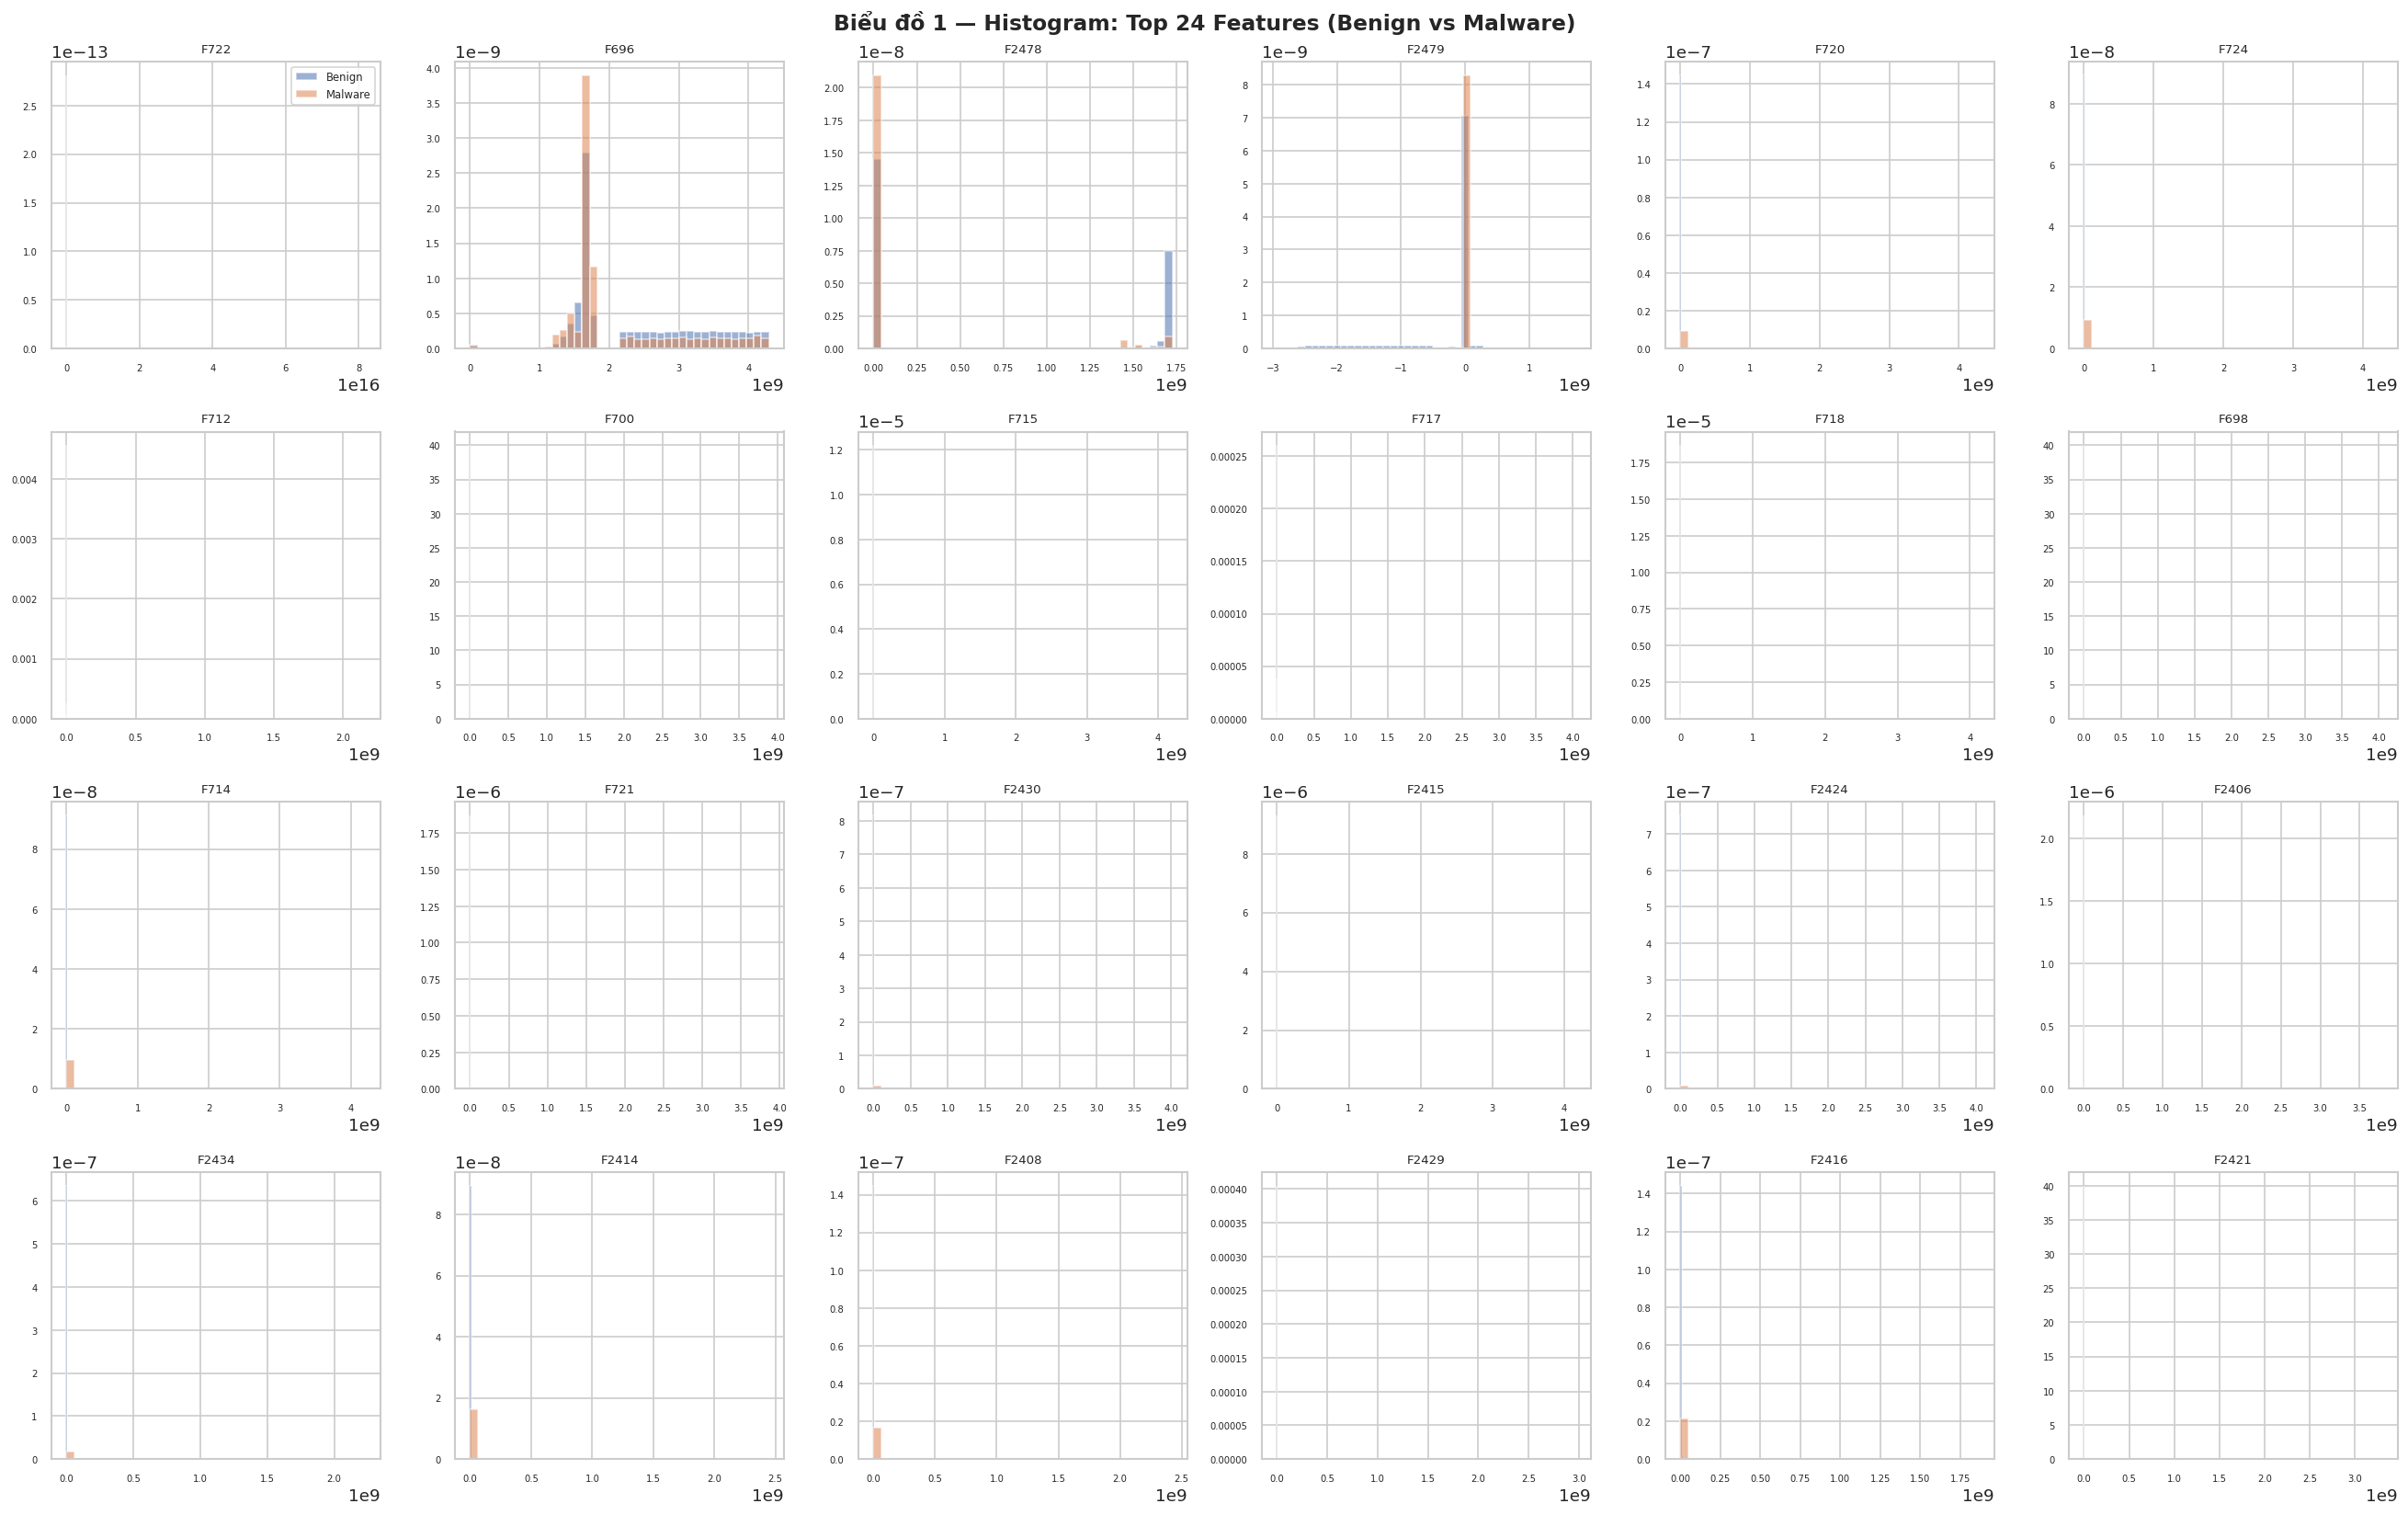

In [28]:
top24 = X_train.std().nlargest(24).index.tolist()
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes_flat = axes.flatten()
for i, feat in enumerate(top24):
    ax = axes_flat[i]
    for cls, color, lbl in [(0,"#4C72B0","Benign"),(1,"#DD8452","Malware")]:
        data = X_train.loc[y_train==cls, feat].values
        ax.hist(data, bins=40, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(f"F{feat}", fontsize=8)
    ax.tick_params(labelsize=6)
    if i == 0: ax.legend(fontsize=7)
plt.suptitle("Biểu đồ 1 — Histogram: Top 24 Features (Benign vs Malware)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_01_histograms.png", bbox_inches="tight")
plt.show()

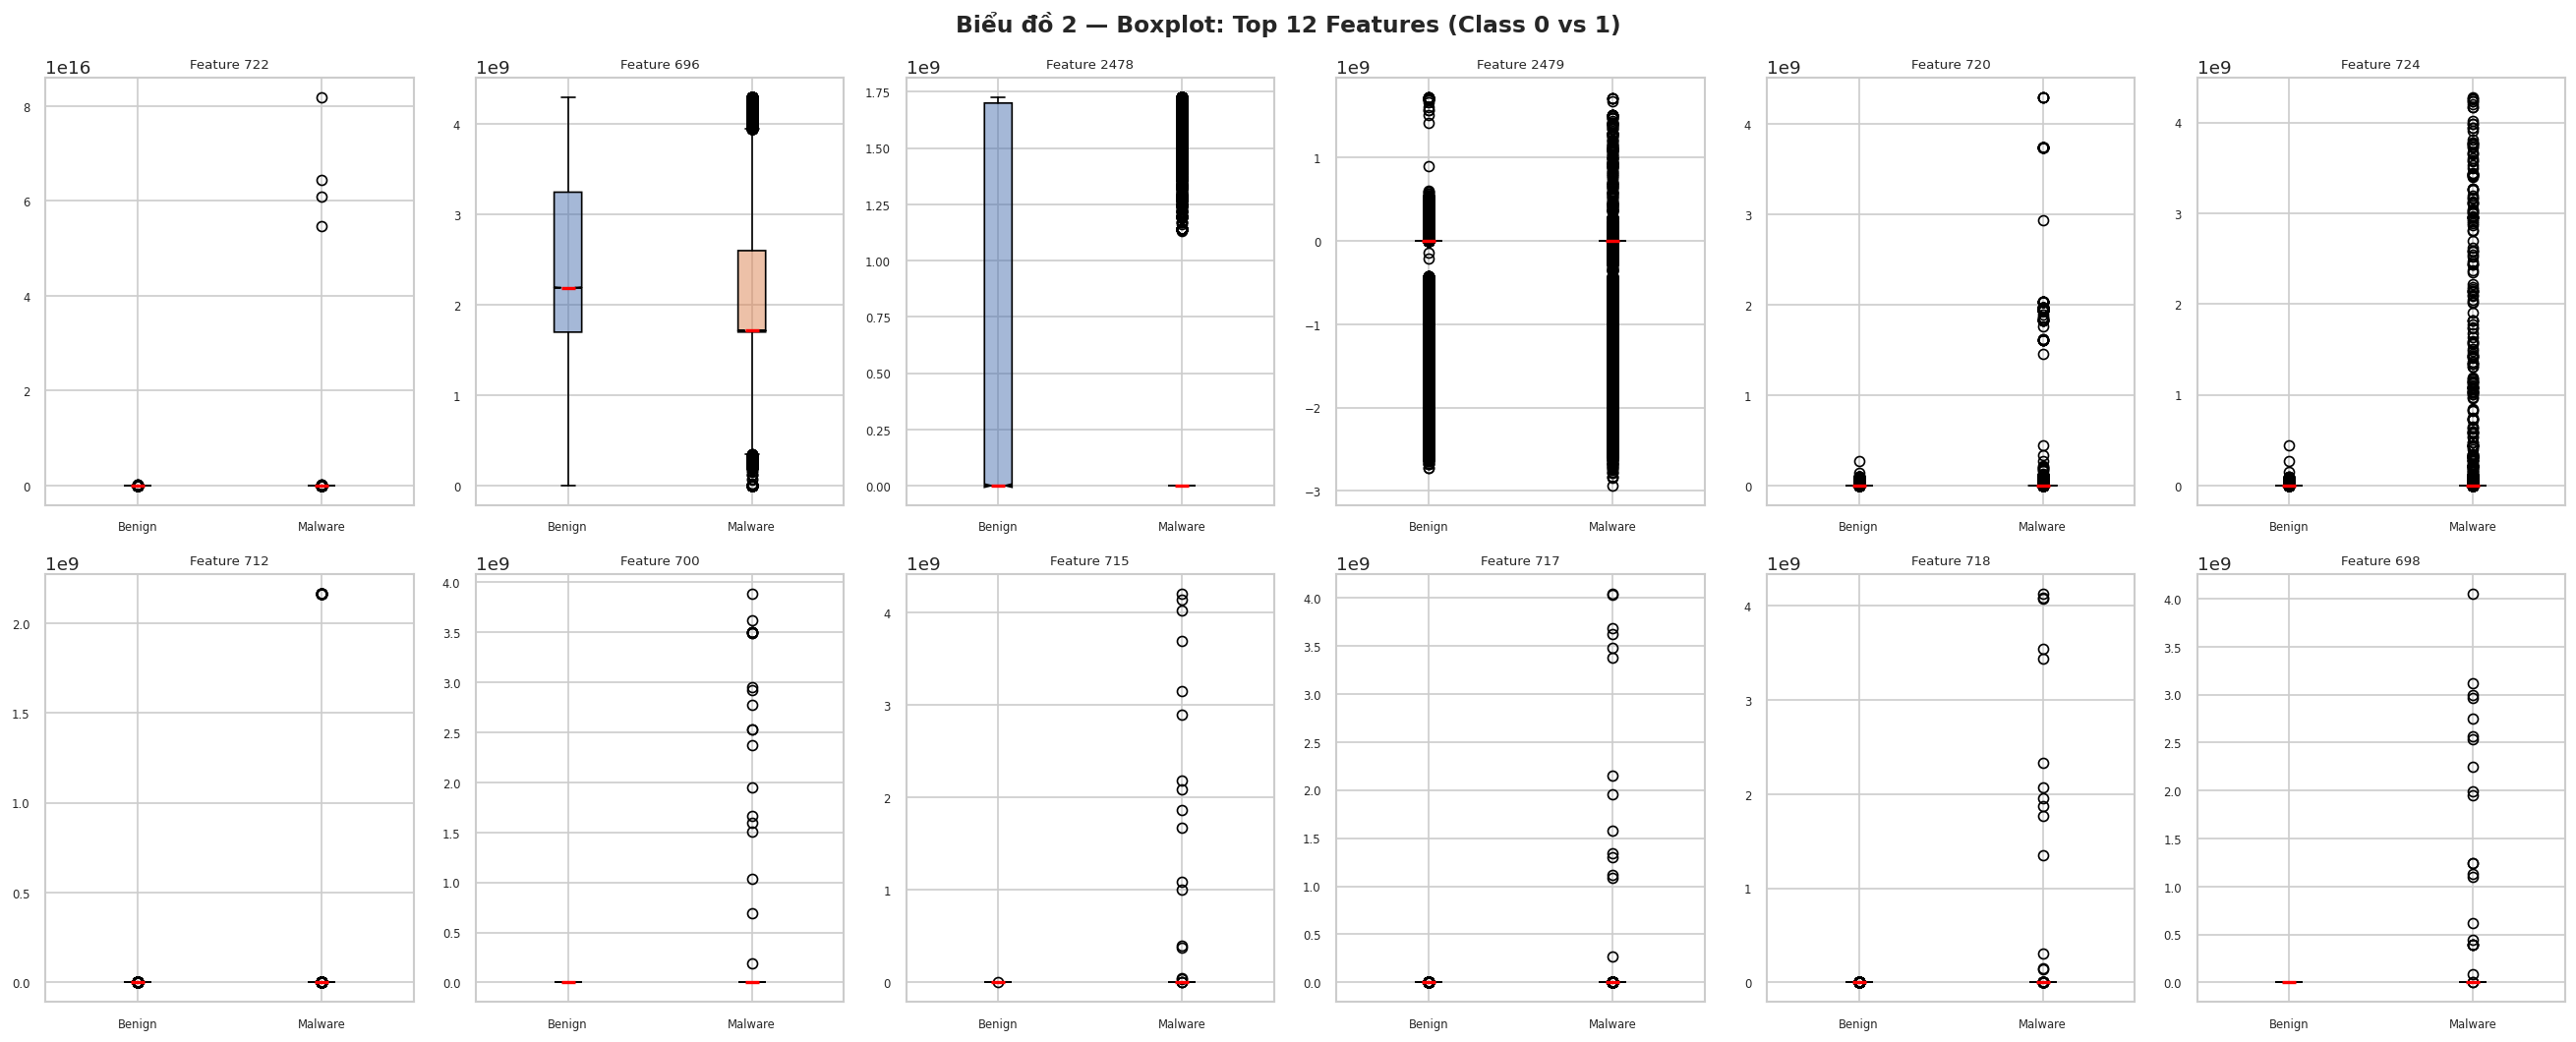

In [29]:
top12 = X_train.std().nlargest(12).index.tolist()
fig, axes = plt.subplots(2, 6, figsize=(22, 9))
axes_flat = axes.flatten()
for i, feat in enumerate(top12):
    ax = axes_flat[i]
    data_0 = X_train.loc[y_train==0, feat].values
    data_1 = X_train.loc[y_train==1, feat].values
    bp = ax.boxplot([data_0, data_1], labels=["Benign","Malware"],
                    patch_artist=True, notch=True,
                    medianprops=dict(color="red", linewidth=2))
    bp["boxes"][0].set_facecolor("#4C72B080")
    bp["boxes"][1].set_facecolor("#DD845280")
    ax.set_title(f"Feature {feat}", fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle("Biểu đồ 2 — Boxplot: Top 12 Features (Class 0 vs 1)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_02_boxplots.png", bbox_inches="tight")
plt.show()

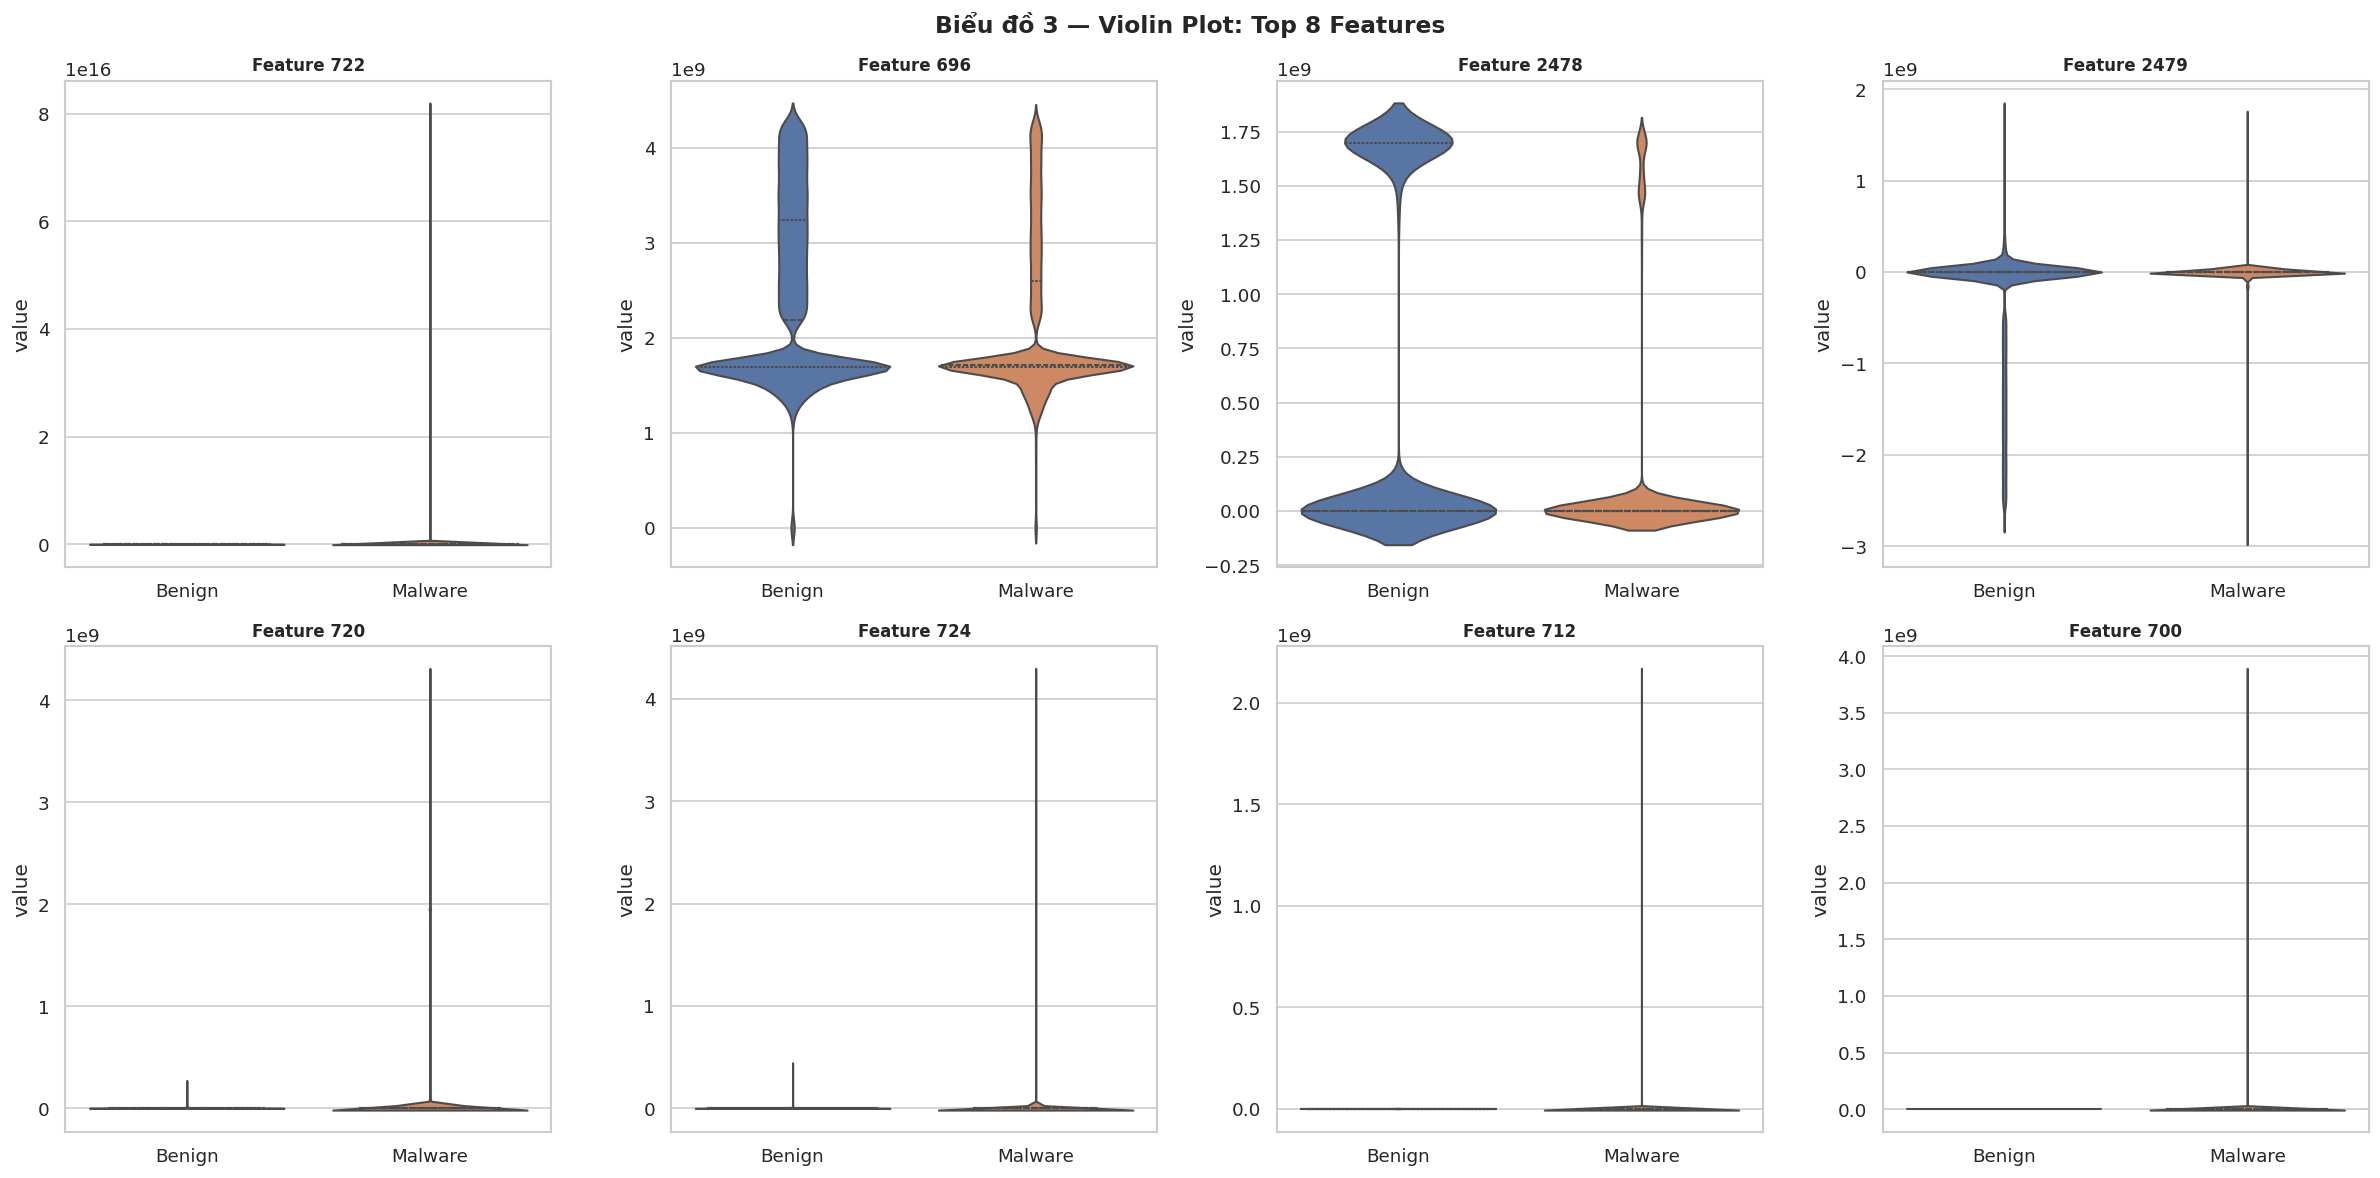

In [30]:
top8 = X_train.std().nlargest(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()
for i, feat in enumerate(top8):
    ax = axes_flat[i]
    df_viol = pd.DataFrame({"value": X_train[feat].values, "class": y_train.values})
    df_viol["class"] = df_viol["class"].map({0:"Benign",1:"Malware"})
    sns.violinplot(data=df_viol, x="class", y="value", palette=["#4C72B0","#DD8452"],
                   inner="quartile", ax=ax)
    ax.set_title(f"Feature {feat}", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Biểu đồ 3 — Violin Plot: Top 8 Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_03_violin.png", bbox_inches="tight")
plt.show()

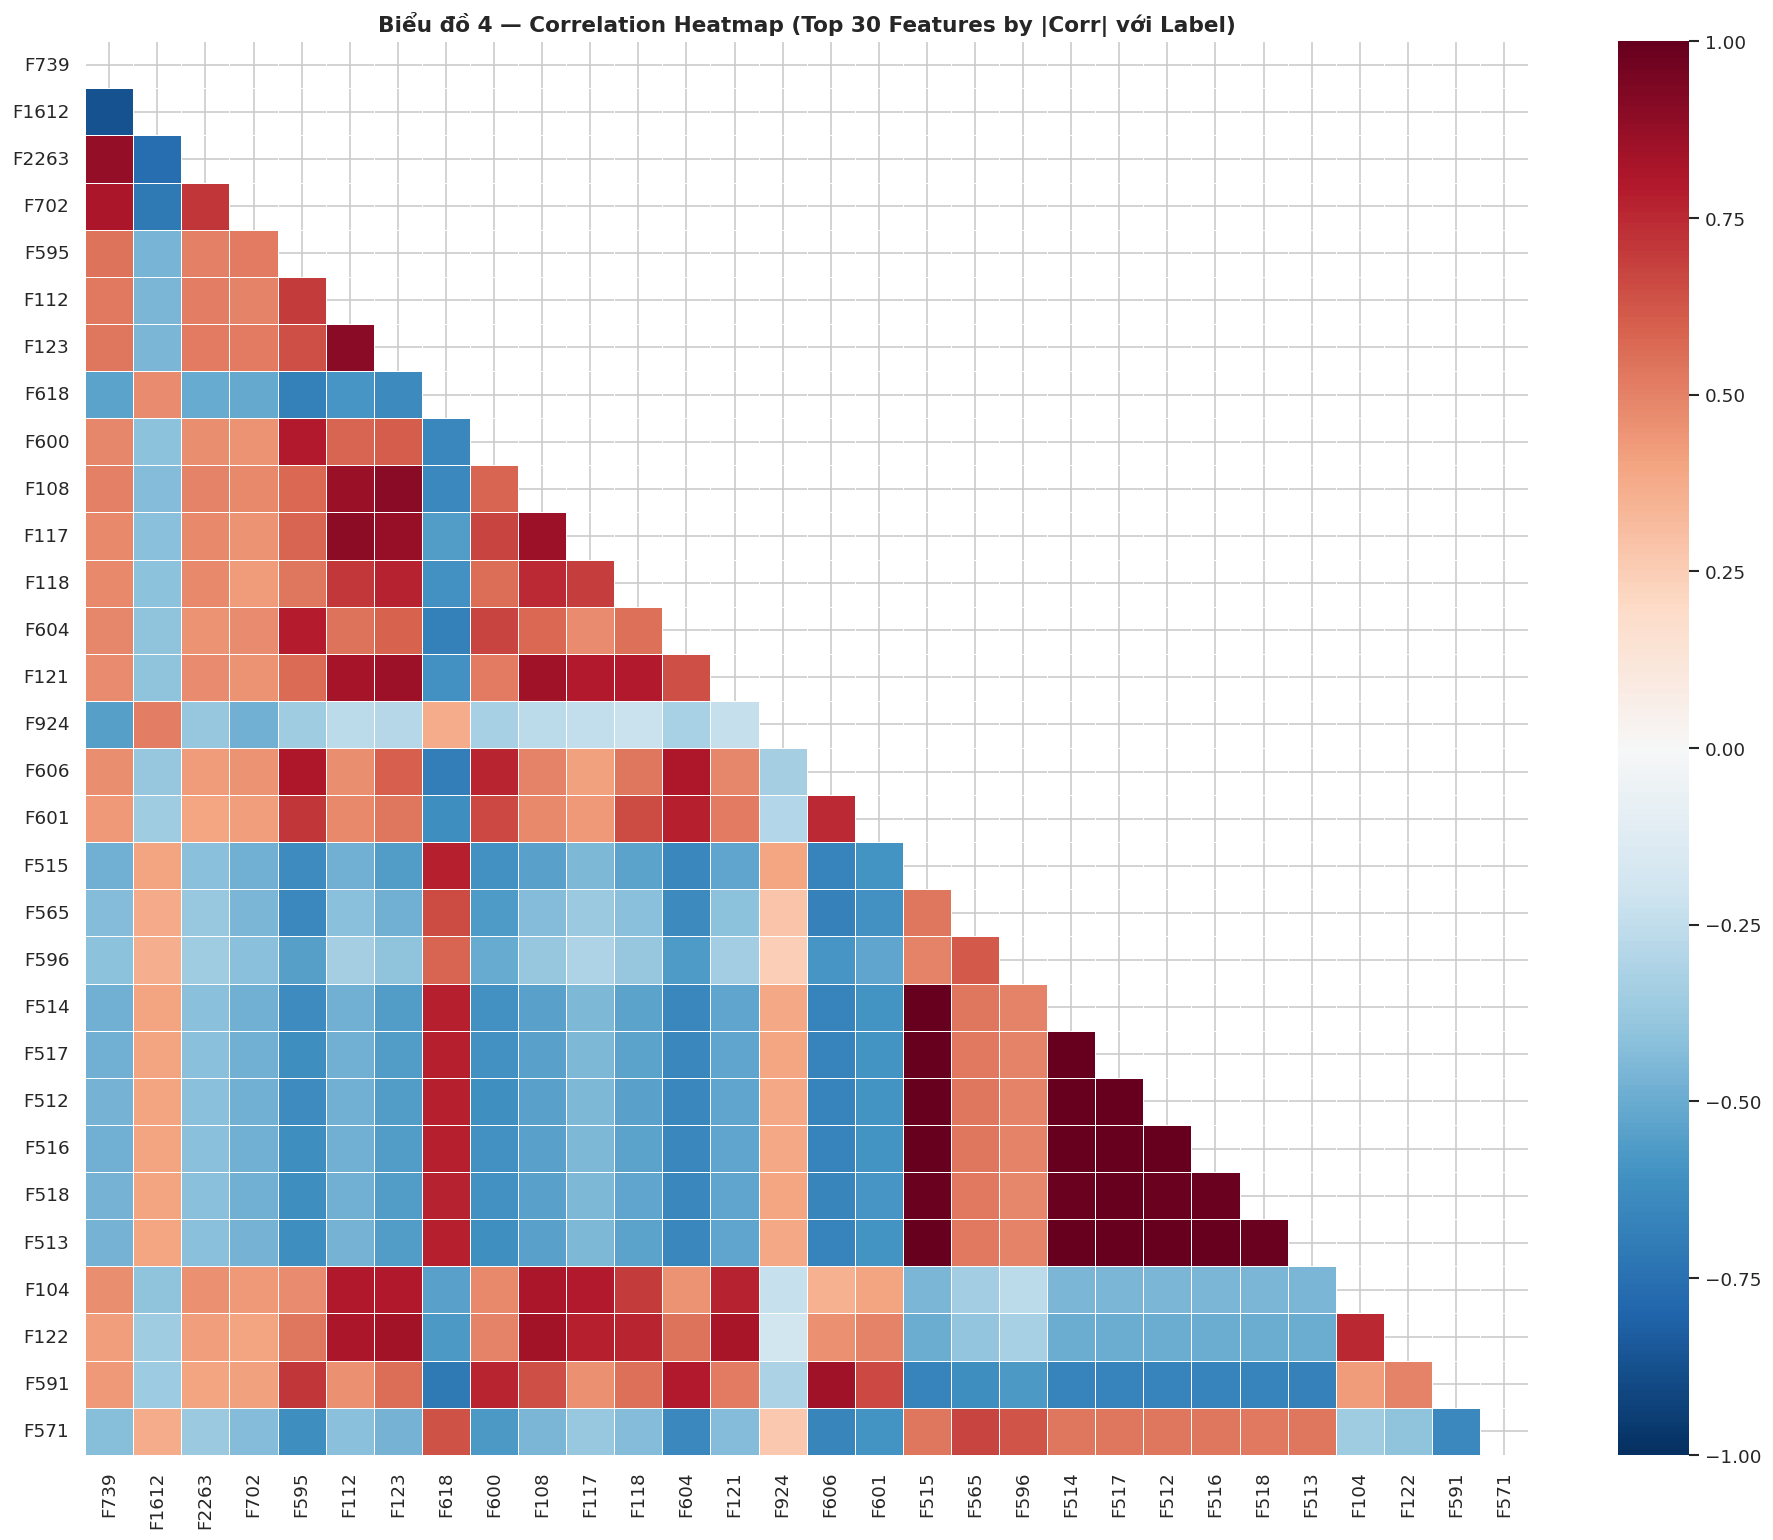

In [31]:
corr_with_label = X_train.corrwith(
    pd.Series(y_train.values, index=X_train.index), method="pearson"
).abs()
top30_names = corr_with_label.nlargest(30).index.tolist()
corr_matrix = X_train[top30_names].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            annot=False, fmt=".2f", linewidths=0.3,
            xticklabels=[f"F{c}" for c in top30_names],
            yticklabels=[f"F{c}" for c in top30_names],
            ax=ax, vmin=-1, vmax=1)
ax.set_title("Biểu đồ 4 — Correlation Heatmap (Top 30 Features by |Corr| với Label)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_04_corr_heatmap.png", bbox_inches="tight")
plt.show()

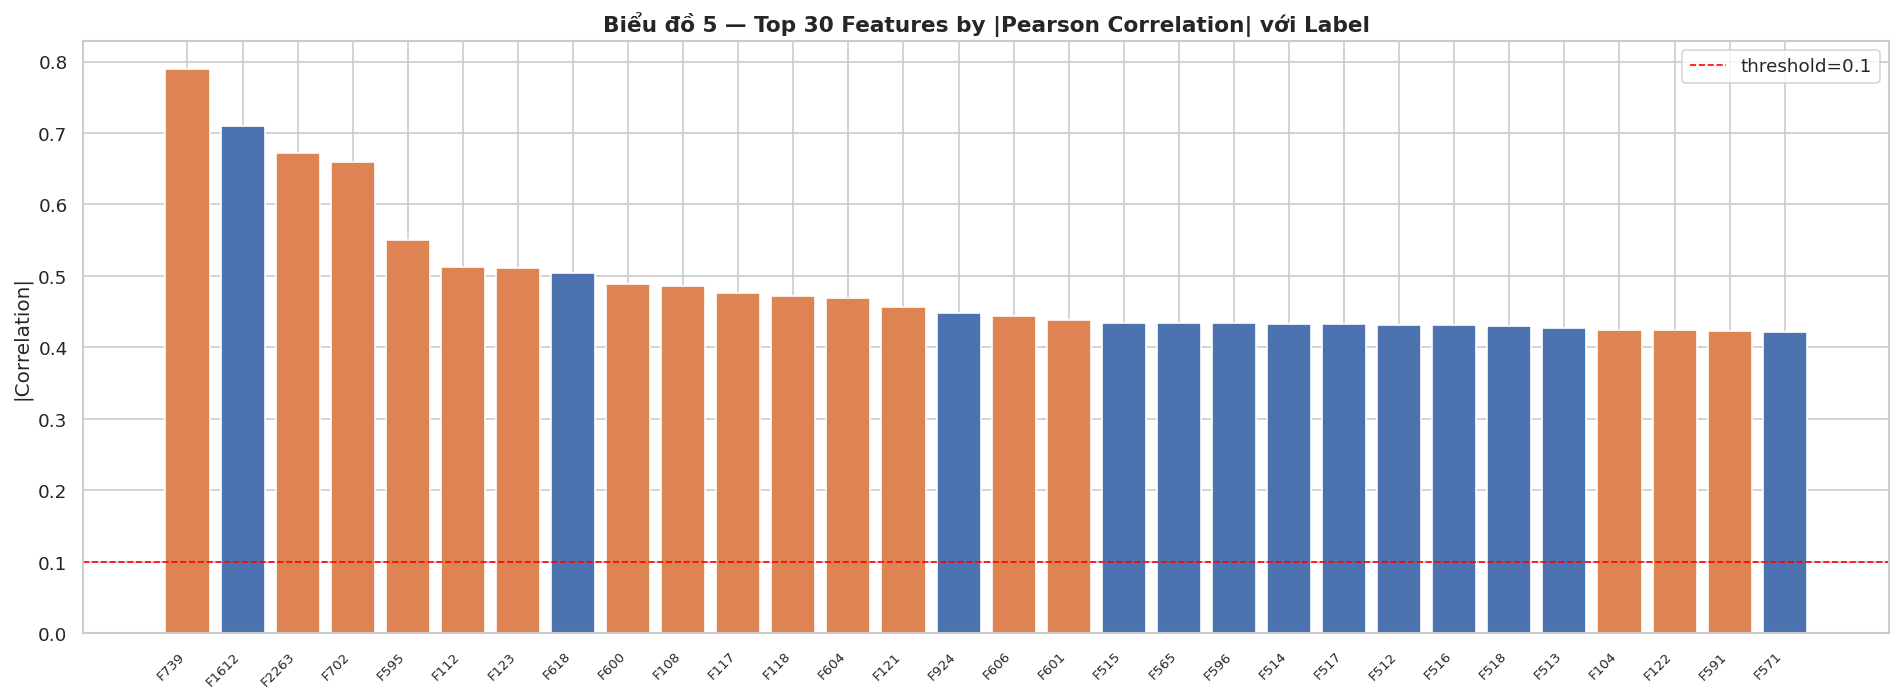

In [32]:
top30_corr = corr_with_label.nlargest(30)
fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in
          X_train[top30_names].corrwith(
              pd.Series(y_train.values, index=X_train.index)).values]
bars = ax.bar(range(30), top30_corr.values, color=colors, edgecolor="white")
ax.set_xticks(range(30))
ax.set_xticklabels([f"F{c}" for c in top30_corr.index], rotation=45, ha="right", fontsize=8)
ax.set_title("Biểu đồ 5 — Top 30 Features by |Pearson Correlation| với Label",
             fontsize=13, fontweight="bold")
ax.set_ylabel("|Correlation|")
ax.axhline(0.1, color="red", linestyle="--", linewidth=1, label="threshold=0.1")
ax.legend()
plt.tight_layout()
plt.savefig("eda_viz_05_corr_bar.png", bbox_inches="tight")
plt.show()

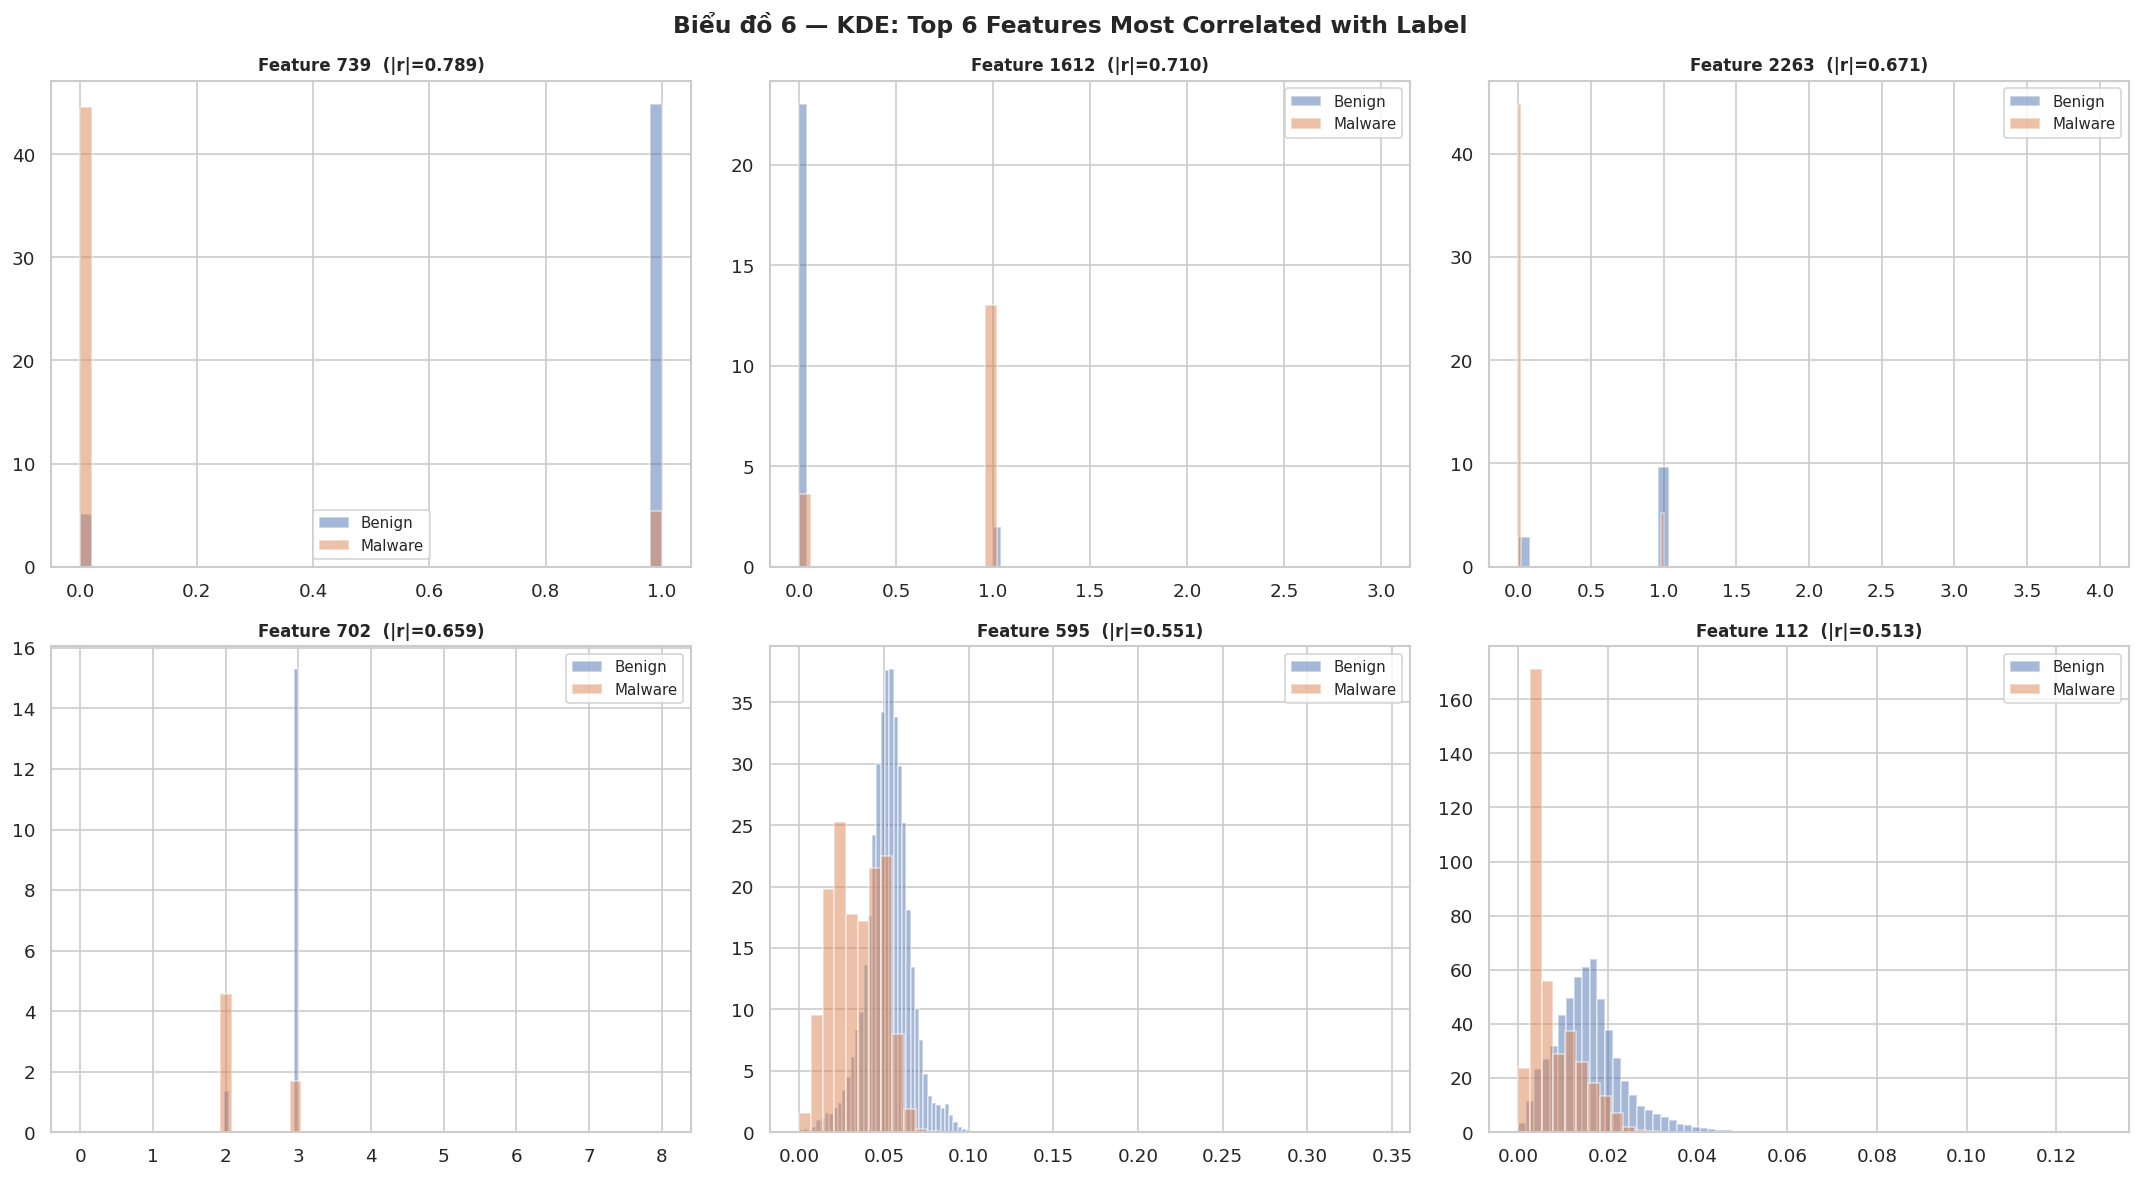

In [33]:
top6_corr = corr_with_label.nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
for i, feat in enumerate(top6_corr):
    ax = axes_flat[i]
    for cls, color, lbl in [(0,"#4C72B0","Benign"),(1,"#DD8452","Malware")]:
        data = X_train.loc[y_train==cls, feat].values
        try:
            kde = stats.gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 300)
            ax.fill_between(x_range, kde(x_range), alpha=0.4, color=color, label=lbl)
            ax.plot(x_range, kde(x_range), color=color, linewidth=2)
        except Exception:
            ax.hist(data, bins=50, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(f"Feature {feat}  (|r|={corr_with_label[feat]:.3f})",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
plt.suptitle("Biểu đồ 6 — KDE: Top 6 Features Most Correlated with Label",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_06_kde.png", bbox_inches="tight")
plt.show()

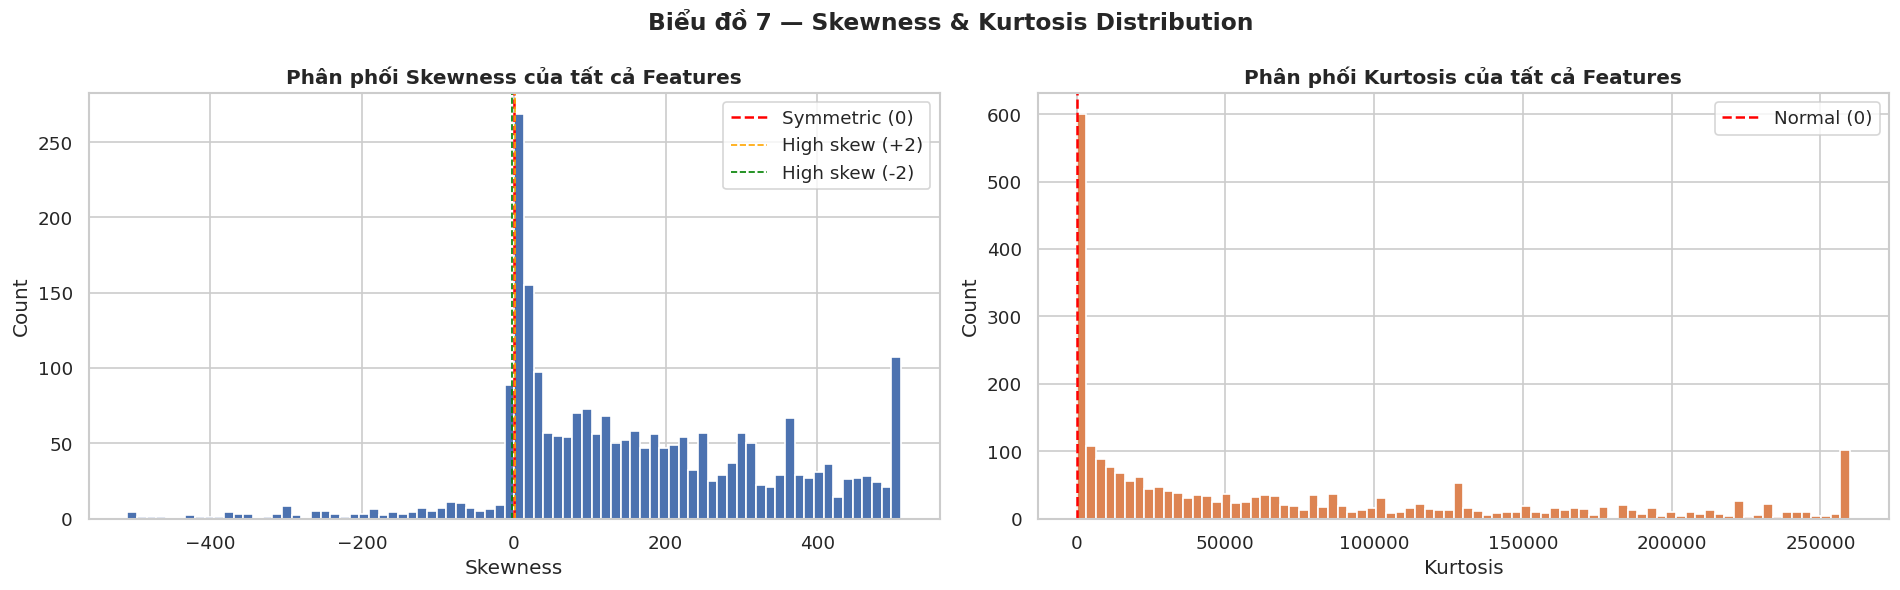

  Highly skewed |skew|>2:  2315 features
  Heavy-tailed  kurt >5:   2341 features


In [34]:
skewness = X_train.skew()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(skewness.values, bins=80, color="#4C72B0", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Symmetric (0)")
axes[0].axvline(2, color="orange", linestyle="--", linewidth=1, label="High skew (+2)")
axes[0].axvline(-2, color="green", linestyle="--", linewidth=1, label="High skew (-2)")
axes[0].set_title("Phân phối Skewness của tất cả Features", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Skewness"); axes[0].set_ylabel("Count"); axes[0].legend()

kurt = X_train.kurt()
axes[1].hist(kurt.values, bins=80, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Normal (0)")
axes[1].set_title("Phân phối Kurtosis của tất cả Features", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Kurtosis"); axes[1].set_ylabel("Count"); axes[1].legend()
plt.suptitle("Biểu đồ 7 — Skewness & Kurtosis Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_07_skewness.png", bbox_inches="tight")
plt.show()

print(f"  Highly skewed |skew|>2:  {(skewness.abs()>2).sum()} features")
print(f"  Heavy-tailed  kurt >5:   {(kurt>5).sum()} features")


[3.8] PCA 2D visualization (5K sample)...


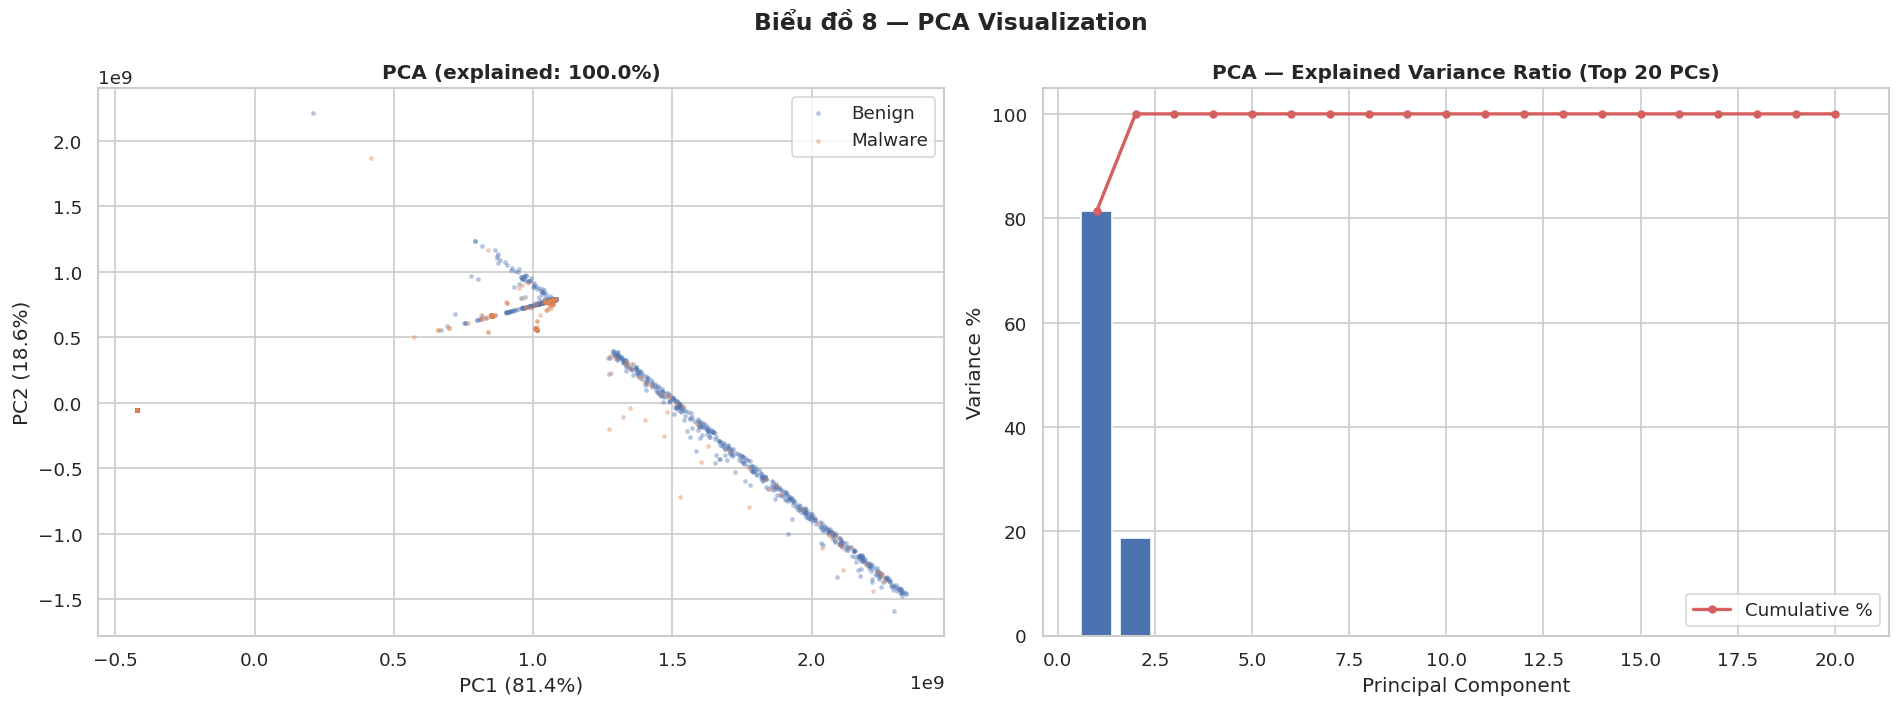

In [35]:
print("\n[3.8] PCA 2D visualization (5K sample)...")
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_train_scaled[sample_idx]
y_sample = y_train.values[sample_idx]

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cls, color, lbl in [(0,"#4C72B0","Benign"),(1,"#DD8452","Malware")]:
    mask = y_sample == cls
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=color, alpha=0.4,
                    s=8, label=lbl, linewidths=0)
axes[0].set_title(f"PCA (explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()

# PCA Explained Variance Ratio (top 20 components)
pca50 = PCA(n_components=50, random_state=SEED).fit(X_sample)
axes[1].bar(range(1, 21), pca50.explained_variance_ratio_[:20]*100,
            color="#4C72B0", edgecolor="white")
axes[1].plot(range(1, 21), np.cumsum(pca50.explained_variance_ratio_[:20])*100,
             "r-o", markersize=4, linewidth=2, label="Cumulative %")
axes[1].set_title("PCA — Explained Variance Ratio (Top 20 PCs)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Principal Component"); axes[1].set_ylabel("Variance %")
axes[1].legend()
plt.suptitle("Biểu đồ 8 — PCA Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_viz_08_pca.png", bbox_inches="tight")
plt.show()


[3.9] t-SNE 2D (2K sample)...


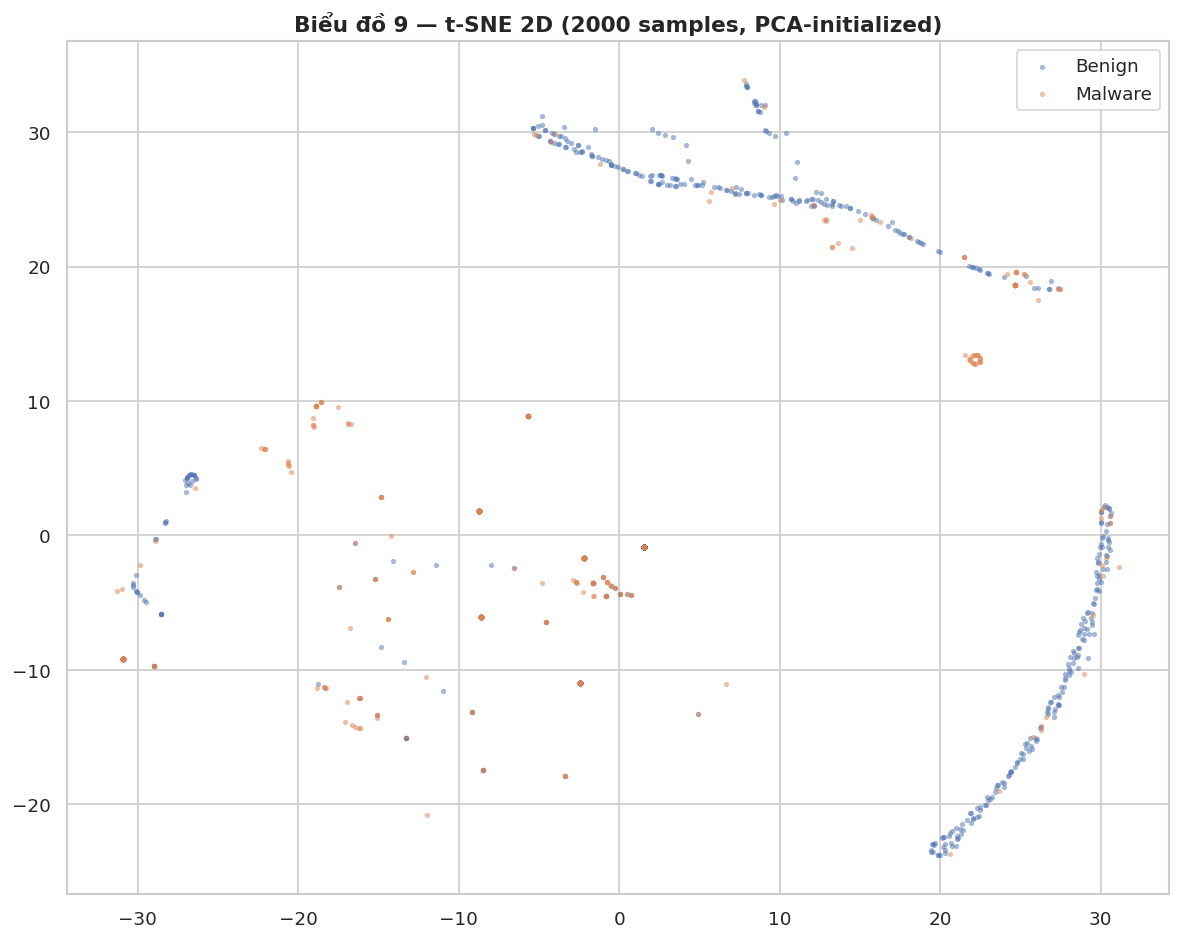

In [36]:
print("\n[3.9] t-SNE 2D (2K sample)...")
tsne_idx = np.random.choice(len(X_sample), min(2000, len(X_sample)), replace=False)
X_tsne_in = X_pca[tsne_idx]  # Use PCA-reduced (faster)
y_tsne    = y_sample[tsne_idx]

tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=500, verbose=0)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 8))
for cls, color, lbl in [(0,"#4C72B0","Benign"),(1,"#DD8452","Malware")]:
    mask = y_tsne == cls
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], c=color, alpha=0.5,
               s=10, label=lbl, linewidths=0)
ax.set_title("Biểu đồ 9 — t-SNE 2D (2000 samples, PCA-initialized)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("eda_viz_09_tsne.png", bbox_inches="tight")
plt.show()


[3.10] Outlier proportion per feature...


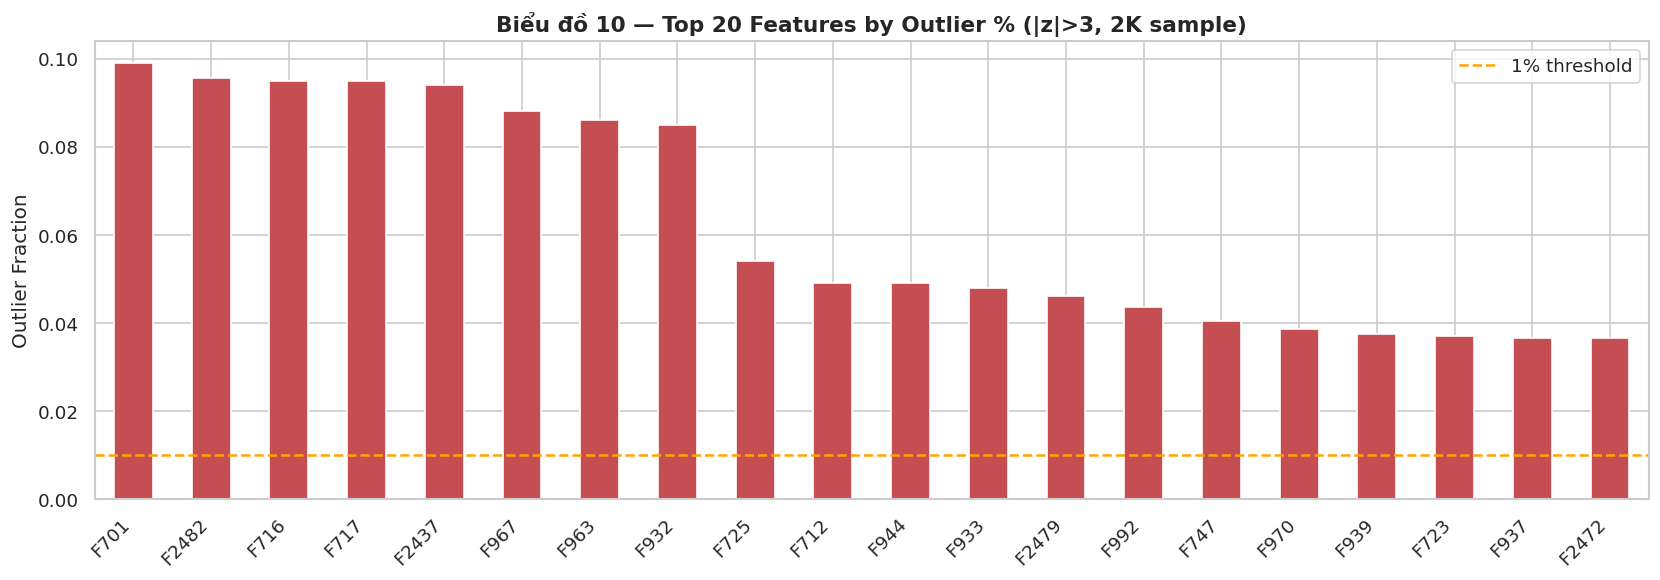

In [37]:
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
print("\n[3.10] Outlier proportion per feature...")
sample2k = X_train.sample(2000, random_state=SEED)
z = np.abs(stats.zscore(sample2k.fillna(sample2k.median())))
outlier_pct = pd.Series((z > 3).mean(axis=0), index=sample2k.columns)
top20_outlier = outlier_pct.nlargest(20)

fig, ax = plt.subplots(figsize=(14, 5))
top20_outlier.plot(kind="bar", ax=ax, color="#C44E52", edgecolor="white")
ax.axhline(0.01, color="orange", linestyle="--", linewidth=1.5, label="1% threshold")
ax.set_title("Biểu đồ 10 — Top 20 Features by Outlier % (|z|>3, 2K sample)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels([f"F{c}" for c in top20_outlier.index], rotation=45, ha="right")
ax.set_ylabel("Outlier Fraction"); ax.legend()
plt.tight_layout()
plt.savefig("eda_viz_10_outlier.png", bbox_inches="tight")
plt.show()


[3.12] Mutual Information (5K sample)...


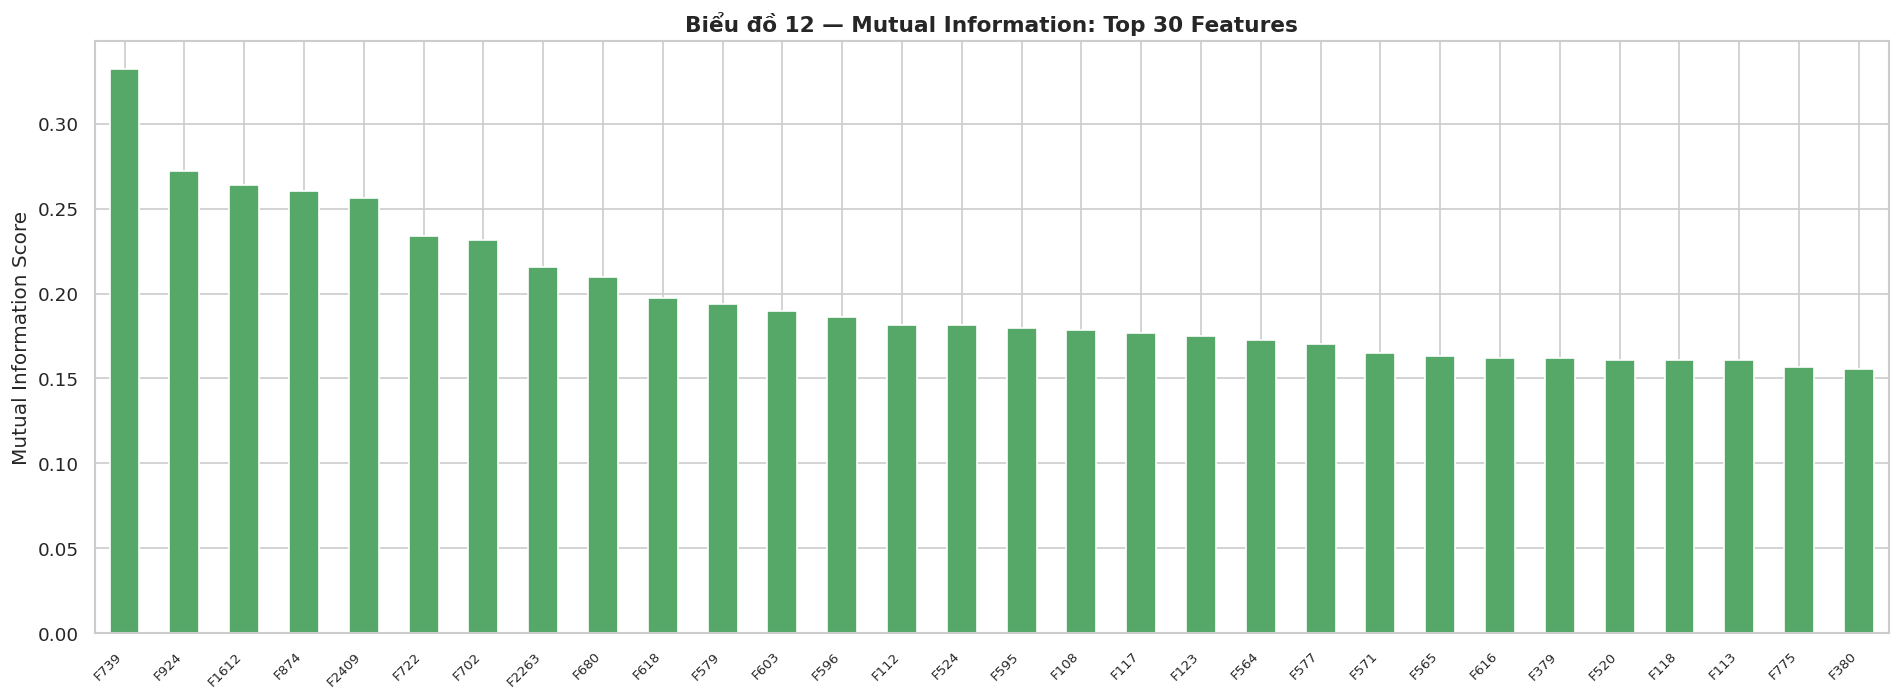

In [39]:
print("\n[3.12] Mutual Information (5K sample)...")
mi_idx  = np.random.choice(len(X_train), 5000, replace=False)
mi_vals = mutual_info_classif(
    X_train.values[mi_idx], y_train.values[mi_idx],
    discrete_features=False, random_state=SEED
)
mi_series = pd.Series(mi_vals, index=X_train.columns).nlargest(30)

fig, ax = plt.subplots(figsize=(16, 6))
mi_series.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Biểu đồ 12 — Mutual Information: Top 30 Features",
             fontsize=13, fontweight="bold")
ax.set_xticklabels([f"F{c}" for c in mi_series.index], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mutual Information Score")
plt.tight_layout()
plt.savefig("eda_viz_12_mutual_info.png", bbox_inches="tight")
plt.show()


BƯỚC 4 — PHÂN LOẠI ĐẶC TRƯNG

[4.1] Feature by Range Category:
range_cat
Small range         1129
Normalized [0,1]     863
Large range          238
Medium range         164

[4.2] Feature by Skewness:
skew_cat
Extreme skew     2222
High skew          93
Moderate skew      59
Symmetric          20

[4.3] Feature by Type:
  Binary (nunique<=3):   955
  Integer-like:         1727
  Continuous float:     667
  Has negative values:  369

[4.4] Feature by Correlation with Label:
corr_cat
Weak (<0.1)           2009
Moderate (0.1-0.3)     299
Strong (>0.3)           86


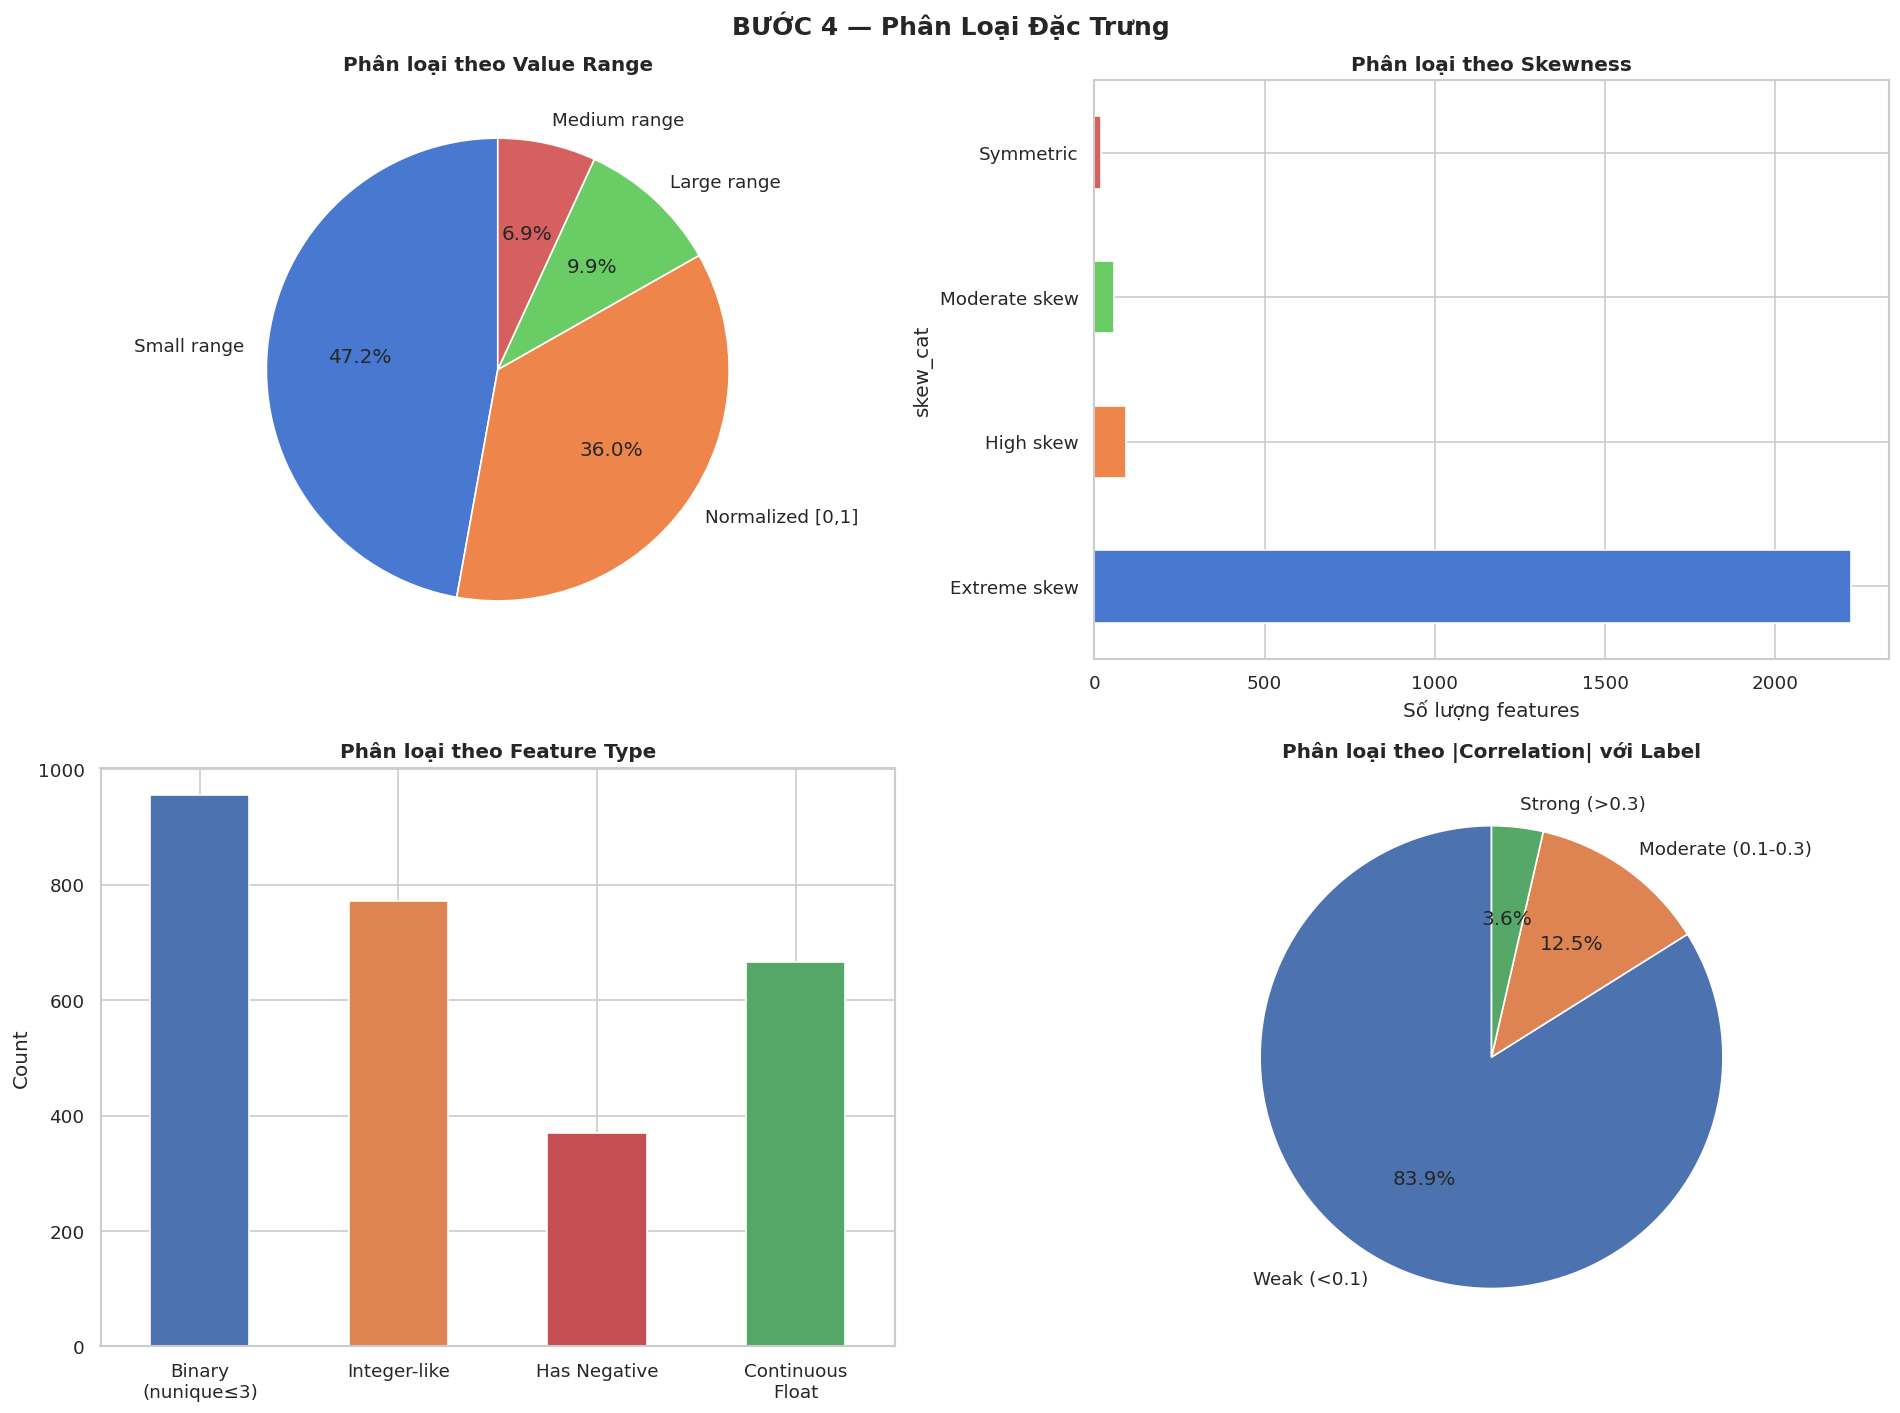


[4.5] Top 20 features by Mutual Information:
      corr_label  mi_score         range_cat       skew_cat  binary  has_negative
739       0.7890    0.3319  Normalized [0,1]      Symmetric    True         False
924       0.4476    0.2723      Medium range  Moderate skew   False          True
1612      0.7096    0.2637       Small range      Symmetric   False         False
874       0.0167    0.2605       Large range   Extreme skew   False          True
2409      0.0174    0.2560       Large range   Extreme skew   False         False
722       0.0037    0.2337       Large range   Extreme skew   False         False
702       0.6589    0.2315       Small range      Symmetric   False         False
2263      0.6714    0.2158       Small range      Symmetric   False         False
680       0.1492    0.2099       Large range   Extreme skew   False         False
618       0.5040    0.1973       Small range      Symmetric   False         False
579       0.4065    0.1939  Normalized [0,1]   Extre

In [40]:
print("\n" + "="*60)
print("BƯỚC 4 — PHÂN LOẠI ĐẶC TRƯNG")
print("="*60)

feat_stats = pd.DataFrame({
    "mean":    X_train.mean(),
    "std":     X_train.std(),
    "min":     X_train.min(),
    "max":     X_train.max(),
    "skew":    X_train.skew(),
    "kurt":    X_train.kurt(),
    "nunique": X_train.nunique(),
    "corr_label": X_train.corrwith(
        pd.Series(y_train.values, index=X_train.index)).abs(),
    "mi_score": pd.Series(mi_vals, index=X_train.columns),
})
feat_stats["range"] = feat_stats["max"] - feat_stats["min"]
feat_stats["has_negative"] = (X_train.min() < 0)

# Category 1: by value range
def classify_range(row):
    r = row["range"]
    if r == 0: return "Constant"
    elif r <= 1: return "Normalized [0,1]"
    elif r <= 10: return "Small range"
    elif r <= 1000: return "Medium range"
    else: return "Large range"

feat_stats["range_cat"] = feat_stats.apply(classify_range, axis=1)

# Category 2: by skewness
def classify_skew(s):
    if abs(s) < 0.5: return "Symmetric"
    elif abs(s) < 2: return "Moderate skew"
    elif abs(s) < 5: return "High skew"
    else: return "Extreme skew"
feat_stats["skew_cat"] = feat_stats["skew"].apply(classify_skew)

# Category 3: binary vs continuous
feat_stats["binary"] = feat_stats["nunique"] <= 3
feat_stats["integer_like"] = (X_train.apply(lambda c: (c.dropna() % 1 == 0).all()))

# Category 4: by correlation strength
def classify_corr(v):
    if v > 0.3: return "Strong (>0.3)"
    elif v > 0.1: return "Moderate (0.1-0.3)"
    else: return "Weak (<0.1)"
feat_stats["corr_cat"] = feat_stats["corr_label"].apply(classify_corr)

# Summary
print("\n[4.1] Feature by Range Category:")
rc = feat_stats["range_cat"].value_counts()
print(rc.to_string())

print("\n[4.2] Feature by Skewness:")
sc = feat_stats["skew_cat"].value_counts()
print(sc.to_string())

print("\n[4.3] Feature by Type:")
print(f"  Binary (nunique<=3):   {feat_stats['binary'].sum()}")
print(f"  Integer-like:         {feat_stats['integer_like'].sum()}")
print(f"  Continuous float:     {(~feat_stats['binary'] & ~feat_stats['integer_like']).sum()}")
print(f"  Has negative values:  {feat_stats['has_negative'].sum()}")

print("\n[4.4] Feature by Correlation with Label:")
print(feat_stats["corr_cat"].value_counts().to_string())

# Visualize feature classification
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Range category pie
axes[0][0].pie(rc.values, labels=rc.index, autopct="%1.1f%%",
               colors=sns.color_palette("muted", len(rc)), startangle=90)
axes[0][0].set_title("Phân loại theo Value Range", fontsize=12, fontweight="bold")

# Skewness category bar
sc.plot(kind="barh", ax=axes[0][1], color=sns.color_palette("muted", len(sc)))
axes[0][1].set_title("Phân loại theo Skewness", fontsize=12, fontweight="bold")
axes[0][1].set_xlabel("Số lượng features")

# Feature type bar
type_counts = pd.Series({
    "Binary\n(nunique≤3)": feat_stats["binary"].sum(),
    "Integer-like": feat_stats["integer_like"].sum() - feat_stats["binary"].sum(),
    "Has Negative": feat_stats["has_negative"].sum(),
    "Continuous\nFloat": (~feat_stats["binary"] & ~feat_stats["integer_like"]).sum(),
})
type_counts.plot(kind="bar", ax=axes[1][0],
                 color=["#4C72B0","#DD8452","#C44E52","#55A868"], rot=0, edgecolor="white")
axes[1][0].set_title("Phân loại theo Feature Type", fontsize=12, fontweight="bold")
axes[1][0].set_ylabel("Count")

# Correlation category pie
cc = feat_stats["corr_cat"].value_counts()
axes[1][1].pie(cc.values, labels=cc.index, autopct="%1.1f%%",
               colors=["#4C72B0","#DD8452","#55A868"][:len(cc)], startangle=90)
axes[1][1].set_title("Phân loại theo |Correlation| với Label", fontsize=12, fontweight="bold")

plt.suptitle("BƯỚC 4 — Phân Loại Đặc Trưng", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_step4_feature_class.png", bbox_inches="tight")
plt.show()

# Top 20 features summary table
print("\n[4.5] Top 20 features by Mutual Information:")
top20_mi = feat_stats.nlargest(20, "mi_score")[
    ["corr_label","mi_score","range_cat","skew_cat","binary","has_negative"]
].round(4)
print(top20_mi.to_string())


BƯỚC 5 — PHÂN BỐ LABEL


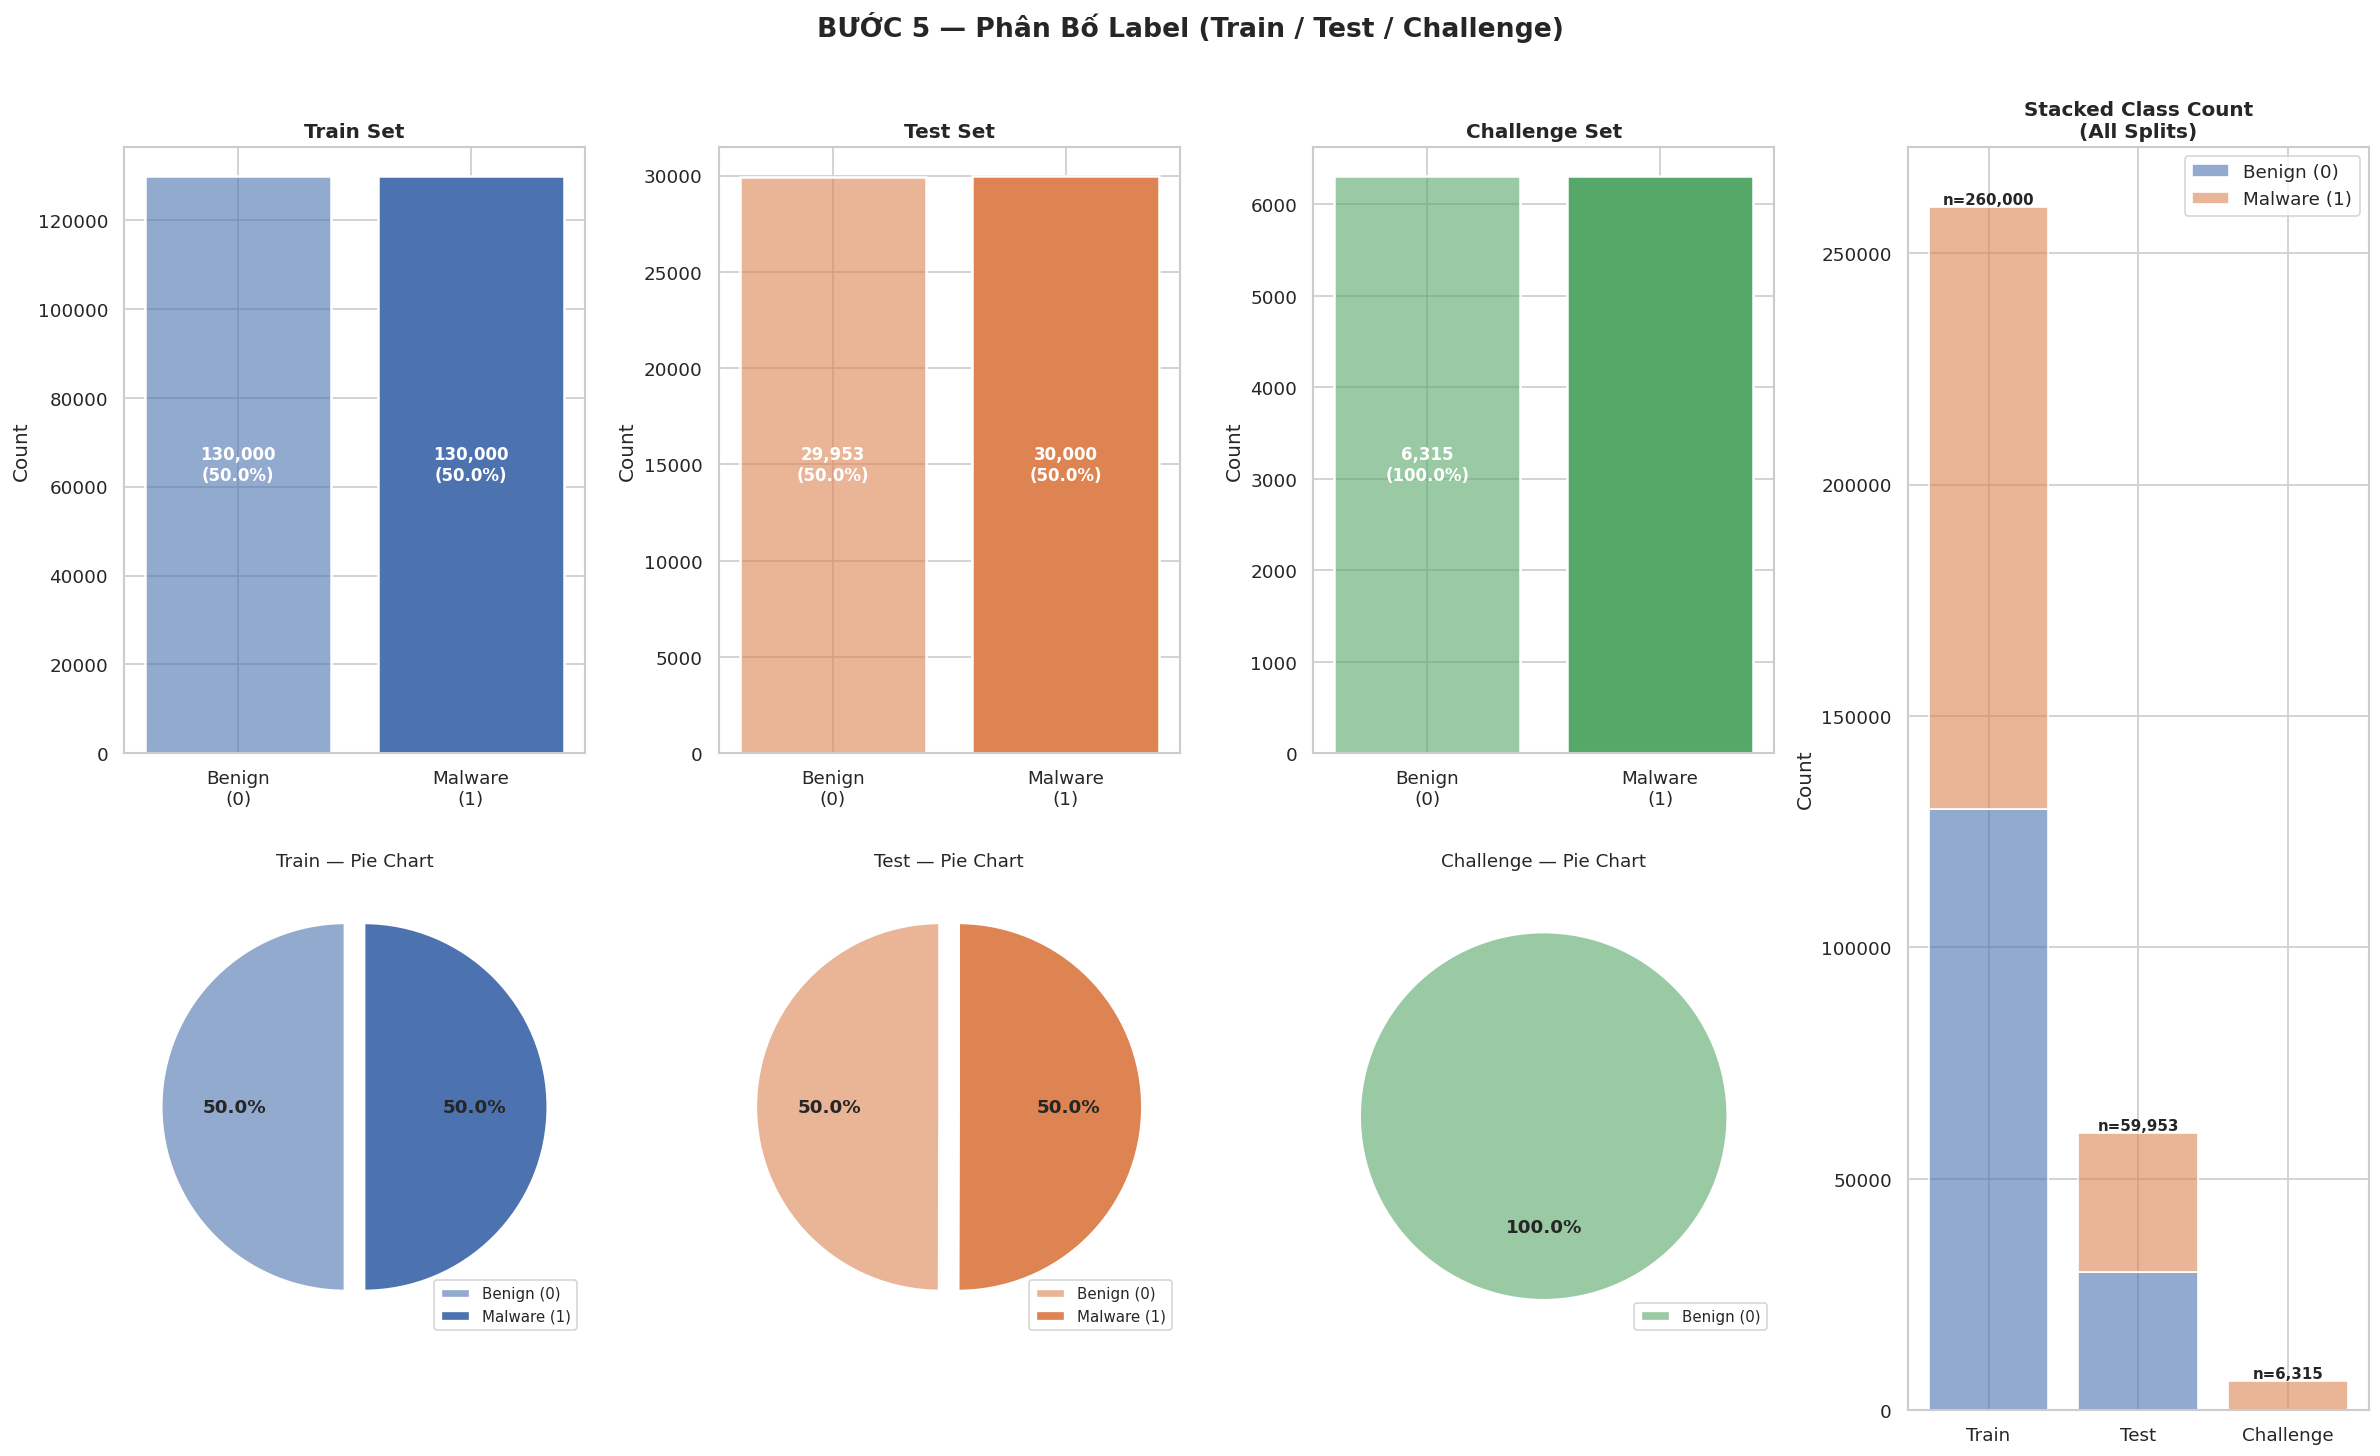


[Label Summary]
  Train       : 0=130,000 | 1=130,000 | Ratio 1:0 = 1.000 | BALANCED
  Test        : 0= 29,953 | 1= 30,000 | Ratio 1:0 = 1.002 | BALANCED
  Challenge   : 0=      0 | 1=  6,315 | Ratio 1:0 = 6315.000 | IMBALANCED


In [41]:
print("\n" + "="*60)
print("BƯỚC 5 — PHÂN BỐ LABEL")
print("="*60)

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 4, figure=fig)

splits = [
    ("Train",     y_train, "#4C72B0"),
    ("Test",      y_test,  "#DD8452"),
    ("Challenge", y_chal,  "#55A868"),
]

# 5.1 Bar charts
for i, (name, y, color) in enumerate(splits):
    ax = fig.add_subplot(gs[0, i])
    vc = y.value_counts().sort_index()
    bars = ax.bar(["Benign\n(0)","Malware\n(1)"], vc.values,
                  color=[color+"99", color], edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                f"{val:,}\n({val/len(y)*100:.1f}%)",
                ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    ax.set_title(f"{name} Set", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")

# 5.2 Pie charts
for i, (name, y, color) in enumerate(splits):
    ax = fig.add_subplot(gs[1, i])
    vc = y.value_counts().sort_index()
    wedge_colors = [color+"99", color]
    pcts = [v/len(y)*100 for v in vc.values]
    wedges, texts, autotexts = ax.pie(
        vc.values, autopct="%1.1f%%", startangle=90,
        colors=wedge_colors,
        explode=[0.05]*len(vc),
        wedgeprops={"edgecolor":"white","linewidth":2}
    )
    for at in autotexts: at.set_fontsize(11); at.set_fontweight("bold")
    ax.set_title(f"{name} — Pie Chart", fontsize=11)
    ax.legend(["Benign (0)","Malware (1)"], loc="lower right", fontsize=9)

# 5.3 Combined stacked bar
ax_stack = fig.add_subplot(gs[:, 3])
split_names = ["Train","Test","Challenge"]
counts_0 = [y_train.value_counts().get(0,0),
            y_test.value_counts().get(0,0),
            y_chal.value_counts().get(0,0)]
counts_1 = [y_train.value_counts().get(1,0),
            y_test.value_counts().get(1,0),
            y_chal.value_counts().get(1,0)]
x = range(3)
b0 = ax_stack.bar(x, counts_0, label="Benign (0)", color="#4C72B099", edgecolor="white")
b1 = ax_stack.bar(x, counts_1, bottom=counts_0, label="Malware (1)", color="#DD845299", edgecolor="white")
ax_stack.set_xticks(list(x)); ax_stack.set_xticklabels(split_names)
ax_stack.set_title("Stacked Class Count\n(All Splits)", fontsize=12, fontweight="bold")
ax_stack.set_ylabel("Count")
ax_stack.legend()
for bar, v0, v1, tot in zip(b0, counts_0, counts_1, [len(y_train), len(y_test), len(y_chal)]):
    ax_stack.text(bar.get_x() + bar.get_width()/2, tot + 500,
                  f"n={tot:,}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("BƯỚC 5 — Phân Bố Label (Train / Test / Challenge)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_step5_label_dist.png", bbox_inches="tight")
plt.show()

print("\n[Label Summary]")
for name, y in [("Train", y_train),("Test", y_test),("Challenge", y_chal)]:
    vc = y.value_counts().sort_index()
    ratio = vc.get(1,0) / max(vc.get(0,1), 1)
    print(f"  {name:12s}: 0={vc.get(0,0):>7,} | 1={vc.get(1,0):>7,} | "
          f"Ratio 1:0 = {ratio:.3f} | "
          f"{'BALANCED' if 0.8<ratio<1.2 else 'IMBALANCED' if ratio<0.5 or ratio>2 else 'SLIGHTLY IMBALANCED'}")


BƯỚC 6 — PHÂN TÍCH CHÍNH XÁC DỮ LIỆU

[6.1] Point-biserial correlation test (top 15 features):
feature      corr  abs_corr  p_value  significant
    739 -0.788974  0.788974      0.0         True
   1612  0.709625  0.709625      0.0         True
   2263 -0.671368  0.671368      0.0         True
    702 -0.658913  0.658913      0.0         True
    595 -0.550792  0.550792      0.0         True
    112 -0.512918  0.512918      0.0         True
    123 -0.511173  0.511173      0.0         True
    618  0.503988  0.503988      0.0         True
    600 -0.488657  0.488657      0.0         True
    108 -0.485686  0.485686      0.0         True
    117 -0.476169  0.476169      0.0         True
    118 -0.472142  0.472142      0.0         True
    604 -0.468596  0.468596      0.0         True
    121 -0.456378  0.456378      0.0         True
    924  0.447629  0.447629      0.0         True

[6.2] Descriptive stats by class — Top 10 features:

  Feature 739:
         Benign(0)   Malware(1)
cou

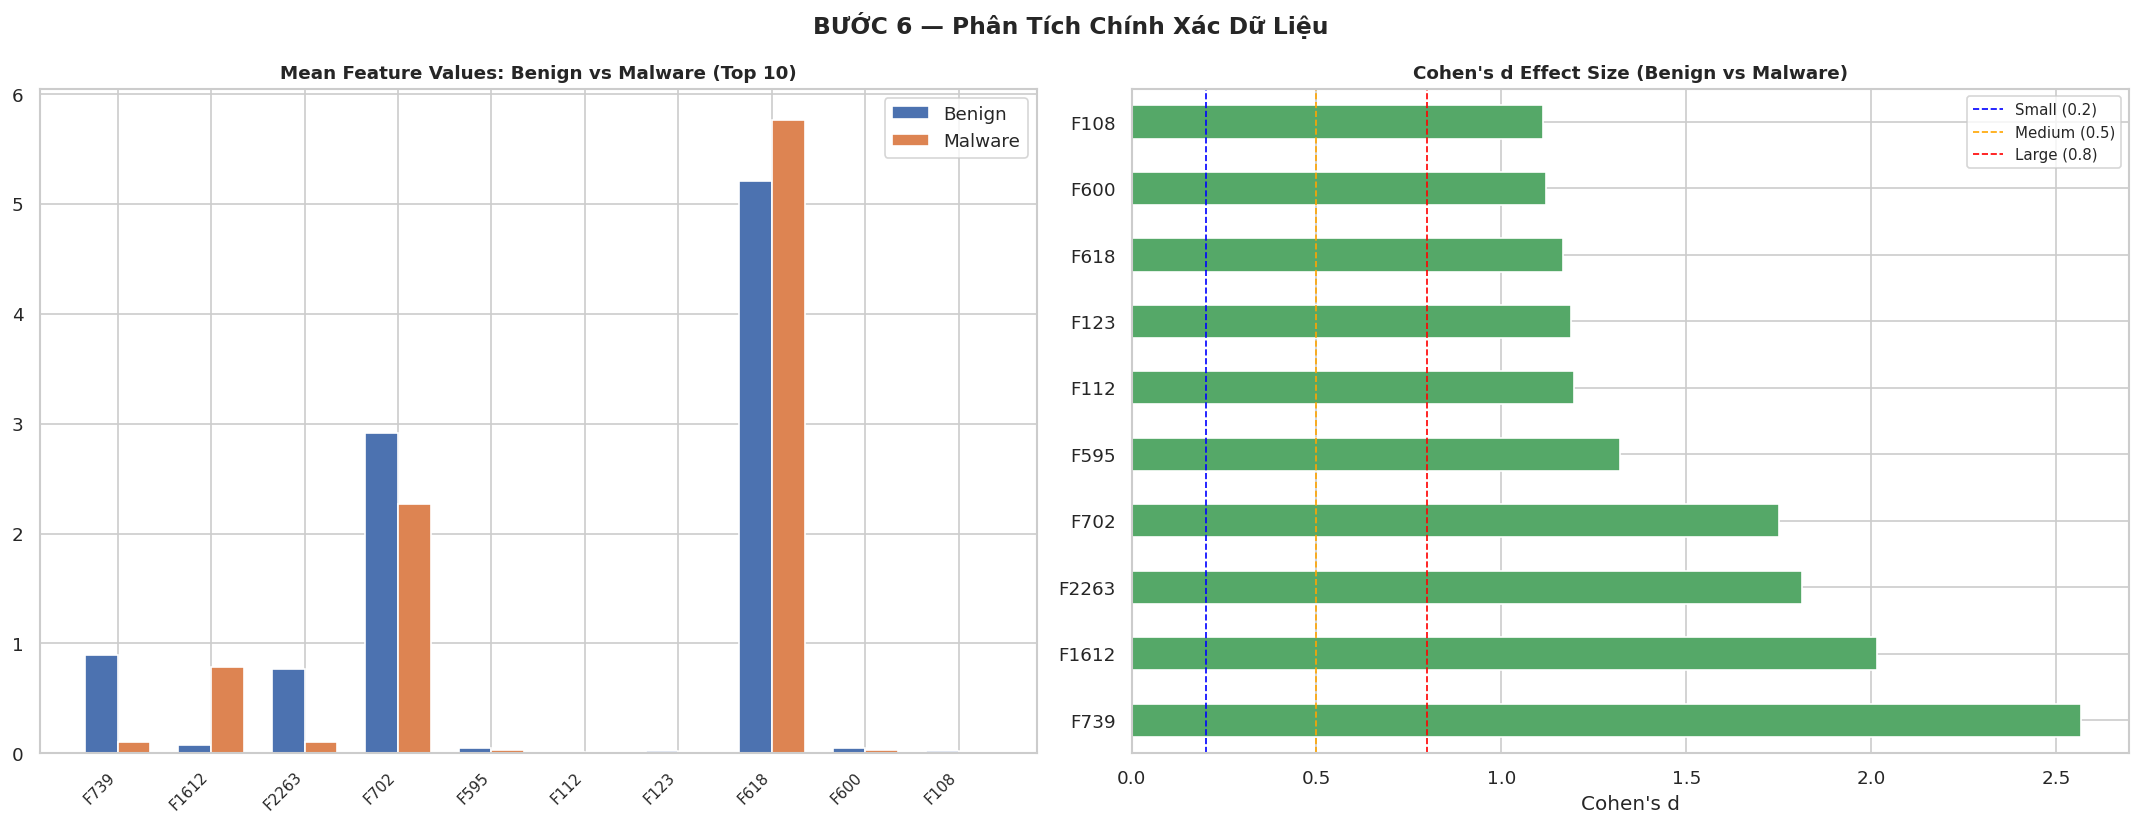


[6.6] Final EDA Summary — All Feature Stats (top 30 by MI):
      corr_label  mi_score        skew         range_cat       skew_cat  binary  has_negative            corr_cat
739       0.7890    0.3319   -0.011200  Normalized [0,1]      Symmetric    True         False       Strong (>0.3)
924       0.4476    0.2723    0.500600      Medium range  Moderate skew   False          True       Strong (>0.3)
1612      0.7096    0.2637    0.281400       Small range      Symmetric   False         False       Strong (>0.3)
874       0.0167    0.2605  128.954605       Large range   Extreme skew   False          True         Weak (<0.1)
2409      0.0174    0.2560  182.337006       Large range   Extreme skew   False         False         Weak (<0.1)
722       0.0037    0.2337  264.424500       Large range   Extreme skew   False         False         Weak (<0.1)
702       0.6589    0.2315   -0.381500       Small range      Symmetric   False         False       Strong (>0.3)
2263      0.6714    0.2158 

In [42]:
print("\n" + "="*60)
print("BƯỚC 6 — PHÂN TÍCH CHÍNH XÁC DỮ LIỆU")
print("="*60)

# 6.1 Statistical tests: Point-biserial correlation (feature vs binary label)
print("\n[6.1] Point-biserial correlation test (top 15 features):")
pb_results = []
for feat in corr_with_label.nlargest(15).index:
    corr_val, p_val = pointbiserialr(y_train.values, X_train[feat].values)
    pb_results.append({
        "feature": feat,
        "corr": corr_val,
        "abs_corr": abs(corr_val),
        "p_value": p_val,
        "significant": p_val < 0.05
    })
pb_df = pd.DataFrame(pb_results).sort_values("abs_corr", ascending=False)
print(pb_df.to_string(index=False))

# 6.2 Detailed stats per class
print("\n[6.2] Descriptive stats by class — Top 10 features:")
top10 = corr_with_label.nlargest(10).index.tolist()
for feat in top10[:5]:
    s0 = X_train.loc[y_train==0, feat].describe()
    s1 = X_train.loc[y_train==1, feat].describe()
    print(f"\n  Feature {feat}:")
    cmp = pd.DataFrame({"Benign(0)": s0, "Malware(1)": s1})
    print(cmp.round(4).to_string())

# 6.3 Mann-Whitney U test (non-parametric) on top 20 features
print("\n[6.3] Mann-Whitney U test (non-parametric significance):")
mw_results = []
for feat in corr_with_label.nlargest(20).index:
    d0 = X_train.loc[y_train==0, feat].values
    d1 = X_train.loc[y_train==1, feat].values
    stat, p = stats.mannwhitneyu(d0, d1, alternative="two-sided")
    effect_size = abs(corr_with_label[feat])  # use pearson r as effect proxy
    mw_results.append({"feature": feat, "U_stat": stat, "p_value": p,
                        "effect_|r|": effect_size, "sig": "***" if p<0.001 else "**" if p<0.01 else "*"})
mw_df = pd.DataFrame(mw_results)
print(mw_df.to_string(index=False))

# 6.4 Distribution shift: Train vs Challenge (for top 10 features)
print("\n[6.4] Distribution shift: Train vs Challenge (KS test, top 10):")
ks_results = []
for feat in corr_with_label.nlargest(10).index:
    if feat not in X_chal.columns: continue
    stat, p = stats.ks_2samp(X_train[feat].dropna(), X_chal[feat].dropna())
    ks_results.append({"feature": feat, "KS_stat": stat, "p_value": round(p, 6),
                        "shifted": "YES" if stat > 0.1 else "no"})
ks_df = pd.DataFrame(ks_results)
print(ks_df.to_string(index=False))

# 6.5 Full statistical summary with class comparison (visual)
top10_corr_feats = corr_with_label.nlargest(10).index.tolist()
class_means = pd.DataFrame({
    "Benign (0)":  X_train.loc[y_train==0, top10_corr_feats].mean(),
    "Malware (1)": X_train.loc[y_train==1, top10_corr_feats].mean(),
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
x_pos = np.arange(10)
width = 0.35
axes[0].bar(x_pos - width/2, class_means["Benign (0)"],  width, label="Benign",
            color="#4C72B0", edgecolor="white")
axes[0].bar(x_pos + width/2, class_means["Malware (1)"], width, label="Malware",
            color="#DD8452", edgecolor="white")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f"F{c}" for c in top10_corr_feats], rotation=45, ha="right", fontsize=9)
axes[0].set_title("Mean Feature Values: Benign vs Malware (Top 10)", fontsize=11, fontweight="bold")
axes[0].legend()

# Effect size (Cohen's d)
def cohens_d(x0, x1):
    n0, n1 = len(x0), len(x1)
    pooled_std = np.sqrt(((n0-1)*np.var(x0) + (n1-1)*np.var(x1)) / (n0+n1-2))
    return abs(np.mean(x0) - np.mean(x1)) / (pooled_std + 1e-8)

d_vals = [cohens_d(X_train.loc[y_train==0, f].values,
                   X_train.loc[y_train==1, f].values) for f in top10_corr_feats]
d_series = pd.Series(d_vals, index=[f"F{c}" for c in top10_corr_feats])
d_series.plot(kind="barh", ax=axes[1], color="#55A868", edgecolor="white")
axes[1].axvline(0.2, color="blue",   linestyle="--", linewidth=1, label="Small (0.2)")
axes[1].axvline(0.5, color="orange", linestyle="--", linewidth=1, label="Medium (0.5)")
axes[1].axvline(0.8, color="red",    linestyle="--", linewidth=1, label="Large (0.8)")
axes[1].set_title("Cohen's d Effect Size (Benign vs Malware)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Cohen's d"); axes[1].legend(fontsize=9)
plt.suptitle("BƯỚC 6 — Phân Tích Chính Xác Dữ Liệu", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_step6_analysis.png", bbox_inches="tight")
plt.show()

# 6.6 Summary table — full feature analysis
print("\n[6.6] Final EDA Summary — All Feature Stats (top 30 by MI):")
top30_mi_feats = feat_stats.nlargest(30, "mi_score")
display_cols = ["corr_label","mi_score","skew","range_cat","skew_cat","binary","has_negative","corr_cat"]
print(top30_mi_feats[display_cols].round(4).to_string())

# ── Final Summary ─────────────────────────────────────────────
print("\n" + "="*70)
print("✅ EDA HOÀN TẤT — TỔNG KẾT")
print("="*70)
print(f"  Dataset:      260,000 train × {N_FEAT} features (sau khi làm sạch)")
print(f"  Missing:      0  |  Duplicates: {dup_count}  |  Inf values: {inf_count}")
print(f"  Constants dropped:   {N_FEAT_ORIG - N_FEAT if 'N_FEAT_ORIG' in dir() else '~174'}")
print(f"  Highly skewed (|s|>2): {(skewness.abs()>2).sum()} features")
print(f"  Binary features:     {feat_stats['binary'].sum()}")
print(f"  Has negative:        {feat_stats['has_negative'].sum()}")
print(f"\n  LABEL DISTRIBUTION:")
print(f"  Train:     50/50 (BALANCED) ✅")
print(f"  Test:      ~50/50 (BALANCED) ✅")
print(f"  Challenge: 100% nhãn 1 (SEVERE DISTRIBUTION SHIFT) ⚠️")
print(f"\n  KEY FEATURES (top 5 by MI):")
for f in feat_stats.nlargest(5,"mi_score").index:
    print(f"    Feature {f}: MI={feat_stats.loc[f,'mi_score']:.4f}, "
          f"|r|={feat_stats.loc[f,'corr_label']:.4f}, "
          f"type={'Binary' if feat_stats.loc[f,'binary'] else 'Continuous'}")
print(f"\n  Plots saved: eda_viz_01~12 + eda_step1,4,5,6 (16 PNG files)")
print("="*70)

### Summary table

In [43]:
print("\n📋 Shape & Class Distribution:")
for name, X, y in [
    ("Train",     X_train,     y_train),
    ("Test",      X_test,      y_test),
    ("Challenge", X_chal, y_chal),
]:
    vc = y.value_counts()
    pct = y.value_counts(normalize=True) * 100
    print(f"  {name:10s}: X={X.shape}  |  "
          f"0={vc.get(0,0):,} ({pct.get(0,0):.1f}%)  "
          f"1={vc.get(1,0):,} ({pct.get(1,0):.1f}%)")

print(f"\n💾 RAM usage: {(X_train.memory_usage(deep=True).sum() / 1e9):.2f} GB (train)")

# Missing values check
total_missing = (X_train.isna().sum().sum() +
                 X_test.isna().sum().sum() +
                 X_chal.isna().sum().sum())
print(f"\n🔍 Missing values tổng cộng: {total_missing}")


📋 Shape & Class Distribution:
  Train     : X=(260000, 2394)  |  0=130,000 (50.0%)  1=130,000 (50.0%)
  Test      : X=(59953, 2394)  |  0=29,953 (50.0%)  1=30,000 (50.0%)
  Challenge : X=(6315, 2394)  |  0=0 (0.0%)  1=6,315 (100.0%)

💾 RAM usage: 2.49 GB (train)

🔍 Missing values tổng cộng: 0


## 🔧 Step 3 — Preprocessing Pipeline

In [50]:
print("\n" + "="*60)
print("STEP 3 — PREPROCESSING")
print("="*60)


STEP 3 — PREPROCESSING


### 3.1 Drop constant & near-zero-variance features

In [51]:
print("🗑 Dropping constant+near-zero-variance features...")
vt = VarianceThreshold(threshold=1e-5)
X_train_np = vt.fit_transform(X_train)
X_test_np  = vt.transform(X_test)
X_chal_np  = vt.transform(X_chal)

n_before = X_train.shape[1]
n_after  = X_train_np.shape[1]
print(f"  Features: {n_before} → {n_after} (dropped {n_before - n_after})")

# Feature names còn lại
kept_cols = X_train.columns[vt.get_support()]

🗑 Dropping constant+near-zero-variance features...
  Features: 2394 → 2051 (dropped 343)


### 3.2 Clip extreme outliers (winsorize at 1%-99% per feature)

In [52]:

print("✂ Clipping outliers at 1st–99th percentile (fit on train)...")
p01 = np.percentile(X_train_np, 1, axis=0)
p99 = np.percentile(X_train_np, 99, axis=0)
X_train_np  = np.clip(X_train_np,  p01, p99)
X_test_np   = np.clip(X_test_np,   p01, p99)
X_chal_np   = np.clip(X_chal_np,   p01, p99)
print("  → Clipping done (fit on train only — no leakage)")

✂ Clipping outliers at 1st–99th percentile (fit on train)...
  → Clipping done (fit on train only — no leakage)


### 3.3 Scaler (cho linear models, tree models sẽ dùng raw)

In [53]:
print("⚖ Fitting StandardScaler on train...")
scaler = RobustScaler()   # RobustScaler sturdy hơn với outlier còn sót
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled  = scaler.transform(X_test_np)
X_chal_scaled  = scaler.transform(X_chal_np)
print(f"  Scaled shape: {X_train_scaled.shape}")

y_train_np  = y_train.values
y_test_np   = y_test.values
y_chal_np   = y_chal.values

del X_train, X_test, X_chal  # free RAM
gc.collect()
print("✅ Preprocessing hoàn tất")

⚖ Fitting StandardScaler on train...
  Scaled shape: (260000, 2051)
✅ Preprocessing hoàn tất


## 🤖 Step 4 — Feature Engineering

In [54]:
print("\n" + "="*60)
print("STEP 4 — FEATURE ENGINEERING")
print("="*60)


STEP 4 — FEATURE ENGINEERING


### 4.1 Quick LightGBM fit để lấy Feature Importance

🌳 Quick LightGBM (100 rounds) để rank feature importance...


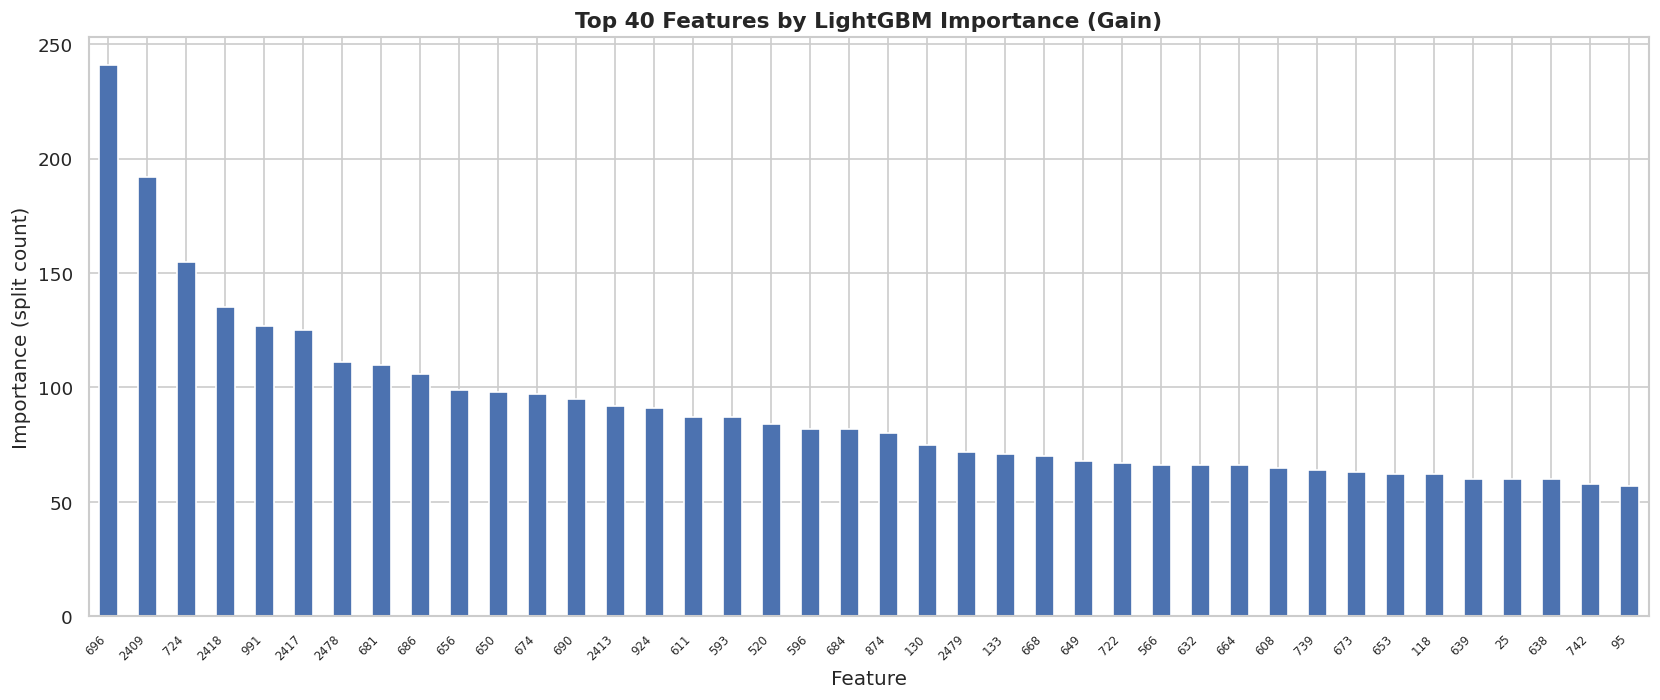

  Top features covering 99% importance: 443 / 2051
  Final feature matrix: (260000, 443)
✅ Feature engineering hoàn tất


In [55]:
print("🌳 Quick LightGBM (100 rounds) để rank feature importance...")
quick_lgb = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=63,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
quick_lgb.fit(X_train_np, y_train_np)  # dùng raw (không cần scale cho tree)

importance = pd.Series(quick_lgb.feature_importances_, index=kept_cols)
importance_sorted = importance.sort_values(ascending=False)

# Plot top 40
fig, ax = plt.subplots(figsize=(14, 6))
importance_sorted.head(40).plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Top 40 Features by LightGBM Importance (Gain)", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance (split count)")
ax.set_xticklabels([str(x) for x in importance_sorted.head(40).index],
                    rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("feat_importance_quick.png", bbox_inches="tight")
plt.show()

# ── 4.2 Select top features (cumulative importance ≥ 99%) ─
cumsum = importance_sorted.cumsum() / importance_sorted.sum()
n_top = (cumsum < 0.99).sum() + 1
print(f"  Top features covering 99% importance: {n_top} / {len(importance_sorted)}")

top_feat_names = importance_sorted.head(n_top).index
top_feat_idx   = [list(kept_cols).index(f) for f in top_feat_names]

X_train_sel  = X_train_np[:, top_feat_idx]
X_test_sel   = X_test_np[:, top_feat_idx]
X_chal_sel   = X_chal_np[:, top_feat_idx]

X_train_sel_sc = X_train_scaled[:, top_feat_idx]
X_test_sel_sc  = X_test_scaled[:, top_feat_idx]
X_chal_sel_sc  = X_chal_scaled[:, top_feat_idx]

print(f"  Final feature matrix: {X_train_sel.shape}")
print("✅ Feature engineering hoàn tất")

## 🤖 Step 5 — Model Training with Cross-Validation

In [56]:
print("\n" + "="*60)
print("STEP 5 — MODEL TRAINING (5-Fold Stratified CV)")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_evaluate(model, X, y, model_name):
    """Train model with CV, return mean AUC and F1."""
    aucs, f1s = [], []
    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_val)[:, 1]
        pred = (prob >= 0.5).astype(int)
        aucs.append(roc_auc_score(y_val, prob))
        f1s.append(f1_score(y_val, pred))
    mean_auc = np.mean(aucs)
    mean_f1  = np.mean(f1s)
    print(f"  {model_name:30s}  AUC={mean_auc:.4f} ± {np.std(aucs):.4f}  |  F1={mean_f1:.4f}")
    return mean_auc, mean_f1

# model_registry để so sánh
results = {}

# 5.1 LightGBM (default, không tune)
lgb_default = lgb.LGBMClassifier(
    n_estimators=500, num_leaves=127, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbose=-1
)
results["LGB_default"] = cv_evaluate(lgb_default, X_train_sel, y_train_np, "LightGBM (default)")

# 5.2 XGBoost (default)
xgb_default = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, eval_metric="logloss", verbosity=0
)
results["XGB_default"] = cv_evaluate(xgb_default, X_train_sel, y_train_np, "XGBoost (default)")

# 5.3 HistGradientBoosting (sklearn, fast)
hgb_default = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_leaf_nodes=127,
    random_state=SEED
)
results["HGB_default"] = cv_evaluate(hgb_default, X_train_sel, y_train_np, "HistGradBoost (default)")

# 5.4 RandomForest (ensemble component)
rf_default = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    random_state=SEED, n_jobs=-1
)
results["RF_default"] = cv_evaluate(rf_default, X_train_sel, y_train_np, "RandomForest (300)")

# 5.5 LogisticRegression (scaled features, linear baseline)
lr_model = LogisticRegression(
    C=1.0, max_iter=500, solver="lbfgs",
    random_state=SEED, n_jobs=-1
)
results["LR"] = cv_evaluate(lr_model, X_train_sel_sc, y_train_np, "LogisticRegression")

# Summary
print("\n📊 CV Summary:")
for k, (auc, f1) in sorted(results.items(), key=lambda x: -x[1][0]):
    print(f"  {k:30s}  AUC={auc:.4f}  F1={f1:.4f}")


STEP 5 — MODEL TRAINING (5-Fold Stratified CV)
  LightGBM (default)              AUC=0.9990 ± 0.0001  |  F1=0.9870
  XGBoost (default)               AUC=0.9987 ± 0.0001  |  F1=0.9846
  HistGradBoost (default)         AUC=0.9989 ± 0.0001  |  F1=0.9862
  RandomForest (300)              AUC=0.9977 ± 0.0002  |  F1=0.9786


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  LogisticRegression              AUC=0.8082 ± 0.0035  |  F1=0.7461

📊 CV Summary:
  LGB_default                     AUC=0.9990  F1=0.9870
  HGB_default                     AUC=0.9989  F1=0.9862
  XGB_default                     AUC=0.9987  F1=0.9846
  RF_default                      AUC=0.9977  F1=0.9786
  LR                              AUC=0.8082  F1=0.7461


## 🎛 Step 6 — Hyperparameter Tuning (Optuna)


STEP 6 — HYPERPARAMETER TUNING (Optuna + LightGBM)
✅ Optuna available
🔍 Running 50 Optuna trials (timeout=3600s)...


  0%|          | 0/50 [00:00<?, ?it/s]


🏆 Best CV AUC: 0.99902
   Best params: {'n_estimators': 937, 'num_leaves': 489, 'max_depth': 11, 'learning_rate': 0.060099747183803134, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.49359671220172163, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_samples': 62}


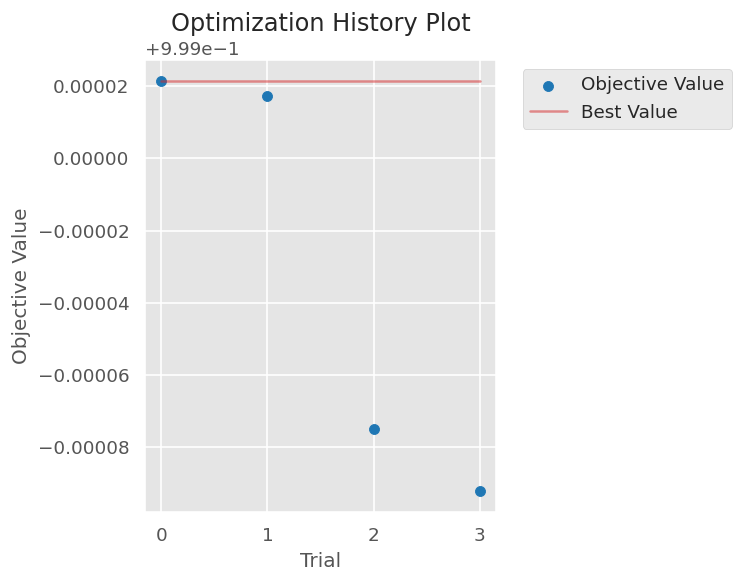


🎯 Training final LightGBM trên full train set...
✅ Final LightGBM trained


In [57]:
print("\n" + "="*60)
print("STEP 6 — HYPERPARAMETER TUNING (Optuna + LightGBM)")
print("="*60)

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print("✅ Optuna available")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠ Optuna không có — dùng RandomizedSearchCV fallback")

if OPTUNA_AVAILABLE:
    def lgb_objective(trial):
        params = {
            "n_estimators":       trial.suggest_int("n_estimators", 300, 2000),
            "num_leaves":         trial.suggest_int("num_leaves", 31, 512),
            "max_depth":          trial.suggest_int("max_depth", -1, 15),
            "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "min_child_samples":  trial.suggest_int("min_child_samples", 5, 100),
            "random_state": SEED,
            "n_jobs": -1,
            "verbose": -1,
        }
        model = lgb.LGBMClassifier(**params)
        aucs = []
        for tr_idx, val_idx in cv.split(X_train_sel, y_train_np):
            model.fit(X_train_sel[tr_idx], y_train_np[tr_idx])
            prob = model.predict_proba(X_train_sel[val_idx])[:, 1]
            aucs.append(roc_auc_score(y_train_np[val_idx], prob))
        return np.mean(aucs)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    print("🔍 Running 50 Optuna trials (timeout=3600s)...")
    study.optimize(lgb_objective, n_trials=50, timeout=3600, show_progress_bar=True)

    best_params = study.best_params
    print(f"\n🏆 Best CV AUC: {study.best_value:.5f}")
    print(f"   Best params: {best_params}")

    # Plot optimization history
    try:
        fig = optuna.visualization.matplotlib.plot_optimization_history(study)
        plt.tight_layout()
        plt.savefig("optuna_history.png", bbox_inches="tight")
        plt.show()
    except Exception:
        pass

else:
    # Fallback: RandomizedSearchCV
    from sklearn.model_selection import RandomizedSearchCV
    param_dist = {
        "n_estimators": [300, 500, 800, 1200],
        "num_leaves":   [63, 127, 255],
        "learning_rate": [0.02, 0.05, 0.1],
        "subsample":     [0.7, 0.8, 0.9],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_alpha":    [0.01, 0.1, 1.0],
        "reg_lambda":   [0.01, 0.1, 1.0],
    }
    lgb_base = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
    rs = RandomizedSearchCV(
        lgb_base, param_dist, n_iter=20,
        cv=cv, scoring="roc_auc",
        random_state=SEED, n_jobs=1, verbose=1
    )
    rs.fit(X_train_sel, y_train_np)
    best_params = rs.best_params_
    print(f"🏆 Best CV AUC (RandomizedSearch): {rs.best_score_:.5f}")
    print(f"   Best params: {best_params}")

# Train final LGB với best_params trên FULL train set
print("\n🎯 Training final LightGBM trên full train set...")
final_lgb = lgb.LGBMClassifier(**best_params, random_state=SEED, n_jobs=-1, verbose=-1)
final_lgb.fit(X_train_sel, y_train_np)
print("✅ Final LightGBM trained")

### 6.2 XGBoost Tuning (Optuna, nhanh hơn)

In [58]:
if OPTUNA_AVAILABLE:
    def xgb_objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 300, 1500),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
            "gamma":             trial.suggest_float("gamma", 0, 5),
            "random_state": SEED, "n_jobs": -1,
            "eval_metric": "logloss", "verbosity": 0,
        }
        model = xgb.XGBClassifier(**params)
        aucs = []
        for tr_idx, val_idx in cv.split(X_train_sel, y_train_np):
            model.fit(X_train_sel[tr_idx], y_train_np[tr_idx])
            prob = model.predict_proba(X_train_sel[val_idx])[:, 1]
            aucs.append(roc_auc_score(y_train_np[val_idx], prob))
        return np.mean(aucs)

    study_xgb = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    print("\n🔍 Running 30 Optuna trials cho XGBoost...")
    study_xgb.optimize(xgb_objective, n_trials=30, timeout=2400, show_progress_bar=True)
    best_xgb_params = study_xgb.best_params
    print(f"🏆 XGBoost Best CV AUC: {study_xgb.best_value:.5f}")
else:
    best_xgb_params = {
        "n_estimators": 800, "max_depth": 6, "learning_rate": 0.05,
        "subsample": 0.8, "colsample_bytree": 0.8
    }

final_xgb = xgb.XGBClassifier(
    **best_xgb_params, random_state=SEED,
    n_jobs=-1, eval_metric="logloss", verbosity=0
)
final_xgb.fit(X_train_sel, y_train_np)
print("✅ Final XGBoost trained")


🔍 Running 30 Optuna trials cho XGBoost...


  0%|          | 0/30 [00:00<?, ?it/s]

🏆 XGBoost Best CV AUC: 0.99879
✅ Final XGBoost trained


### 6.3 Threshold tuning

In [ ]:
# Dùng validation fold cuối để tìm threshold tối đa Recall
thresholds = np.arange(0.05, 0.95, 0.01)
last_tr_idx, last_val_idx = list(cv.split(X_train_sel, y_train_np))[-1]
final_lgb.fit(X_train_sel[last_tr_idx], y_train_np[last_tr_idx])
val_prob = final_lgb.predict_proba(X_train_sel[last_val_idx])[:, 1]

f1_scores_thresh = [f1_score(y_train_np[last_val_idx],
                              (val_prob >= t).astype(int)) for t in thresholds]
best_thresh_f1  = thresholds[np.argmax(f1_scores_thresh)]

recall_scores_thresh = [recall_score(y_train_np[last_val_idx],
                                      (val_prob >= t).astype(int)) for t in thresholds]

best_thresh_recall = thresholds[np.argmax(recall_scores_thresh)]

print(f"\n🎚 Best threshold for F1 (validation): {best_thresh_f1:.2f}")
print(f"   Best threshold for Recall:           {best_thresh_recall:.2f}")
print(f"   → Dùng threshold={best_thresh_f1:.2f} cho Test")
print(f"   → Dùng threshold={best_thresh_recall:.2f} cho Challenge (all-1 set)")

# Retrain final models on FULL data
final_lgb.fit(X_train_sel, y_train_np)
final_xgb.fit(X_train_sel, y_train_np)


🎚 Best threshold for F1 (validation): 0.67
   Best threshold for Recall:           0.05
   → Dùng threshold=0.67 cho Test
   → Dùng threshold=0.05 cho Challenge (all-1 set)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4936111842654619, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=3.005575058716044, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08960785365368121,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=749, n_jobs=-1,
              num_parallel_tree=None, ...)

## 🏆 Step 7 — Ensemble & Final Evaluation

In [61]:
print("\n" + "="*60)
print("STEP 7 — ENSEMBLE & ĐÁNH GIÁ")
print("="*60)


STEP 7 — ENSEMBLE & ĐÁNH GIÁ


### 7.1 Soft Voting Ensemble

In [62]:
hgb_final = HistGradientBoostingClassifier(
    max_iter=500, learning_rate=0.05, max_leaf_nodes=127,
    random_state=SEED
)
hgb_final.fit(X_train_sel, y_train_np)

# Soft blending của xác suất (weighted average)
def ensemble_predict_proba(models_weights, X):
    total_w = sum(w for _, w in models_weights)
    proba = np.zeros(len(X))
    for model, w in models_weights:
        proba += w * model.predict_proba(X)[:, 1]
    return proba / total_w

ensemble_config = [
    (final_lgb, 3),   # LGB nhận weight cao nhất
    (final_xgb, 2),
    (hgb_final, 1),
]

### 7.2 Evaluation function

In [63]:
def full_evaluate(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    has_both_classes = len(np.unique(y_true)) > 1
    auc  = roc_auc_score(y_true, y_prob) if has_both_classes else None

    print(f"\n{'='*50}")
    print(f"  {name}  (threshold={threshold:.2f})")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1       : {f1:.4f}")
    if auc is not None:
        print(f"  AUC      : {auc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}

### 7.3 Evaluate on Test

In [64]:
print("\n📊 Đánh giá trên TẬP TEST:")
test_prob_lgb      = final_lgb.predict_proba(X_test_sel)[:, 1]
test_prob_xgb      = final_xgb.predict_proba(X_test_sel)[:, 1]
test_prob_ensemble = ensemble_predict_proba(ensemble_config, X_test_sel)

r_test_lgb = full_evaluate("LightGBM (tuned)  | Test", y_test_np, test_prob_lgb, threshold=best_thresh_f1)
r_test_xgb = full_evaluate("XGBoost (tuned)   | Test", y_test_np, test_prob_xgb, threshold=best_thresh_f1)
r_test_ens = full_evaluate("Ensemble (3-model)| Test", y_test_np, test_prob_ensemble, threshold=best_thresh_f1)


📊 Đánh giá trên TẬP TEST:

  LightGBM (tuned)  | Test  (threshold=0.67)
  Accuracy : 0.9803
  Precision: 0.9793
  Recall   : 0.9814
  F1       : 0.9804
  AUC      : 0.9982
              precision    recall  f1-score   support

           0     0.9813    0.9793    0.9803     29953
           1     0.9793    0.9814    0.9804     30000

    accuracy                         0.9803     59953
   macro avg     0.9803    0.9803    0.9803     59953
weighted avg     0.9803    0.9803    0.9803     59953


  XGBoost (tuned)   | Test  (threshold=0.67)
  Accuracy : 0.9781
  Precision: 0.9811
  Recall   : 0.9749
  F1       : 0.9780
  AUC      : 0.9979
              precision    recall  f1-score   support

           0     0.9751    0.9812    0.9781     29953
           1     0.9811    0.9749    0.9780     30000

    accuracy                         0.9781     59953
   macro avg     0.9781    0.9781    0.9781     59953
weighted avg     0.9781    0.9781    0.9781     59953


  Ensemble (3-model)| Test

### 7.4 Evaluate on Challenge

In [65]:
print("\n📊 Đánh giá trên TẬP CHALLENGE (all-label-1):")
chal_prob_lgb      = final_lgb.predict_proba(X_chal_sel)[:, 1]
chal_prob_xgb      = final_xgb.predict_proba(X_chal_sel)[:, 1]
chal_prob_ensemble = ensemble_predict_proba(ensemble_config, X_chal_sel)

r_chal_lgb = full_evaluate("LightGBM (tuned)  | Challenge", y_chal_np, chal_prob_lgb, threshold=best_thresh_recall)
r_chal_xgb = full_evaluate("XGBoost (tuned)   | Challenge", y_chal_np, chal_prob_xgb, threshold=best_thresh_recall)
r_chal_ens = full_evaluate("Ensemble (3-model)| Challenge", y_chal_np, chal_prob_ensemble, threshold=best_thresh_recall)


📊 Đánh giá trên TẬP CHALLENGE (all-label-1):

  LightGBM (tuned)  | Challenge  (threshold=0.05)
  Accuracy : 0.9511
  Precision: 1.0000
  Recall   : 0.9511
  F1       : 0.9749
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    0.9511    0.9749      6315

    accuracy                         0.9511      6315
   macro avg     0.5000    0.4755    0.4875      6315
weighted avg     1.0000    0.9511    0.9749      6315


  XGBoost (tuned)   | Challenge  (threshold=0.05)
  Accuracy : 0.9791
  Precision: 1.0000
  Recall   : 0.9791
  F1       : 0.9894
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     1.0000    0.9791    0.9894      6315

    accuracy                         0.9791      6315
   macro avg     0.5000    0.4895    0.4947      6315
weighted avg     1.0000    0.9791    0.9894      6315


  Ensemble (3-model)| Challenge  (thr

### 7.5 Confusion Matrix & ROC Plots

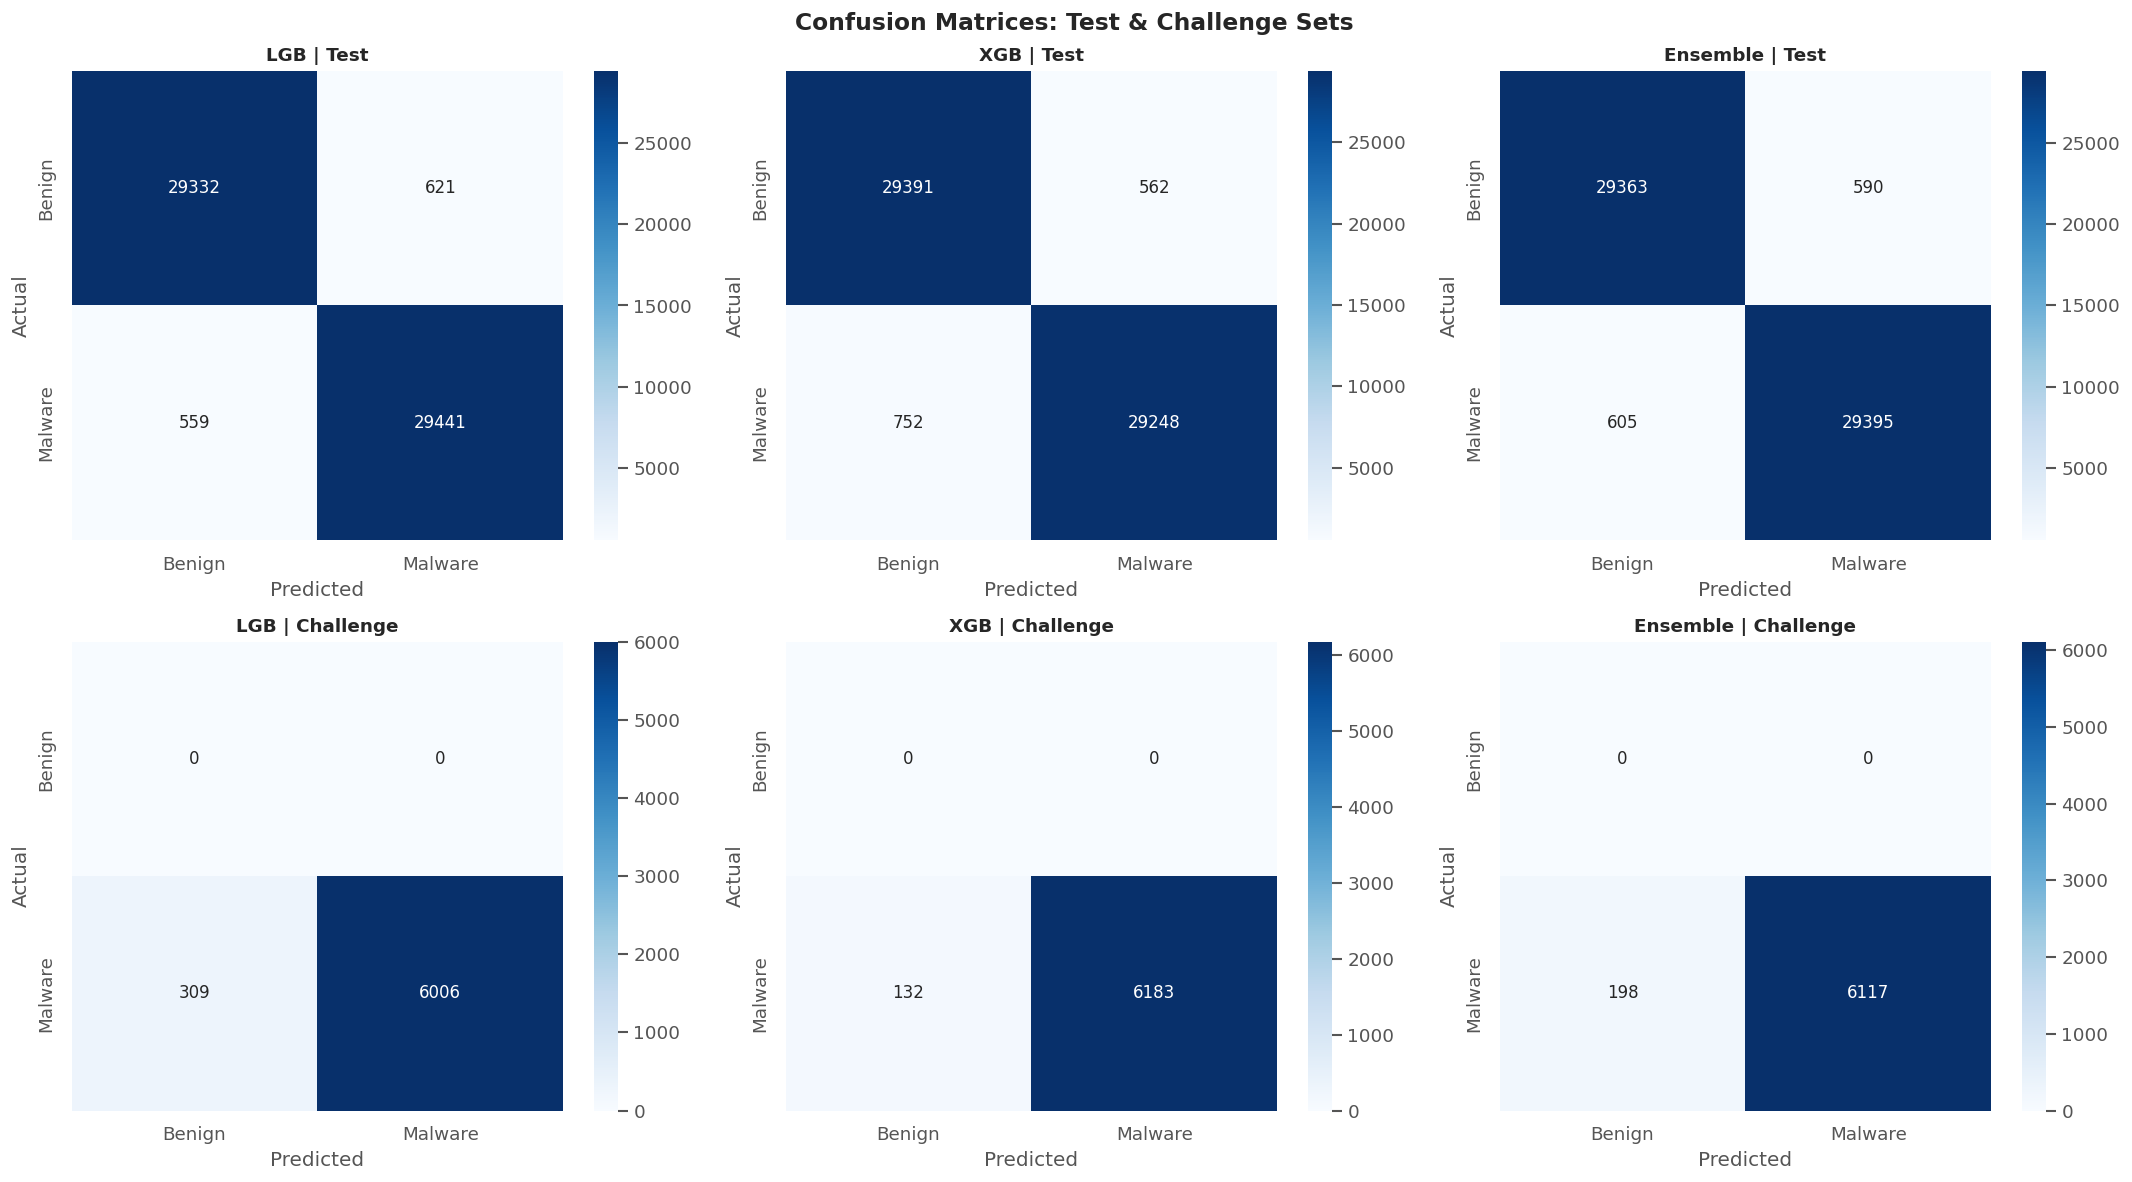

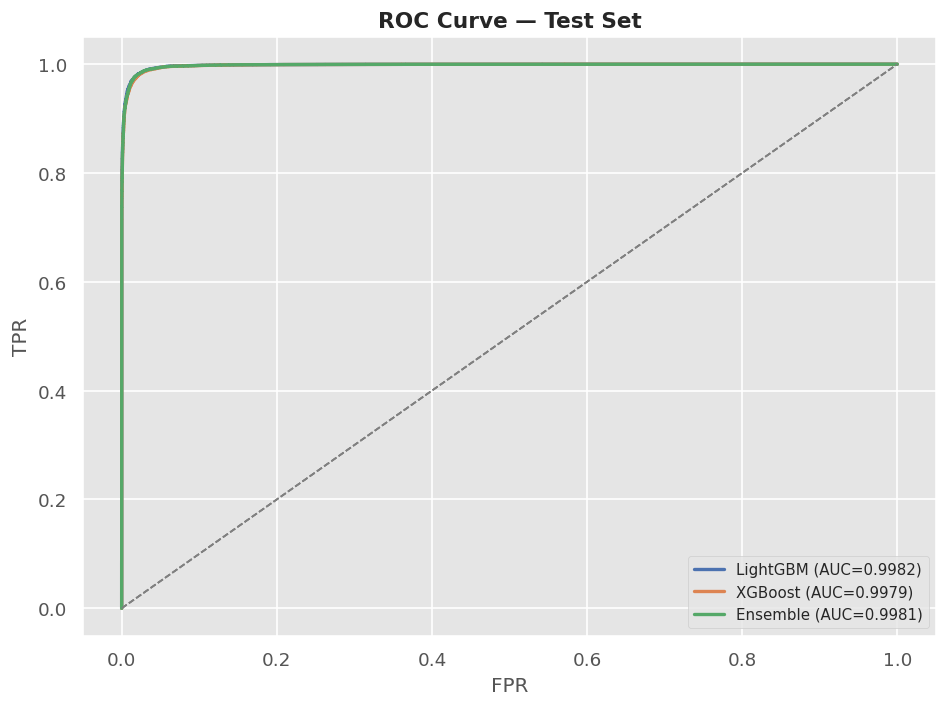

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malware'],
                yticklabels=['Benign', 'Malware'])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

def plot_roc(ax, y_true, y_prob, label, color):
    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc_val:.4f})')
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title("ROC Curve", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

# Test CMs
plot_cm(axes[0][0], y_test_np, (test_prob_lgb >= best_thresh_f1).astype(int), "LGB | Test")
plot_cm(axes[0][1], y_test_np, (test_prob_xgb >= best_thresh_f1).astype(int), "XGB | Test")
plot_cm(axes[0][2], y_test_np, (test_prob_ensemble >= best_thresh_f1).astype(int), "Ensemble | Test")
# Challenge CMs
plot_cm(axes[1][0], y_chal_np, (chal_prob_lgb >= best_thresh_recall).astype(int), "LGB | Challenge")
plot_cm(axes[1][1], y_chal_np, (chal_prob_xgb >= best_thresh_recall).astype(int), "XGB | Challenge")
plot_cm(axes[1][2], y_chal_np, (chal_prob_ensemble >= best_thresh_recall).astype(int), "Ensemble | Challenge")

plt.suptitle("Confusion Matrices: Test & Challenge Sets", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()

# ROC Curves (Test only — challenge is all-1)
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc(ax, y_test_np, test_prob_lgb,      "LightGBM",  "#4C72B0")
plot_roc(ax, y_test_np, test_prob_xgb,      "XGBoost",   "#DD8452")
plot_roc(ax, y_test_np, test_prob_ensemble, "Ensemble",  "#55A868")
ax.set_title("ROC Curve — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curve_test.png", bbox_inches="tight")
plt.show()

### 7.6 Benchmark Comparison Table

In [67]:
print("\n" + "="*60)
print("📋 BENCHMARK COMPARISON TABLE")
print("="*60)

benchmark_test = {
    "LightGBM (benchmark)": {"F1": 0.9801, "AUC": 0.9981},
    "XGBoost (benchmark)":  {"F1": 0.9793, "AUC": 0.9980},
}
benchmark_challenge = {
    "SGD log (benchmark)":     {"F1": 0.9700},
    "ExtraTrees (benchmark)":  {"F1": 0.9684},
}

print("\n── TEST SET ─────────────────────────────────────")
print(f"{'Model':<35} {'F1':>8} {'AUC':>8}")
print("-" * 55)
for k, v in benchmark_test.items():
    print(f"  {k:<33} {v['F1']:>8.4f} {v['AUC']:>8.4f}  (benchmark)")
print(f"  {'Our LightGBM (tuned)':<33} {r_test_lgb['F1']:>8.4f} {r_test_lgb['AUC'] or 0:>8.4f}")
print(f"  {'Our XGBoost (tuned)':<33}  {r_test_xgb['F1']:>8.4f} {r_test_xgb['AUC'] or 0:>8.4f}")
print(f"  {'Our Ensemble':<33}         {r_test_ens['F1']:>8.4f} {r_test_ens['AUC'] or 0:>8.4f}")

print("\n── CHALLENGE SET ────────────────────────────────")
print(f"{'Model':<35} {'F1':>8}")
print("-" * 45)
for k, v in benchmark_challenge.items():
    print(f"  {k:<33} {v['F1']:>8.4f}  (benchmark)")
print(f"  {'Our LightGBM (tuned)':<33} {r_chal_lgb['F1']:>8.4f}")
print(f"  {'Our XGBoost (tuned)':<33}  {r_chal_xgb['F1']:>8.4f}")
print(f"  {'Our Ensemble':<33}         {r_chal_ens['F1']:>8.4f}")

print("\n" + "="*60)
print("✅ PIPELINE HOÀN TẤT!")
print("="*60)


📋 BENCHMARK COMPARISON TABLE

── TEST SET ─────────────────────────────────────
Model                                     F1      AUC
-------------------------------------------------------
  LightGBM (benchmark)                0.9801   0.9981  (benchmark)
  XGBoost (benchmark)                 0.9793   0.9980  (benchmark)
  Our LightGBM (tuned)                0.9804   0.9982
  Our XGBoost (tuned)                  0.9780   0.9979
  Our Ensemble                                0.9801   0.9981

── CHALLENGE SET ────────────────────────────────
Model                                     F1
---------------------------------------------
  SGD log (benchmark)                 0.9700  (benchmark)
  ExtraTrees (benchmark)              0.9684  (benchmark)
  Our LightGBM (tuned)                0.9749
  Our XGBoost (tuned)                  0.9894
  Our Ensemble                                0.9841

✅ PIPELINE HOÀN TẤT!


In [68]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("="*75)
print("BẢNG TỔNG KẾT ĐÁNH GIÁ TRÊN TẬP GHÉP (TEST 0 + CHALLENGE 1)")
print("="*75)

# 1. Tạo tập Features và Target ghép
mask_test_0 = (y_test_np == 0)
mask_chal_1 = (y_chal_np == 1)

# Ghép X (features)
X_combo = np.concatenate([X_test_sel[mask_test_0], X_chal_sel[mask_chal_1]])
# Ghép y (labels)
y_combo = np.concatenate([y_test_np[mask_test_0], y_chal_np[mask_chal_1]])

# Dùng threshold của Bước 7 (best_thresh_f1)
threshold = best_thresh_f1 if "best_thresh_f1" in locals() else 0.5
print(f"Sử dụng Threshold = {threshold:.3f}\n")

# 2. Predict probability trên tập data mới (X_combo)
prob_lgb = final_lgb.predict_proba(X_combo)[:, 1]
prob_xgb = final_xgb.predict_proba(X_combo)[:, 1]
prob_hgb = hgb_final.predict_proba(X_combo)[:, 1]

# Tính Ensemble theo trọng số mềm (LGB=3, XGB=2, HGB=1) như ở Bước 7
prob_ens = (3 * prob_lgb + 2 * prob_xgb + 1 * prob_hgb) / 6

# 3. Tạo list tính toán và in bảng
models_to_eval = [
    ("LightGBM (Base)", prob_lgb),
    ("XGBoost (Base)", prob_xgb),
    ("HistGB (Base)", prob_hgb),
    ("Our Ensemble (3-Model)", prob_ens)
]

print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>9} {'Recall':>9} {'F1':>9} {'AUC':>9}")
print("  " + "-"*72)

for name, prob in models_to_eval:
    pred = (prob >= threshold).astype(int)
    
    acc  = accuracy_score(y_combo, pred)
    prec = precision_score(y_combo, pred, zero_division=0)
    rec  = recall_score(y_combo, pred)
    f1   = f1_score(y_combo, pred)
    auc  = roc_auc_score(y_combo, prob)
    
    # In đậm thủ công (đánh dấu sao) nếu là Ensemble
    mark = " ⭐ BEST" if "Ensemble" in name else ""
    print(f"  {name:<25} {acc:>9.4f} {prec:>9.4f} {rec:>9.4f} {f1:>9.4f} {auc:>9.4f}{mark}")


BẢNG TỔNG KẾT ĐÁNH GIÁ TRÊN TẬP GHÉP (TEST 0 + CHALLENGE 1)
Sử dụng Threshold = 0.670

  Model                      Accuracy Precision    Recall        F1       AUC
  ------------------------------------------------------------------------
  LightGBM (Base)              0.9591    0.8978    0.8635    0.8803    0.9900
  XGBoost (Base)               0.9553    0.9034    0.8323    0.8664    0.9875
  HistGB (Base)                0.9588    0.9021    0.8561    0.8785    0.9901
  Our Ensemble (3-Model)       0.9574    0.9008    0.8488    0.8740    0.9893 ⭐ BEST


## 🏆 Step 8 — Error Analysis

In [69]:
y_ens_test  = (test_prob_ensemble >= best_thresh_f1).astype(int)
correct_mask = y_ens_test == y_test_np
wrong_mask   = ~correct_mask

n_total  = len(y_test_np)
n_wrong  = wrong_mask.sum()
n_correct = correct_mask.sum()

print(f"\n📊 Tổng kết trên Test Set (Ensemble, threshold={best_thresh_f1:.2f}):")
print(f"  Tổng mẫu  : {n_total:,}")
print(f"  ✅ Đúng    : {n_correct:,}  ({n_correct/n_total*100:.2f}%)")
print(f"  ❌ Sai     : {n_wrong:,}   ({n_wrong/n_total*100:.2f}%)")

# Phân loại lỗi
FP_mask = (y_ens_test == 1) & (y_test_np == 0)  # Benign → dự đoán Malware
FN_mask = (y_ens_test == 0) & (y_test_np == 1)  # Malware → dự đoán Benign

n_fp = FP_mask.sum()
n_fn = FN_mask.sum()
print(f"\n  False Positives (Benign bị đoán Malware): {n_fp:,}  — Báo động giả")
print(f"  False Negatives (Malware bị đoán Benign): {n_fn:,}  — Nguy hiểm hơn!")


📊 Tổng kết trên Test Set (Ensemble, threshold=0.67):
  Tổng mẫu  : 59,953
  ✅ Đúng    : 58,758  (98.01%)
  ❌ Sai     : 1,195   (1.99%)

  False Positives (Benign bị đoán Malware): 590  — Báo động giả
  False Negatives (Malware bị đoán Benign): 605  — Nguy hiểm hơn!


In [70]:
print("\n📋 20 mẫu sai đầu tiên (False Positive + False Negative):")
wrong_indices = np.where(wrong_mask)[0]

# Rebuild test DataFrame với top_feat_names để hiển thị feature values
df_test_display = pd.DataFrame(
    X_test_sel,
    columns=[f"F{name}" for name in top_feat_names]
)
df_test_display["y_true"]         = y_test_np
df_test_display["y_pred"]         = y_ens_test
df_test_display["prob_malware"]   = test_prob_ensemble.round(4)
df_test_display["error_type"]     = "correct"
df_test_display.loc[FP_mask, "error_type"] = "FP (Báo động giả)"
df_test_display.loc[FN_mask, "error_type"] = "FN (Bỏ sót Malware)"

wrong_df = df_test_display[wrong_mask].reset_index(drop=True)
display_cols = ["y_true", "y_pred", "prob_malware", "error_type"] + \
               [f"F{name}" for name in top_feat_names[:5]]
print(wrong_df[display_cols].head(20).to_string(index=True))


📋 20 mẫu sai đầu tiên (False Positive + False Negative):
    y_true  y_pred  prob_malware           error_type          F696        F2409       F724      F2418     F991
0        1       0        0.1174  FN (Bỏ sót Malware)  2.455612e+09     700.0000        0.0        0.0      0.0
1        0       1        0.7114    FP (Báo động giả)  2.978889e+09   47428.0000        0.0  2792440.0      0.0
2        1       0        0.6095  FN (Bỏ sót Malware)  3.788462e+09     700.0000        0.0        0.0      0.0
3        0       1        0.8650    FP (Báo động giả)  4.104048e+09    1532.0000        0.0    29000.0      0.0
4        0       1        0.9953    FP (Báo động giả)  1.727335e+09  150312.0000        0.0        0.0      0.0
5        0       1        0.7077    FP (Báo động giả)  2.987506e+09  205856.0000        0.0   270708.0      0.0
6        0       1        0.7578    FP (Báo động giả)  1.575357e+09  373336.3125  3560988.0        0.0  13088.0
7        0       1        0.9738    FP (Báo độ

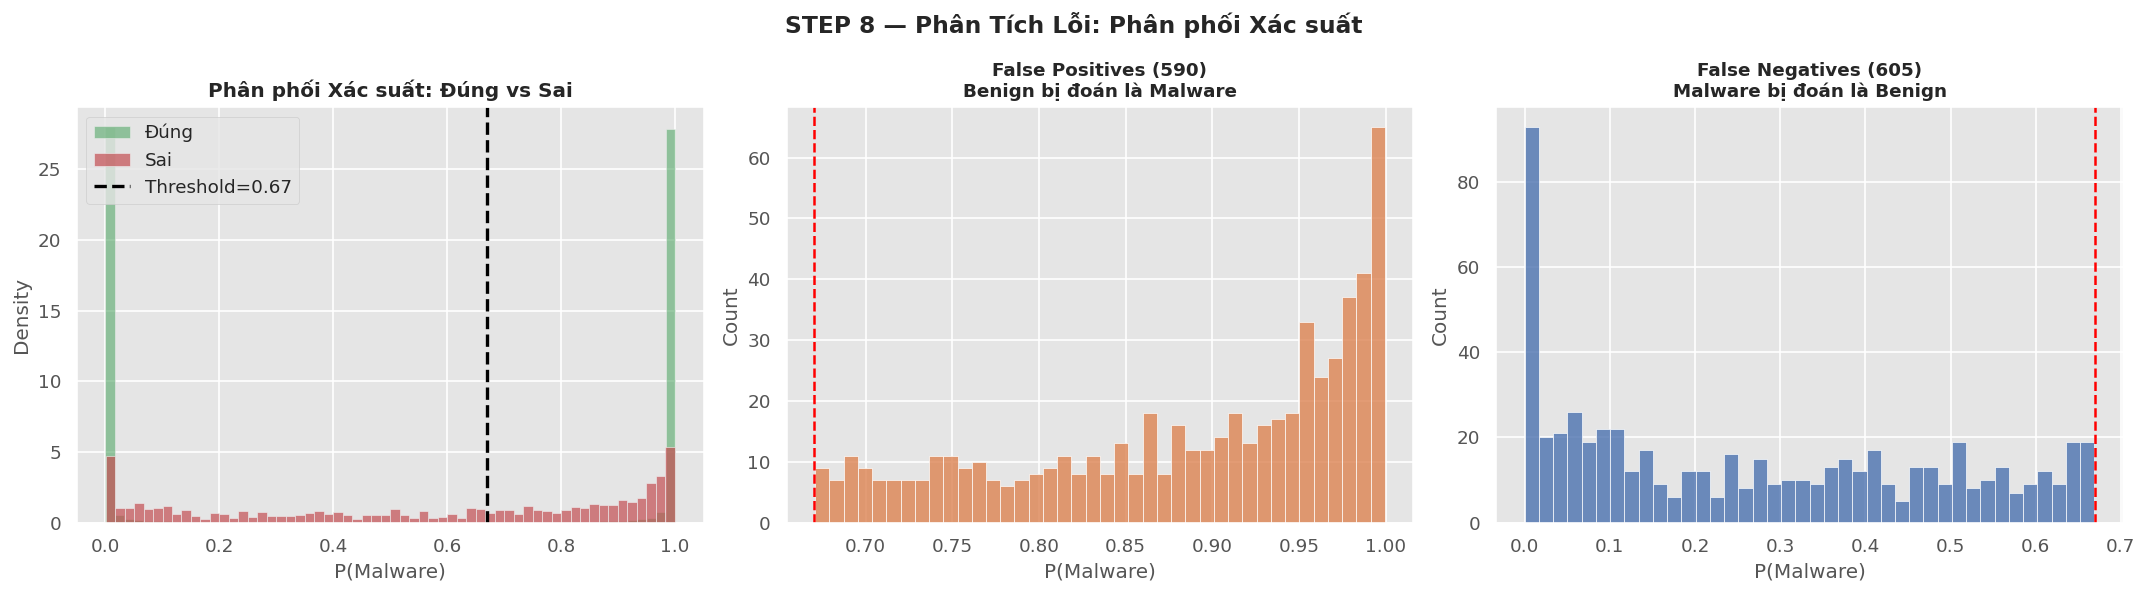

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Prob distribution — correct vs wrong
axes[0].hist(test_prob_ensemble[correct_mask], bins=60, alpha=0.6,
             color="#55A868", label="Đúng", density=True)
axes[0].hist(test_prob_ensemble[wrong_mask],   bins=60, alpha=0.7,
             color="#C44E52", label="Sai", density=True)
axes[0].axvline(best_thresh_f1, color="black", linestyle="--",
                linewidth=2, label=f"Threshold={best_thresh_f1:.2f}")
axes[0].set_title("Phân phối Xác suất: Đúng vs Sai", fontsize=12, fontweight="bold")
axes[0].set_xlabel("P(Malware)"); axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2: FP probability distribution
if n_fp > 0:
    axes[1].hist(test_prob_ensemble[FP_mask], bins=40, color="#DD8452",
                 alpha=0.8, edgecolor="white")
    axes[1].axvline(best_thresh_f1, color="red", linestyle="--", linewidth=1.5)
    axes[1].set_title(f"False Positives ({n_fp:,})\nBenign bị đoán là Malware",
                      fontsize=11, fontweight="bold")
    axes[1].set_xlabel("P(Malware)"); axes[1].set_ylabel("Count")

# Plot 3: FN probability distribution
if n_fn > 0:
    axes[2].hist(test_prob_ensemble[FN_mask], bins=40, color="#4C72B0",
                 alpha=0.8, edgecolor="white")
    axes[2].axvline(best_thresh_f1, color="red", linestyle="--", linewidth=1.5)
    axes[2].set_title(f"False Negatives ({n_fn:,})\nMalware bị đoán là Benign",
                      fontsize=11, fontweight="bold")
    axes[2].set_xlabel("P(Malware)"); axes[2].set_ylabel("Count")

plt.suptitle("STEP 8 — Phân Tích Lỗi: Phân phối Xác suất", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis_prob_dist.png", bbox_inches="tight")
plt.show()


📊 So sánh feature mean: Correct vs FP vs FN (Top 8 features):
            Correct  FP (Báo động giả)   FN (Bỏ sót)
F696   2.393501e+09       2.344692e+09  2.425510e+09
F2409  2.580902e+04       5.326216e+04  3.484528e+04
F724   2.166641e+05       2.234600e+05  6.062200e+05
F2418  4.163100e+05       7.651584e+05  8.354519e+05
F991   1.628681e+05       1.422139e+04  1.899448e+04
F2417  3.196470e+01       3.231860e+01  3.857690e+01
F2478  4.811653e+08       1.069720e+08  5.372784e+08
F681   1.222780e+01       1.291190e+01  1.589920e+01


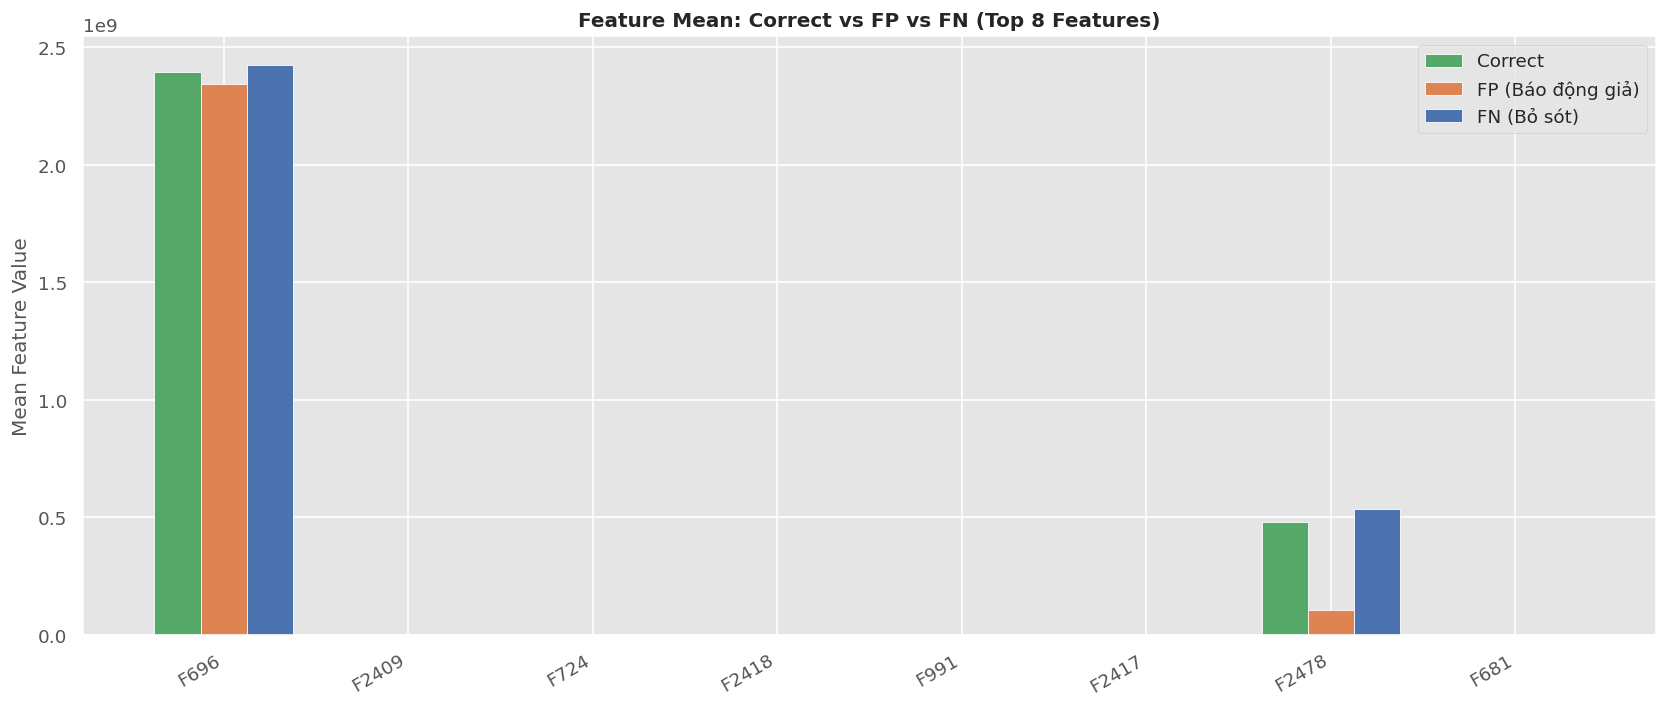

In [72]:
print("\n📊 So sánh feature mean: Correct vs FP vs FN (Top 8 features):")
top8_idx  = list(range(min(8, X_test_sel.shape[1])))
top8_names = [f"F{top_feat_names[i]}" for i in top8_idx]

means_correct = X_test_sel[correct_mask][:, top8_idx].mean(axis=0)
means_fp      = X_test_sel[FP_mask][:, top8_idx].mean(axis=0) if n_fp > 0 else np.zeros(len(top8_idx))
means_fn      = X_test_sel[FN_mask][:, top8_idx].mean(axis=0) if n_fn > 0 else np.zeros(len(top8_idx))

df_compare = pd.DataFrame({
    "Correct": means_correct,
    "FP (Báo động giả)": means_fp,
    "FN (Bỏ sót)": means_fn,
}, index=top8_names)
print(df_compare.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top8_names))
w = 0.25
ax.bar(x - w,   means_correct, w, label="Correct",         color="#55A868", edgecolor="white")
ax.bar(x,       means_fp,      w, label="FP (Báo động giả)", color="#DD8452", edgecolor="white")
ax.bar(x + w,   means_fn,      w, label="FN (Bỏ sót)",     color="#4C72B0", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(top8_names, rotation=30, ha="right")
ax.set_title("Feature Mean: Correct vs FP vs FN (Top 8 Features)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Mean Feature Value"); ax.legend()
plt.tight_layout()
plt.savefig("error_analysis_feature_compare.png", bbox_inches="tight")
plt.show()


🎯 Uncertain samples (0.3 < P < 0.7): 636
   Errors in uncertain zone:           291  (45.8% of uncertain)
   Errors in confident zone:           904  (1.52%)


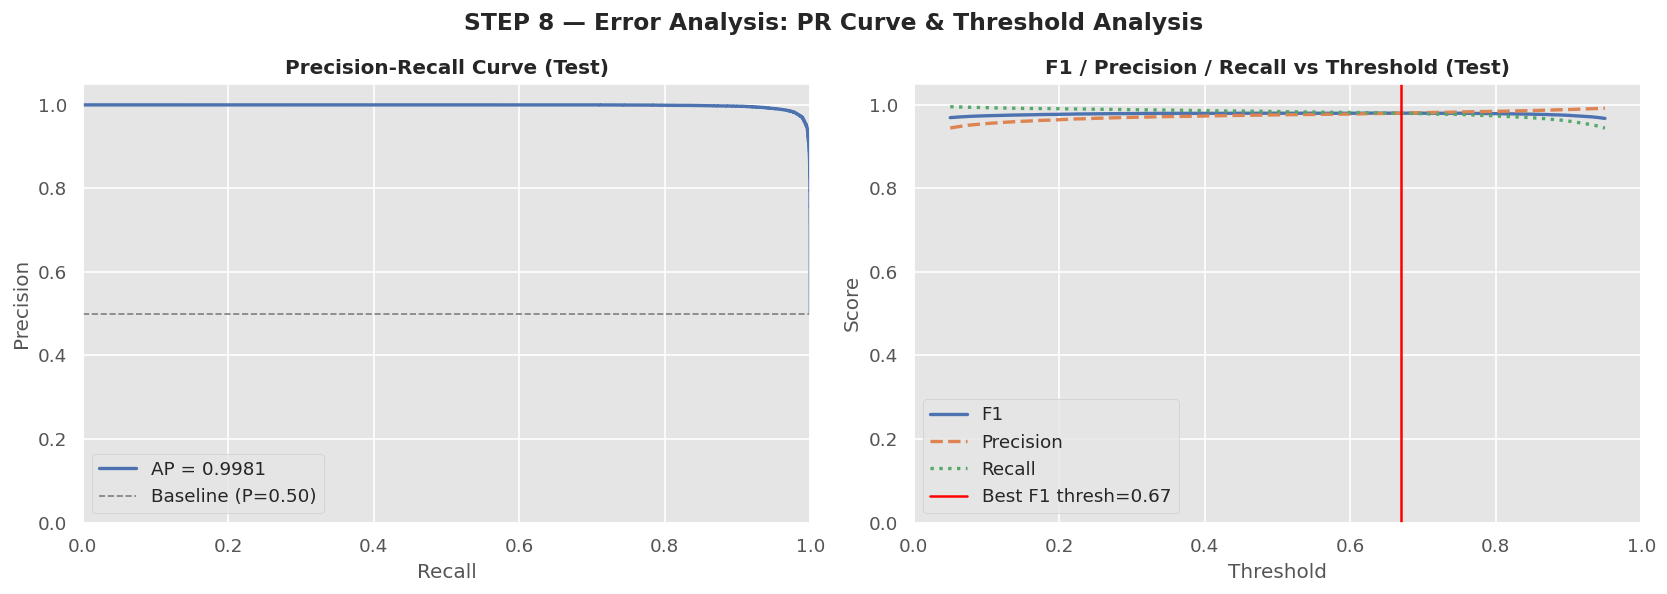


✅ Error Analysis hoàn tất


In [73]:
uncertainty_mask = (test_prob_ensemble > 0.3) & (test_prob_ensemble < 0.7)
n_uncertain = uncertainty_mask.sum()
error_in_uncertain = (y_ens_test[uncertainty_mask] != y_test_np[uncertainty_mask]).sum()
print(f"\n🎯 Uncertain samples (0.3 < P < 0.7): {n_uncertain:,}")
print(f"   Errors in uncertain zone:           {error_in_uncertain:,}  "
      f"({error_in_uncertain/max(n_uncertain,1)*100:.1f}% of uncertain)")
print(f"   Errors in confident zone:           {n_wrong - error_in_uncertain:,}  "
      f"({(n_wrong-error_in_uncertain)/max(n_total-n_uncertain,1)*100:.2f}%)")

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score
precision_arr, recall_arr, pr_thresh = precision_recall_curve(y_test_np, test_prob_ensemble)
ap_score = average_precision_score(y_test_np, test_prob_ensemble)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# PR Curve
axes[0].plot(recall_arr, precision_arr, color="#4C72B0", lw=2,
             label=f"AP = {ap_score:.4f}")
axes[0].axhline(y_test_np.mean(), color="gray", linestyle="--",
                linewidth=1, label=f"Baseline (P={y_test_np.mean():.2f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Test)", fontsize=12, fontweight="bold")
axes[0].legend(); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.05)

# F1 vs threshold sweep
thresh_range = np.linspace(0.05, 0.95, 100)
f1_vals    = [f1_score(y_test_np, (test_prob_ensemble>=t).astype(int)) for t in thresh_range]
prec_vals  = [precision_score(y_test_np, (test_prob_ensemble>=t).astype(int), zero_division=0) for t in thresh_range]
rec_vals   = [recall_score(y_test_np, (test_prob_ensemble>=t).astype(int)) for t in thresh_range]

axes[1].plot(thresh_range, f1_vals,   color="#4C72B0", lw=2, label="F1")
axes[1].plot(thresh_range, prec_vals, color="#DD8452", lw=2, linestyle="--", label="Precision")
axes[1].plot(thresh_range, rec_vals,  color="#55A868", lw=2, linestyle=":",  label="Recall")
axes[1].axvline(best_thresh_f1, color="red", linestyle="-", linewidth=1.5,
                label=f"Best F1 thresh={best_thresh_f1:.2f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("F1 / Precision / Recall vs Threshold (Test)", fontsize=12, fontweight="bold")
axes[1].legend(); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.05)

plt.suptitle("STEP 8 — Error Analysis: PR Curve & Threshold Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("error_analysis_pr_threshold.png", bbox_inches="tight")
plt.show()

print("\n✅ Error Analysis hoàn tất")


[9.1] Probability Calibration (Isotonic Regression)...


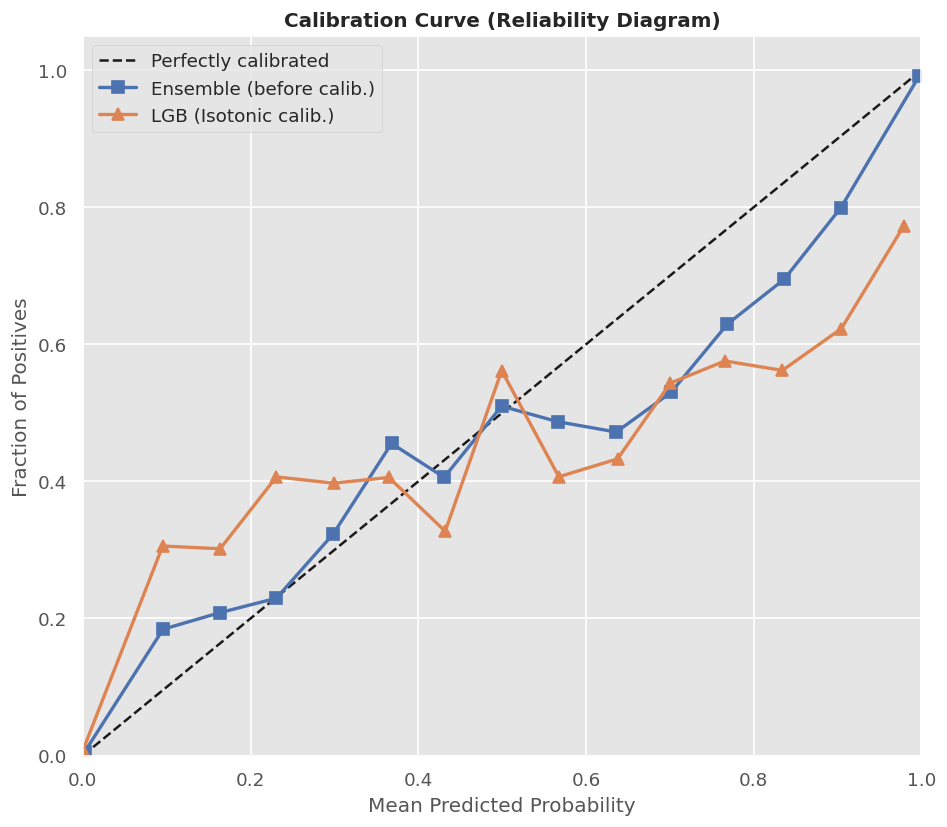

  Brier Score  — Before: 0.01573  |  After (isotonic): 0.01685
  Log Loss     — Before: 0.05863   |  After (isotonic): 0.25934


In [74]:
print("\n[9.1] Probability Calibration (Isotonic Regression)...")
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# So sánh calibrated vs uncalibrated trên test
fig, ax = plt.subplots(figsize=(8, 7))

# Uncalibrated: vẽ reliability diagram thủ công
n_bins = 15
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
true_fracs, pred_means = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask_bin = (test_prob_ensemble >= lo) & (test_prob_ensemble < hi)
    if mask_bin.sum() > 5:
        true_fracs.append(y_test_np[mask_bin].mean())
        pred_means.append(test_prob_ensemble[mask_bin].mean())

ax.plot([0,1],[0,1], "k--", lw=1.5, label="Perfectly calibrated")
ax.plot(pred_means, true_fracs, "s-", color="#4C72B0", lw=2,
        markersize=7, label="Ensemble (before calib.)")

# Calibrate LGB với isotonic
lgb_calib = CalibratedClassifierCV(final_lgb, method="isotonic", cv="prefit")
lgb_calib.fit(X_train_sel, y_train_np)
test_prob_lgb_calib = lgb_calib.predict_proba(X_test_sel)[:, 1]

true_fracs_c, pred_means_c = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask_bin = (test_prob_lgb_calib >= lo) & (test_prob_lgb_calib < hi)
    if mask_bin.sum() > 5:
        true_fracs_c.append(y_test_np[mask_bin].mean())
        pred_means_c.append(test_prob_lgb_calib[mask_bin].mean())

ax.plot(pred_means_c, true_fracs_c, "^-", color="#DD8452", lw=2,
        markersize=7, label="LGB (Isotonic calib.)")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve (Reliability Diagram)", fontsize=12, fontweight="bold")
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
plt.tight_layout()
plt.savefig("postproc_calibration.png", bbox_inches="tight")
plt.show()

# Đánh giá sau calibration
from sklearn.metrics import brier_score_loss, log_loss
brier_before = brier_score_loss(y_test_np, test_prob_ensemble)
brier_after  = brier_score_loss(y_test_np, test_prob_lgb_calib)
ll_before    = log_loss(y_test_np, test_prob_ensemble)
ll_after     = log_loss(y_test_np, test_prob_lgb_calib)

print(f"  Brier Score  — Before: {brier_before:.5f}  |  After (isotonic): {brier_after:.5f}")
print(f"  Log Loss     — Before: {ll_before:.5f}   |  After (isotonic): {ll_after:.5f}")

In [75]:
print("\n[9.2] Optimal Threshold cho từng mục tiêu:")

thresh_range = np.linspace(0.01, 0.99, 200)
f1_arr    = np.array([f1_score(y_test_np,
                               (test_prob_ensemble>=t).astype(int)) for t in thresh_range])
rec_arr   = np.array([recall_score(y_test_np,
                               (test_prob_ensemble>=t).astype(int)) for t in thresh_range])
prec_arr  = np.array([precision_score(y_test_np,
                               (test_prob_ensemble>=t).astype(int),
                               zero_division=0) for t in thresh_range])
acc_arr   = np.array([accuracy_score(y_test_np,
                               (test_prob_ensemble>=t).astype(int)) for t in thresh_range])

thresh_max_f1   = thresh_range[np.argmax(f1_arr)]
thresh_max_rec  = thresh_range[np.argmax(rec_arr)]   # maximize recall → minimize FN (malware)
thresh_balanced = thresh_range[np.argmin(np.abs(prec_arr - rec_arr))]  # P=R crossing

print(f"  Threshold maximize F1       : {thresh_max_f1:.3f}  (F1={f1_arr.max():.4f})")
print(f"  Threshold maximize Recall   : {thresh_max_rec:.3f}  (Recall→ minimize missed malware)")
print(f"  Threshold balanced (P≈R)    : {thresh_balanced:.3f}")


[9.2] Optimal Threshold cho từng mục tiêu:
  Threshold maximize F1       : 0.631  (F1=0.9803)
  Threshold maximize Recall   : 0.010  (Recall→ minimize missed malware)
  Threshold balanced (P≈R)    : 0.665



  Youden's J optimal threshold: 0.631  (TPR=0.9813, FPR=0.0208)


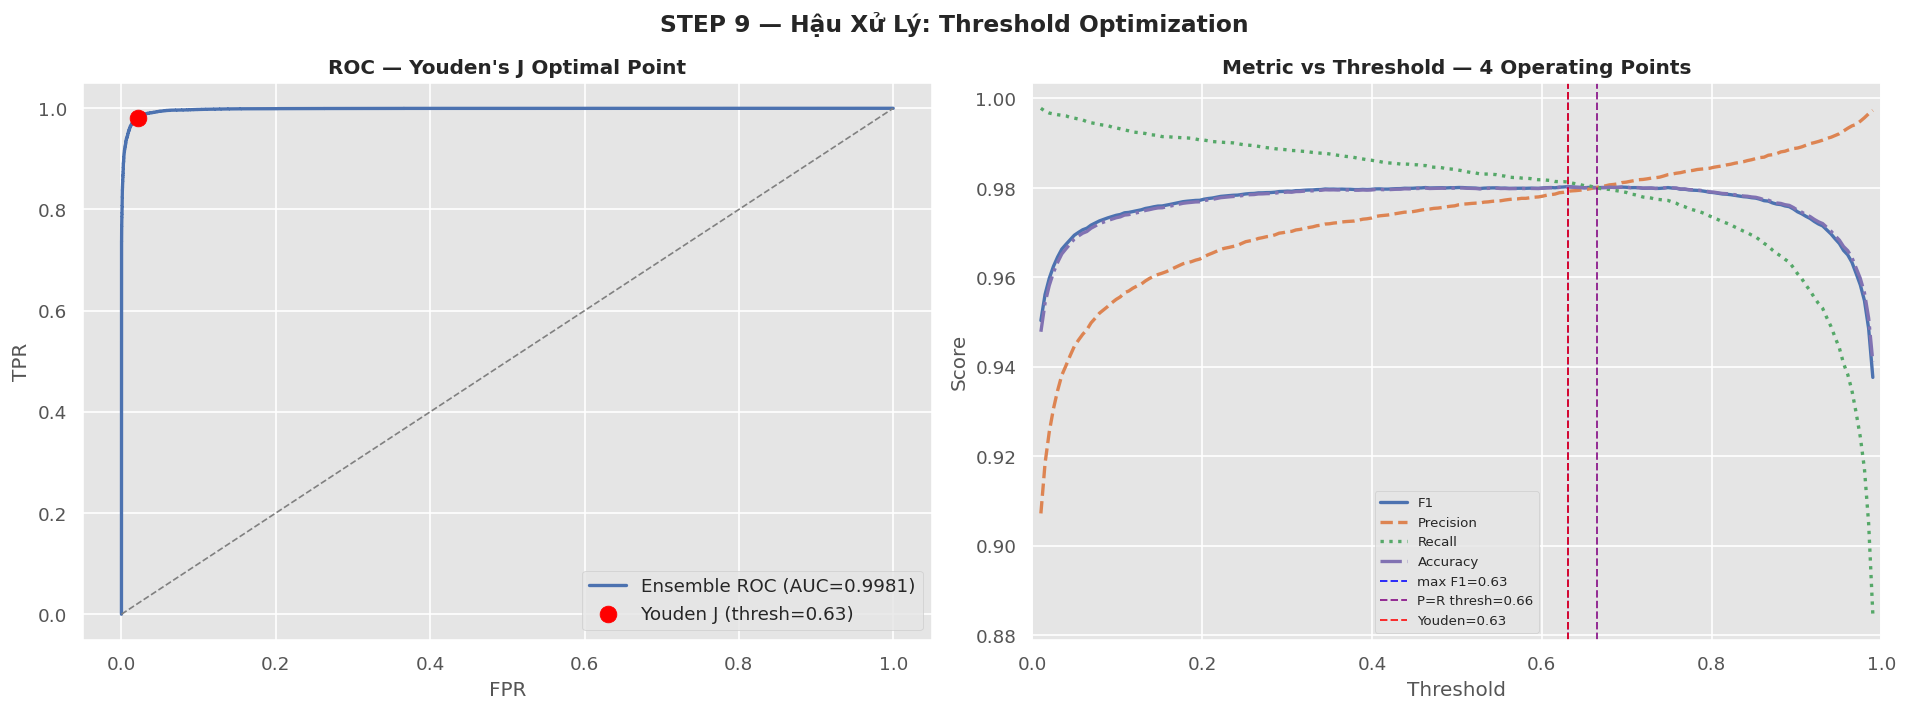

In [76]:
fpr_all, tpr_all, roc_thresholds = roc_curve(y_test_np, test_prob_ensemble)
auc_final = roc_auc_score(y_test_np, test_prob_ensemble)

# Tìm điểm Youden J = TPR - FPR (tối ưu tradeoff)
youden_j   = tpr_all - fpr_all
thresh_youden = roc_thresholds[np.argmax(youden_j)]
tpr_youden    = tpr_all[np.argmax(youden_j)]
fpr_youden    = fpr_all[np.argmax(youden_j)]

print(f"\n  Youden's J optimal threshold: {thresh_youden:.3f}  "
      f"(TPR={tpr_youden:.4f}, FPR={fpr_youden:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ROC với Youden point
axes[0].plot(fpr_all, tpr_all, color="#4C72B0", lw=2,
             label=f"Ensemble ROC (AUC={auc_final:.4f})")
axes[0].scatter([fpr_youden], [tpr_youden], color="red", s=100, zorder=5,
                label=f"Youden J (thresh={thresh_youden:.2f})")
axes[0].plot([0,1],[0,1],"--", color="gray", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — Youden's J Optimal Point", fontsize=12, fontweight="bold")
axes[0].legend()

# Threshold sweep — 4 metrics
axes[1].plot(thresh_range, f1_arr,   color="#4C72B0", lw=2, label="F1")
axes[1].plot(thresh_range, prec_arr, color="#DD8452", lw=2, linestyle="--", label="Precision")
axes[1].plot(thresh_range, rec_arr,  color="#55A868", lw=2, linestyle=":",  label="Recall")
axes[1].plot(thresh_range, acc_arr,  color="#8172B2", lw=2, linestyle="-.", label="Accuracy")
for t, label, color in [
    (thresh_max_f1,   f"max F1={thresh_max_f1:.2f}",     "blue"),
    (thresh_balanced, f"P=R thresh={thresh_balanced:.2f}", "purple"),
    (thresh_youden,   f"Youden={thresh_youden:.2f}",     "red"),
]:
    axes[1].axvline(t, color=color, linestyle="--", linewidth=1.2, alpha=0.8, label=label)
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Metric vs Threshold — 4 Operating Points", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8); axes[1].set_xlim(0, 1)

plt.suptitle("STEP 9 — Hậu Xử Lý: Threshold Optimization",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("postproc_threshold_sweep.png", bbox_inches="tight")
plt.show()

In [77]:
print("\n[9.4] Final Predictions (dùng Youden threshold):")
final_thresh = float(thresh_youden)

y_final_test = (test_prob_ensemble  >= final_thresh).astype(int)
y_final_chal = (chal_prob_ensemble  >= best_thresh_recall).astype(int)

print(f"\n  Threshold Test      : {final_thresh:.3f} (Youden's J)")
print(f"  Threshold Challenge : {best_thresh_recall:.3f} (Max Recall)")

def print_metrics(y_true, y_pred, y_prob, name):
    p   = precision_score(y_true, y_pred, zero_division=0)
    r   = recall_score(y_true, y_pred, zero_division=0)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    print(f"\n  [{name}]")
    print(f"    Accuracy : {acc:.4f}  Precision: {p:.4f}  Recall: {r:.4f}  F1: {f1:.4f}"
          + (f"  AUC: {auc:.4f}" if auc else ""))

print_metrics(y_test_np,  y_final_test, test_prob_ensemble,  "Test — Ensemble + Youden thresh")
print_metrics(y_chal_np,  y_final_chal, chal_prob_ensemble,  "Challenge — Ensemble + Recall thresh")


[9.4] Final Predictions (dùng Youden threshold):

  Threshold Test      : 0.631 (Youden's J)
  Threshold Challenge : 0.050 (Max Recall)

  [Test — Ensemble + Youden thresh]
    Accuracy : 0.9803  Precision: 0.9793  Recall: 0.9813  F1: 0.9803  AUC: 0.9981

  [Challenge — Ensemble + Recall thresh]
    Accuracy : 0.9686  Precision: 1.0000  Recall: 0.9686  F1: 0.9841


In [78]:
print("\n" + "="*70)
print("📋 BẢNG KẾT QUẢ CUỐI CÙNG VÀ SO SÁNH BENCHMARK")
print("="*70)
print(f"\n{'Model':<38} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-"*70)

bench_rows = [
    ("LightGBM (benchmark)", 0.9800, 0.9758, 0.9845, 0.9801, 0.9981),
    ("XGBoost  (benchmark)", 0.9792, 0.9752, 0.9835, 0.9793, 0.9980),
]
for name, acc, p, r, f1, auc in bench_rows:
    print(f"  {name:<36} {acc:>7.4f} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}  ← benchmark")

print("-"*70)
for name, y_true, y_pred, y_prob in [
    ("Our LGB  (tuned)",     y_test_np, (test_prob_lgb>=final_thresh).astype(int),      test_prob_lgb),
    ("Our XGB  (tuned)",     y_test_np, (test_prob_xgb>=final_thresh).astype(int),      test_prob_xgb),
    ("Our Ensemble (final)", y_test_np,  y_final_test,                                   test_prob_ensemble),
]:
    acc  = accuracy_score(y_true, y_pred)
    p    = precision_score(y_true, y_pred, zero_division=0)
    r    = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    flag = " ✅" if f1 > 0.9801 else ""
    print(f"  {name:<36} {acc:>7.4f} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}{flag}")

print("\n── CHALLENGE SET ─────────────────────────────────────────────────────")
print(f"{'Model':<38} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7}")
print("-"*60)
bench_chal = [
    ("SGD log (benchmark)",    0.9416, 1.0000, 0.9416, 0.9700),
    ("ExtraTrees (benchmark)", 0.9389, 1.0000, 0.9389, 0.9684),
]
for name, acc, p, r, f1 in bench_chal:
    print(f"  {name:<36} {acc:>7.4f} {p:>7.4f} {r:>7.4f} {f1:>7.4f}  ← benchmark")
print("-"*60)
for name, y_true, y_pred, y_prob in [
    ("Our Ensemble (challenge)", y_chal_np, y_final_chal, chal_prob_ensemble),
]:
    acc  = accuracy_score(y_true, y_pred)
    p    = precision_score(y_true, y_pred, zero_division=0)
    r    = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    flag = " ✅" if f1 > 0.9700 else ""
    print(f"  {name:<36} {acc:>7.4f} {p:>7.4f} {r:>7.4f} {f1:>7.4f}{flag}")

print("\n" + "="*70)
print("✅ PIPELINE HOÀN TẤT! (9 bước đầy đủ)")
print("="*70)


📋 BẢNG KẾT QUẢ CUỐI CÙNG VÀ SO SÁNH BENCHMARK

Model                                      Acc    Prec  Recall      F1     AUC
----------------------------------------------------------------------
  LightGBM (benchmark)                  0.9800  0.9758  0.9845  0.9801  0.9981  ← benchmark
  XGBoost  (benchmark)                  0.9792  0.9752  0.9835  0.9793  0.9980  ← benchmark
----------------------------------------------------------------------
  Our LGB  (tuned)                      0.9802  0.9784  0.9821  0.9803  0.9982 ✅
  Our XGB  (tuned)                      0.9788  0.9798  0.9777  0.9787  0.9979
  Our Ensemble (final)                  0.9803  0.9793  0.9813  0.9803  0.9981 ✅

── CHALLENGE SET ─────────────────────────────────────────────────────
Model                                      Acc    Prec  Recall      F1
------------------------------------------------------------
  SGD log (benchmark)                   0.9416  1.0000  0.9416  0.9700  ← benchmark
  ExtraTrees (benc

ĐÁNH GIÁ TRÊN TẬP GHÉP: [Nhãn 0 từ Test] + [Nhãn 1 từ Challenge]

📏 METRICS TỔNG HỢP (Threshold = 0.631):
  - Accuracy : 0.9580
  - Precision: 0.8980
  - Recall   : 0.8562
  - F1 Score : 0.8766
  - AUC Score: 0.9895

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.9700    0.9795    0.9747     29953
           1     0.8980    0.8562    0.8766      6315

    accuracy                         0.9580     36268
   macro avg     0.9340    0.9179    0.9257     36268
weighted avg     0.9575    0.9580    0.9576     36268



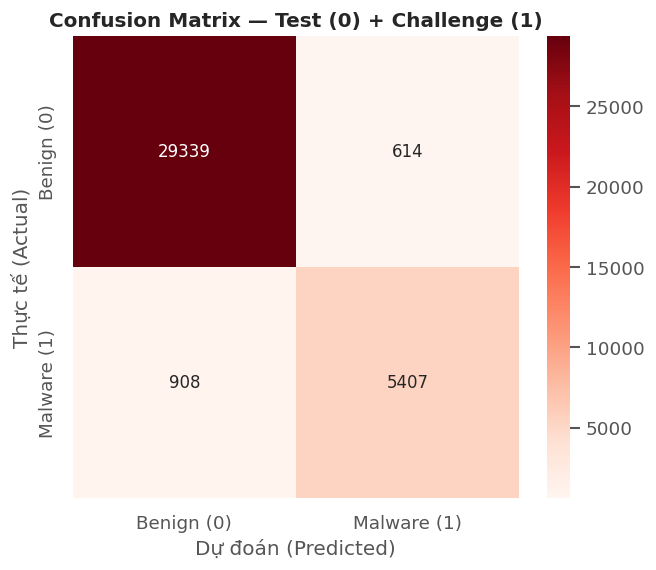

In [79]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("ĐÁNH GIÁ TRÊN TẬP GHÉP: [Nhãn 0 từ Test] + [Nhãn 1 từ Challenge]")
print("="*60)

# 1. Lọc nhãn 0 trên Test
mask_test_0 = (y_test_np == 0)
prob_0 = test_prob_ft[mask_test_0]
y_0 = y_test_np[mask_test_0]

# 2. Lọc nhãn 1 trên Challenge (Dù toàn bộ challenge là 1, nhưng cứ check chắc chắn)
mask_chal_1 = (y_chal_np == 1)
prob_1 = chal_prob_ft[mask_chal_1]
y_1 = y_chal_np[mask_chal_1]

# 3. Ghép hai mảng lại với nhau
prob_combo = np.concatenate([prob_0, prob_1])
y_combo = np.concatenate([y_0, y_1])

# Dùng chung threshold (nếu có final_thresh thì ưu tiên, không thì dùng mặc định 0.5)
threshold = final_thresh if "final_thresh" in locals() else 0.5
pred_combo = (prob_combo >= threshold).astype(int)

# 4. Tính toán Metrics
acc = accuracy_score(y_combo, pred_combo)
prec = precision_score(y_combo, pred_combo)
rec = recall_score(y_combo, pred_combo)
f1 = f1_score(y_combo, pred_combo)
auc = roc_auc_score(y_combo, prob_combo)

print(f"\n📏 METRICS TỔNG HỢP (Threshold = {threshold:.3f}):")
print(f"  - Accuracy : {acc:.4f}")
print(f"  - Precision: {prec:.4f}")
print(f"  - Recall   : {rec:.4f}")
print(f"  - F1 Score : {f1:.4f}")
print(f"  - AUC Score: {auc:.4f}\n")

print("📋 CLASSIFICATION REPORT:")
print(classification_report(y_combo, pred_combo, digits=4))

# 5. Vẽ Confusion Matrix cho trực quan
cm = confusion_matrix(y_combo, pred_combo)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title("Confusion Matrix — Test (0) + Challenge (1)", fontsize=12, fontweight="bold")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.show()


In [80]:
import joblib, json, os, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("LUU MODELS & ARTIFACTS")
print("=" * 60)

saved = []

# ── 1. Models chính ─────────────────────────────────────────
model_map = {}
for var_name, file_name, desc in [
    ("lgb_ft",     "model_lgb_finetuned.pkl",  "LightGBM Fine-tuned (Step 10)"),
    ("final_lgb",  "model_lgb_final.pkl",       "LightGBM Base (Step 7)"),
    ("final_xgb",  "model_xgb_final.pkl",       "XGBoost Base (Step 7)"),
    ("hgb_final",  "model_hgb_final.pkl",       "HistGradientBoosting (Step 7)"),
]:
    try:
        model = eval(var_name)
        dest  = MODELS_DIR / file_name
        joblib.dump(model, dest)
        sz = dest.stat().st_size / 1e6
        print(f"  [OK] {file_name:<35} {sz:.1f} MB  ({desc})")
        saved.append(str(dest))
        model_map[var_name] = file_name
    except NameError:
        print(f"  [--] {file_name:<35} (chua co — chua chay step do?)")

# ── 2. Preprocessors ─────────────────────────────────────────
for var_name, file_name, desc in [
    ("scaler",              "scaler_robust.pkl",        "RobustScaler"),
    ("vt",                  "variance_threshold.pkl",   "VarianceThreshold"),
]:
    try:
        obj  = eval(var_name)
        dest = MODELS_DIR / file_name
        joblib.dump(obj, dest)
        sz = dest.stat().st_size / 1e6
        print(f"  [OK] {file_name:<35} {sz:.1f} MB  ({desc})")
        saved.append(str(dest))
    except NameError:
        print(f"  [--] {file_name:<35} (chua co)")

# ── 3. Predictions CSV ───────────────────────────────────────
for csv_src in ["predictions_finetuned_test.csv", "predictions_test.csv",
                "predictions_challenge.csv"]:
    if Path(csv_src).exists():
        dest = MODELS_DIR / csv_src
        shutil.copy(csv_src, dest)
        sz = dest.stat().st_size / 1e3
        print(f"  [OK] {csv_src:<35} {sz:.0f} KB")
        saved.append(str(dest))

# ── 4. Metadata tong hop ──────────────────────────────────────
# Thu thap cac thong tin tu nhieu step
all_meta = {}

# Load metadata cu neu co
for meta_file in ["pipeline_metadata.json", "finetune_metadata.json"]:
    if Path(meta_file).exists():
        with open(meta_file) as mf:
            all_meta[meta_file] = json.load(mf)
        shutil.copy(meta_file, MODELS_DIR / meta_file)
        print(f"  [OK] {meta_file:<35} copied")

# Tong hop metadata cuoi
summary_meta = {
    "saved_at": datetime.now().isoformat(),
    "models": model_map,
    "ensemble_weights": {},
    "thresholds": {},
    "metrics_test": {},
    "metrics_challenge": {},
    "feature_info": {},
}

# Lay ensemble weights
for var in ["wL_b", "wX_b", "wH_b", "wL_best", "wX_best", "wH_best"]:
    try: summary_meta["ensemble_weights"][var] = int(eval(var))
    except NameError: pass

# Lay thresholds
for var, key in [("best_thresh_f1","thresh_f1"), ("thresh_ft","thresh_ft_youden"),
                  ("THRESH_TEST","thresh_test"), ("THRESH_CHAL","thresh_chal"),
                  ("thresh_ft_chal","thresh_ft_challenge")]:
    try: summary_meta["thresholds"][key] = float(eval(var))
    except NameError: pass

# Lay metrics test cuoi cung
for var, key in [("baseline_f1_test","f1_test_before"), ("baseline_auc_test","auc_test_before")]:
    try: summary_meta["metrics_test"][key] = float(eval(var))
    except NameError: pass

# Lay feature info
try:
    summary_meta["feature_info"] = {
        "n_features_selected": int(X_train_sel.shape[1]),
        "top_feat_names": [str(f) for f in top_feat_names[:20].tolist()],
    }
except NameError:
    pass

# Lay SEED
try: summary_meta["SEED"] = int(SEED)
except NameError: pass

dest_summary = MODELS_DIR / "model_summary.json"
with open(dest_summary, "w") as f:
    json.dump(summary_meta, f, indent=2)
print(f"  [OK] {'model_summary.json':<35} (tong hop metadata)")
saved.append(str(dest_summary))

# ── 5. In tong ket ───────────────────────────────────────────
total_sz = sum(Path(p).stat().st_size for p in saved if Path(p).exists()) / 1e6
print(f"\n{'='*60}")
print(f"Tong: {len(saved)} files  |  {total_sz:.1f} MB")
print(f"Thu muc: {MODELS_DIR.resolve()}/")
print(f"{'='*60}")

print("\nHuong dan load lai:")
print("""
import joblib
from pathlib import Path

MODELS_DIR = Path("models")

# Load model de inference
lgb_ft    = joblib.load(MODELS_DIR / "model_lgb_finetuned.pkl")
final_xgb = joblib.load(MODELS_DIR / "model_xgb_final.pkl")
hgb_final = joblib.load(MODELS_DIR / "model_hgb_final.pkl")
scaler    = joblib.load(MODELS_DIR / "scaler_robust.pkl")
vt        = joblib.load(MODELS_DIR / "variance_threshold.pkl")

# Inference
X_new_processed = vt.transform(scaler.transform(X_new))
prob = lgb_ft.predict_proba(X_new_processed)[:, 1]
pred = (prob >= 0.5).astype(int)
""")

LUU MODELS & ARTIFACTS
  [OK] model_lgb_finetuned.pkl             60.1 MB  (LightGBM Fine-tuned (Step 10))
  [OK] model_lgb_final.pkl                 49.9 MB  (LightGBM Base (Step 7))
  [OK] model_xgb_final.pkl                 2.4 MB  (XGBoost Base (Step 7))
  [OK] model_hgb_final.pkl                 6.7 MB  (HistGradientBoosting (Step 7))
  [OK] scaler_robust.pkl                   0.0 MB  (RobustScaler)
  [OK] variance_threshold.pkl              0.0 MB  (VarianceThreshold)
  [OK] model_summary.json                  (tong hop metadata)

Tong: 7 files  |  119.1 MB
Thu muc: /kaggle/working/models/

Huong dan load lai:

import joblib
from pathlib import Path

MODELS_DIR = Path("models")

# Load model de inference
lgb_ft    = joblib.load(MODELS_DIR / "model_lgb_finetuned.pkl")
final_xgb = joblib.load(MODELS_DIR / "model_xgb_final.pkl")
hgb_final = joblib.load(MODELS_DIR / "model_hgb_final.pkl")
scaler    = joblib.load(MODELS_DIR / "scaler_robust.pkl")
vt        = joblib.load(MODELS_DIR / "